In [8]:
from random import *
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import pandas as pd
import numpy.ma as ma
import pickle
import seaborn as sns
import sys
import pathlib
import itertools
import re
import platform
from collections import defaultdict
import ast
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu, normaltest, page_trend_test
# from utils import *
from statannotations.stats.StatTest import StatTest
# Set a white background for the entire figure
plt.rcParams['axes.facecolor'] = 'white'
# Set a high DPI for high-quality images
plt.rcParams['figure.dpi'] = 300

sns.set()

##### Individual learning curves with moving average of 5

In [2]:
def ma(interval, window_size, method):
    window = np.ones(int(window_size))/float(window_size)
    return np.convolve(interval, window, method)

In [3]:
def plotAccuracy(participantID, ww, method):

    if platform.system() == "Windows":
        wanted_dir = "/data/sourcedata/behavior/modified_files"
    else:
        wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"


    #files = [os.path.join(root, name) for root, _, files in os.walk(data_dir) for name in files if name.endswith('savedValues.csv')]
    data = pd.read_csv(glob.glob(wanted_dir+"/*{}_savedValues.csv".format(participantID))[0])

    if max(data.runNumber) == 6:
        data_block1 = data[data.runNumber == 1].reset_index(drop=True)
        data_block2 = data[data.runNumber == 2].reset_index(drop=True)
        data_block3 = data[data.runNumber == 3].reset_index(drop=True)
        data_block4 = data[data.runNumber == 4].reset_index(drop=True)
        data_block5 = data[data.runNumber == 5].reset_index(drop=True)
        data_block6 = data[data.runNumber == 6].reset_index(drop=True)

        fig, ax = plt.subplots(3, 2, sharex='col', sharey='row', figsize=(10,10))

        
        plt.suptitle('Learning Curve Participant: {} \n black dotted lines show trials with wrong reward'.format(participantID))


        if ~np.isnan(data_block1.audio[59]):
            audioDiff = sum(data_block3.feedbackAccuracy[:10])/10
            tactileDiff = sum(data_block4.feedbackAccuracy[:10])/10
            ax[0,0].plot(pd.DataFrame(ma(data_block1.accurate,ww, method)).fillna(method='ffill'))
            ax[0,0].set_title("Accuracy on audio-visual run with difficulty {}".format(audioDiff))
            ax[0,0].set_xlabel('trial')
            ax[0,0].set_ylabel('accuracy')
            ax[0,0].set_ylim(0, 1.1)

            ax[0,1].plot(pd.DataFrame(ma(data_block2.accurate,ww, method)).fillna(method='ffill'))
            ax[0,1].set_title("Accuracy on visuo-tactile run with difficulty {}".format(tactileDiff))
            ax[0,1].set_xlabel('trial')
            ax[0,1].set_ylabel('accuracy')
            ax[0,1].set_ylim(0, 1.1)

            ax[1,0].plot(pd.DataFrame(ma(data_block3.accurate,ww, method)).fillna(method='ffill'))
            ax[1,0].set_title("Accuracy on audio-visual run with difficulty {}".format(audioDiff))
            ax[1,0].set_xlabel('trial')
            ax[1,0].set_ylabel('accuracy')
            ax[1,0].set_ylim(0, 1.1)

            ax[1,1].plot(pd.DataFrame(ma(data_block4.accurate,ww, method)).fillna(method='ffill'))
            ax[1,1].set_title("Accuracy on visuo-tactile run with difficulty {}".format(tactileDiff))
            ax[1,1].set_xlabel('trial')
            ax[1,1].set_ylabel('accuracy')
            ax[1,1].set_ylim(0, 1.1)

            ax[2,0].plot(pd.DataFrame(ma(data_block5.accurate,ww, method)).fillna(method='ffill'))
            ax[2,0].set_title("Accuracy on audio-visual run with difficulty {}".format(audioDiff))
            ax[2,0].set_xlabel('trial')
            ax[2,0].set_ylabel('accuracy')
            ax[2,0].set_ylim(0, 1.1)

            ax[2,1].plot(pd.DataFrame(ma(data_block6.accurate,ww, method)).fillna(method='ffill'))
            ax[2,1].set_title("Accuracy on visuo-tactile run with difficulty {}".format(tactileDiff))
            ax[2,1].set_xlabel('trial')
            ax[2,1].set_ylabel('accuracy')
            ax[2,1].set_ylim(0, 1.1)

            if method == 'same':
                audio_linesb1 = data_block1[(data_block1.accurate != data_block1.reward) & (~np.isnan(data_block1.reward))].index.tolist()
                tactile_linesb2 = data_block2[(data_block2.accurate != data_block2.reward) & (~np.isnan(data_block2.reward))].index.tolist()
                audio_linesb3 = data_block3[(data_block3.accurate != data_block3.reward) & (~np.isnan(data_block3.reward))].index.tolist()
                tactile_linesb4 = data_block4[(data_block4.accurate != data_block4.reward) & (~np.isnan(data_block4.reward))].index.tolist()
                audio_linesb5 = data_block5[(data_block5.accurate != data_block5.reward) & (~np.isnan(data_block5.reward))].index.tolist()
                tactile_linesb6 = data_block6[(data_block6.accurate != data_block6.reward) & (~np.isnan(data_block6.reward))].index.tolist()

                for xc in audio_linesb1:
                    ax[0,0].axvline(x=xc, color='k', linestyle='--', linewidth=1)
                for xc in tactile_linesb2:
                    ax[0,1].axvline(x=xc, color='k', linestyle='--', linewidth=1)
                for xc in audio_linesb3:
                    ax[1,0].axvline(x=xc, color='k', linestyle='--', linewidth=1)
                for xc in tactile_linesb4:
                    ax[1,1].axvline(x=xc, color='k', linestyle='--', linewidth=1)
                for xc in audio_linesb5:
                    ax[2,0].axvline(x=xc, color='k', linestyle='--', linewidth=1)
                for xc in tactile_linesb6:
                    ax[2,1].axvline(x=xc, color='k', linestyle='--', linewidth=1)

        else:
            audioDiff = sum(data_block4.feedbackAccuracy[:10])/10
            tactileDiff = sum(data_block3.feedbackAccuracy[:10])/10
            ax[0,0].plot(pd.DataFrame(ma(data_block1.accurate,ww, method)).fillna(method='ffill'))
            ax[0,0].set_title("Accuracy on visuo-tactile run with difficulty {}".format(tactileDiff))
            ax[0,0].set_xlabel('trial')
            ax[0,0].set_ylabel('accuracy')
            ax[0,0].set_ylim(0, 1.1)

            ax[0,1].plot(pd.DataFrame(ma(data_block2.accurate,ww, method)).fillna(method='ffill'))
            ax[0,1].set_title("Accuracy on audio-visual run with difficulty {}".format(audioDiff))
            ax[0,1].set_xlabel('trial')
            ax[0,1].set_ylabel('accuracy')
            ax[0,1].set_ylim(0, 1.1)

            ax[1,0].plot(pd.DataFrame(ma(data_block3.accurate,ww, method)).fillna(method='ffill'))
            ax[1,0].set_title("Accuracy on visuo-tactile run with difficulty {}".format(tactileDiff))
            ax[1,0].set_xlabel('trial')
            ax[1,0].set_ylabel('accuracy')
            ax[1,0].set_ylim(0, 1.1)

            ax[1,1].plot(pd.DataFrame(ma(data_block4.accurate,ww, method)).fillna(method='ffill'))
            ax[1,1].set_title("Accuracy on audio-visual run with difficulty {}".format(audioDiff))
            ax[1,1].set_xlabel('trial')
            ax[1,1].set_ylabel('accuracy')
            ax[1,1].set_ylim(0, 1.1)

            ax[2,0].plot(pd.DataFrame(ma(data_block5.accurate,ww, method)).fillna(method='ffill'))
            ax[2,0].set_title("Accuracy on visuo-tactile run with difficulty {}".format(tactileDiff))
            ax[2,0].set_xlabel('trial')
            ax[2,0].set_ylabel('accuracy')
            ax[2,0].set_ylim(0, 1.1)

            ax[2,1].plot(pd.DataFrame(ma(data_block6.accurate,ww, method)).fillna(method='ffill'))
            ax[2,1].set_title("Accuracy on audio-visual run with difficulty {}".format(audioDiff))
            ax[2,1].set_xlabel('trial')
            ax[2,1].set_ylabel('accuracy')
            ax[2,1].set_ylim(0, 1.1)

            if method == 'same':
                tactile_linesb1 = data_block1[(data_block1.accurate != data_block1.reward) & (~np.isnan(data_block1.reward))].index.tolist()
                audio_linesb2 = data_block2[(data_block2.accurate != data_block2.reward) & (~np.isnan(data_block2.reward))].index.tolist()
                tactile_linesb3 = data_block3[(data_block3.accurate != data_block3.reward) & (~np.isnan(data_block3.reward))].index.tolist()
                audio_linesb4 = data_block4[(data_block4.accurate != data_block4.reward) & (~np.isnan(data_block4.reward))].index.tolist()
                tactile_linesb5 = data_block5[(data_block5.accurate != data_block5.reward) & (~np.isnan(data_block5.reward))].index.tolist()
                audio_linesb6 = data_block6[(data_block6.accurate != data_block6.reward) & (~np.isnan(data_block6.reward))].index.tolist()

                for xc in audio_linesb2:
                    ax[0,1].axvline(x=xc, color='k', linestyle='--', linewidth=1)
                for xc in tactile_linesb1:
                    ax[0,0].axvline(x=xc, color='k', linestyle='--', linewidth=1)
                for xc in audio_linesb4:
                    ax[1,1].axvline(x=xc, color='k', linestyle='--', linewidth=1)
                for xc in tactile_linesb3:
                    ax[1,0].axvline(x=xc, color='k', linestyle='--', linewidth=1)
                for xc in audio_linesb6:
                    ax[2,1].axvline(x=xc, color='k', linestyle='--', linewidth=1)
                for xc in tactile_linesb5:
                    ax[2,0].axvline(x=xc, color='k', linestyle='--', linewidth=1)

    plt.show()



In [4]:
if platform.system() == "Windows":
    wanted_dir = "/data/sourcedata/behavior/modified_files"
else:
    wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

    # Get savedVals file

files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv')and not name.startswith("._")]

files.remove(files[7])
files.remove(files[11])
files.remove(files[13])
files.remove(files[38])

audioDict, tactileDict = (defaultdict(list) for i in range(2))

files

for idx, file in enumerate(files):
    data = pd.read_csv(file)

In [5]:
files[38]

'/Volumes/SDrive/data/sourcedata/behavior/modified_files/modified_participant45_savedValues.csv'

In [6]:
def plotGroupAccuracy(ww, method):

    if platform.system() == "Windows":
        wanted_dir = "/data/sourcedata/behavior/modified_files"
    else:
        wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

        # Get savedVals file

    files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv') and not name.startswith("._")]

    audioDict, tactileDict = (defaultdict(list) for i in range(2))

    for idx, file in enumerate(files):
        data = pd.read_csv(file)

    #files = [os.path.join(root, name) for root, _, files in os.walk(data_dir) for name in files if name.endswith('savedValues.csv')]
        if max(data.runNumber) == 6:
            data_block3 = data[data.runNumber == 3].reset_index(drop=True)
            data_block4 = data[data.runNumber == 4].reset_index(drop=True)
            data_block5 = data[data.runNumber == 5].reset_index(drop=True)
            data_block6 = data[data.runNumber == 6].reset_index(drop=True)

            

            
            plt.suptitle('Average learning curves for audiovisual and visuotactile, separated by difficulty level')


            if ~np.isnan(data_block3.audio[59]):
                audioDiff = sum(data_block3.feedbackAccuracy[:10])/10
                tactileDiff = sum(data_block4.feedbackAccuracy[:10])/10
                audioDict[str(audioDiff)].append(pd.DataFrame(ma(data_block3.accurate,ww, method)).fillna(method='ffill'))
                audioDict[str(audioDiff)].append(pd.DataFrame(ma(data_block5.accurate,ww, method)).fillna(method='ffill'))
                tactileDict[str(tactileDiff)].append(pd.DataFrame(ma(data_block4.accurate,ww, method)).fillna(method='ffill'))
                tactileDict[str(tactileDiff)].append(pd.DataFrame(ma(data_block6.accurate,ww, method)).fillna(method='ffill'))

            else:
                audioDiff = sum(data_block4.feedbackAccuracy[:10])/10
                tactileDiff = sum(data_block3.feedbackAccuracy[:10])/10
                audioDict[str(audioDiff)].append(pd.DataFrame(ma(data_block4.accurate,ww, method)).fillna(method='ffill'))
                audioDict[str(audioDiff)].append(pd.DataFrame(ma(data_block6.accurate,ww, method)).fillna(method='ffill'))
                tactileDict[str(tactileDiff)].append(pd.DataFrame(ma(data_block3.accurate,ww, method)).fillna(method='ffill'))
                tactileDict[str(tactileDiff)].append(pd.DataFrame(ma(data_block5.accurate,ww, method)).fillna(method='ffill'))



    fig, ax = plt.subplots(3, 2, sharex='col', sharey='row', figsize=(10,10))
    ax[0,0].plot(np.nanmean(np.squeeze(np.array(audioDict.get("0.7"))), axis=0))
    ax[0,0].set_title("Audio-visual: difficulty 0.7", fontsize=22, weight='bold')
    # ax[0,0].set_xlabel('Trial', fontsize=22, weight='bold')
    ax[0,0].set_ylabel('Accuracy', fontsize=22, weight='bold')
    ax[0,0].set_ylim(0.5, 1)
    # ax[0,0].xaxis.set_ticks_position('bottom')
    ax[0,0].yaxis.set_ticks_position('left')
    ax[0,0].spines['bottom'].set_color('black')
    ax[0,0].spines['left'].set_color('black')    

    ax[0,1].plot(np.nanmean(np.squeeze(np.array(tactileDict.get("0.7"))), axis=0))
    ax[0,1].set_title("Visuo-tactile: difficulty 0.7", fontsize=22, weight='bold')
    # ax[0,1].set_xlabel('Trial', fontsize=22, weight='bold')
    ax[0,1].set_ylabel('Accuracy', fontsize=22, weight='bold')
    ax[0,1].set_ylim(0.5, 1)
    # ax[0,1].xaxis.set_ticks_position('bottom')
    ax[0,1].yaxis.set_ticks_position('left')
    ax[0,1].spines['bottom'].set_color('black')
    ax[0,1].spines['left'].set_color('black')   

    ax[1,0].plot(np.nanmean(np.squeeze(np.array(audioDict.get("0.8"))), axis=0))
    ax[1,0].set_title("Audio-visual: difficulty 0.8", fontsize=22, weight='bold')
    # ax[1,0].set_xlabel('Trial', fontsize=22, weight='bold')
    ax[1,0].set_ylabel('Accuracy', fontsize=22, weight='bold')
    ax[1,0].set_ylim(0.5, 1)
    # ax[1,0].xaxis.set_ticks_position('bottom')
    ax[1,0].yaxis.set_ticks_position('left')
    ax[1,0].spines['bottom'].set_color('black')
    ax[1,0].spines['left'].set_color('black')   

    ax[1,1].plot(np.nanmean(np.squeeze(np.array(tactileDict.get("0.8"))), axis=0))
    ax[1,1].set_title("Visuo-tactile: difficulty 0.8", fontsize=22, weight='bold')
    # ax[1,1].set_xlabel('Trial', fontsize=22, weight='bold')
    ax[1,1].set_ylabel('Accuracy', fontsize=22, weight='bold')
    ax[1,1].set_ylim(0.5, 1)
    # ax[1,1].xaxis.set_ticks_position('bottom')
    ax[1,1].yaxis.set_ticks_position('left')
    ax[1,1].spines['bottom'].set_color('black')
    ax[1,1].spines['left'].set_color('black')   

    ax[2,0].plot(np.nanmean(np.squeeze(np.array(audioDict.get("0.9"))), axis=0))
    ax[2,0].set_title("Audio-visual: difficulty 0.9", fontsize=22, weight='bold')
    ax[2,0].set_xlabel('Trials', fontsize=22, weight='bold')
    ax[2,0].set_ylabel('Accuracy', fontsize=22, weight='bold')
    ax[2,0].set_ylim(0.5, 1)
    ax[2,0].xaxis.set_ticks_position('bottom')
    ax[2,0].yaxis.set_ticks_position('left')
    ax[2,0].spines['bottom'].set_color('black')
    ax[2,0].spines['left'].set_color('black')   

    ax[2,1].plot(np.nanmean(np.squeeze(np.array(tactileDict.get("0.9"))), axis=0))
    ax[2,1].set_title("Visuo-tactile: difficulty 0.9", fontsize=22, weight='bold')
    ax[2,1].set_xlabel('Trials', fontsize=22, weight='bold')
    ax[2,1].set_ylabel('Accuracy', fontsize=22, weight='bold')
    ax[2,1].set_ylim(0.5, 1)
    ax[2,1].xaxis.set_ticks_position('bottom')
    ax[2,1].yaxis.set_ticks_position('left')
    ax[2,1].spines['bottom'].set_color('black')
    ax[2,1].spines['left'].set_color('black')   

    fig.suptitle("Group Average learning Curves", fontsize=22, weight='bold')

    plt.show()



<Figure size 1920x1440 with 0 Axes>

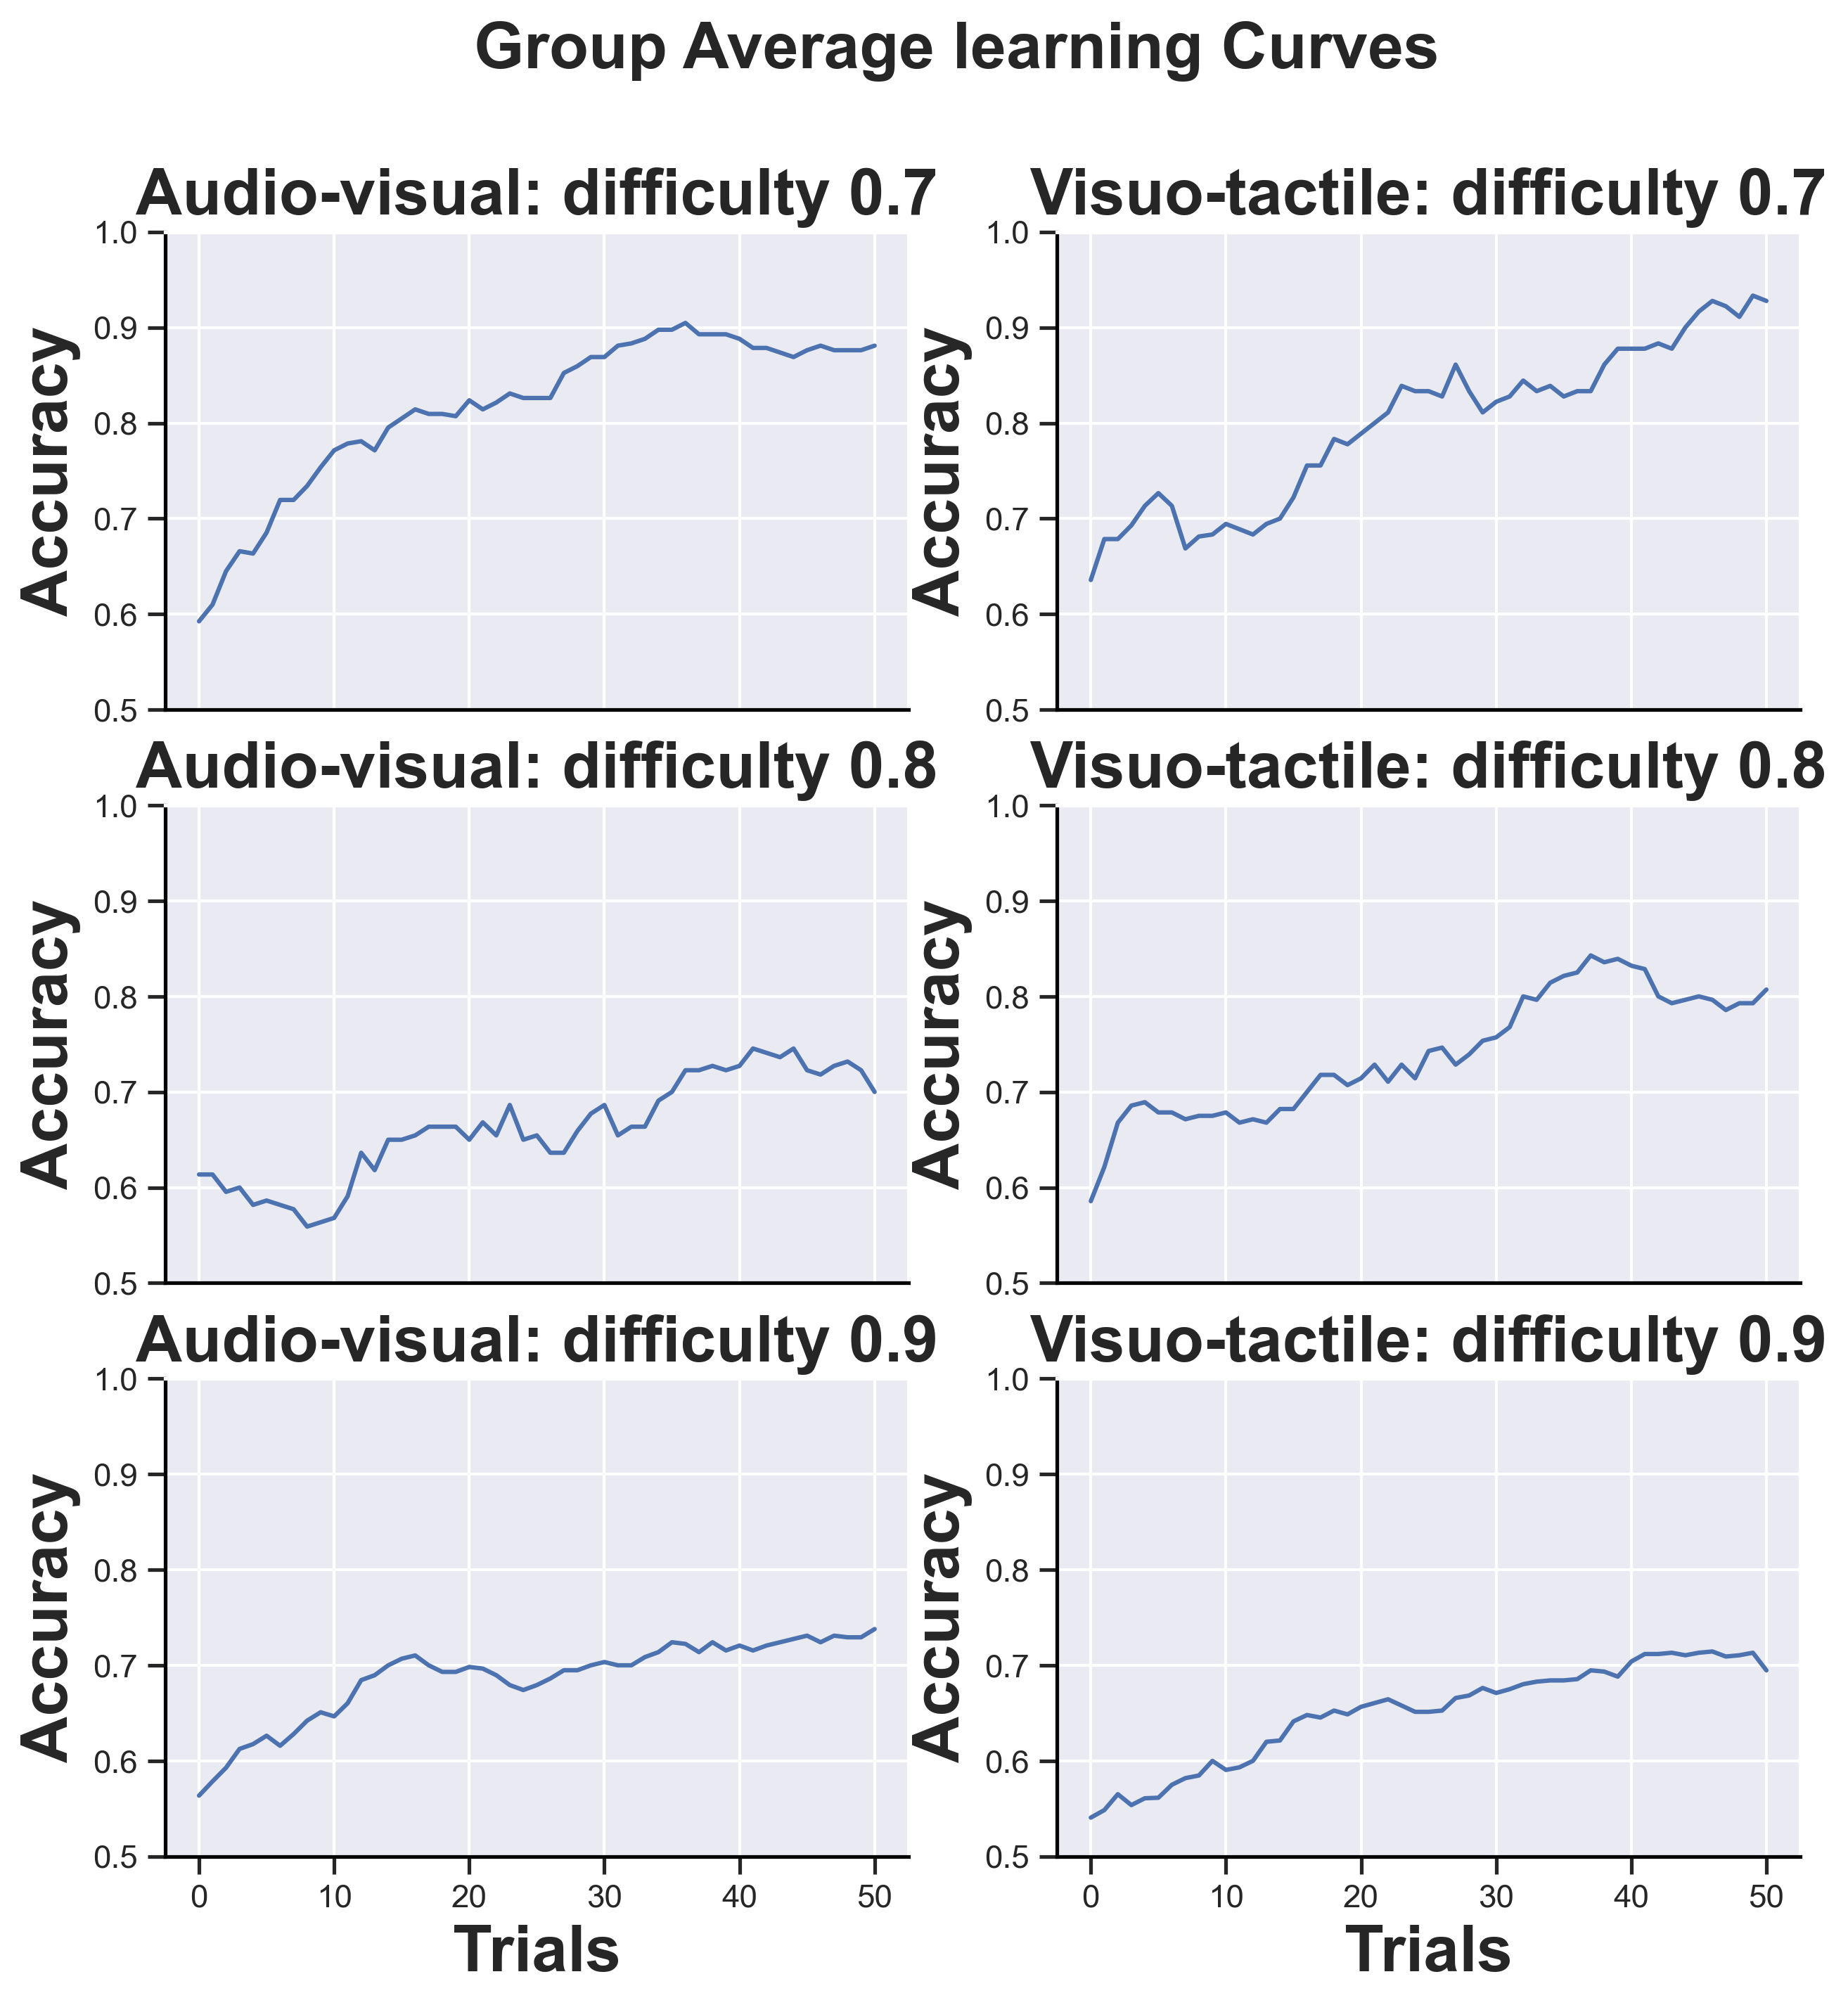

In [7]:
plotGroupAccuracy(10, method='valid')

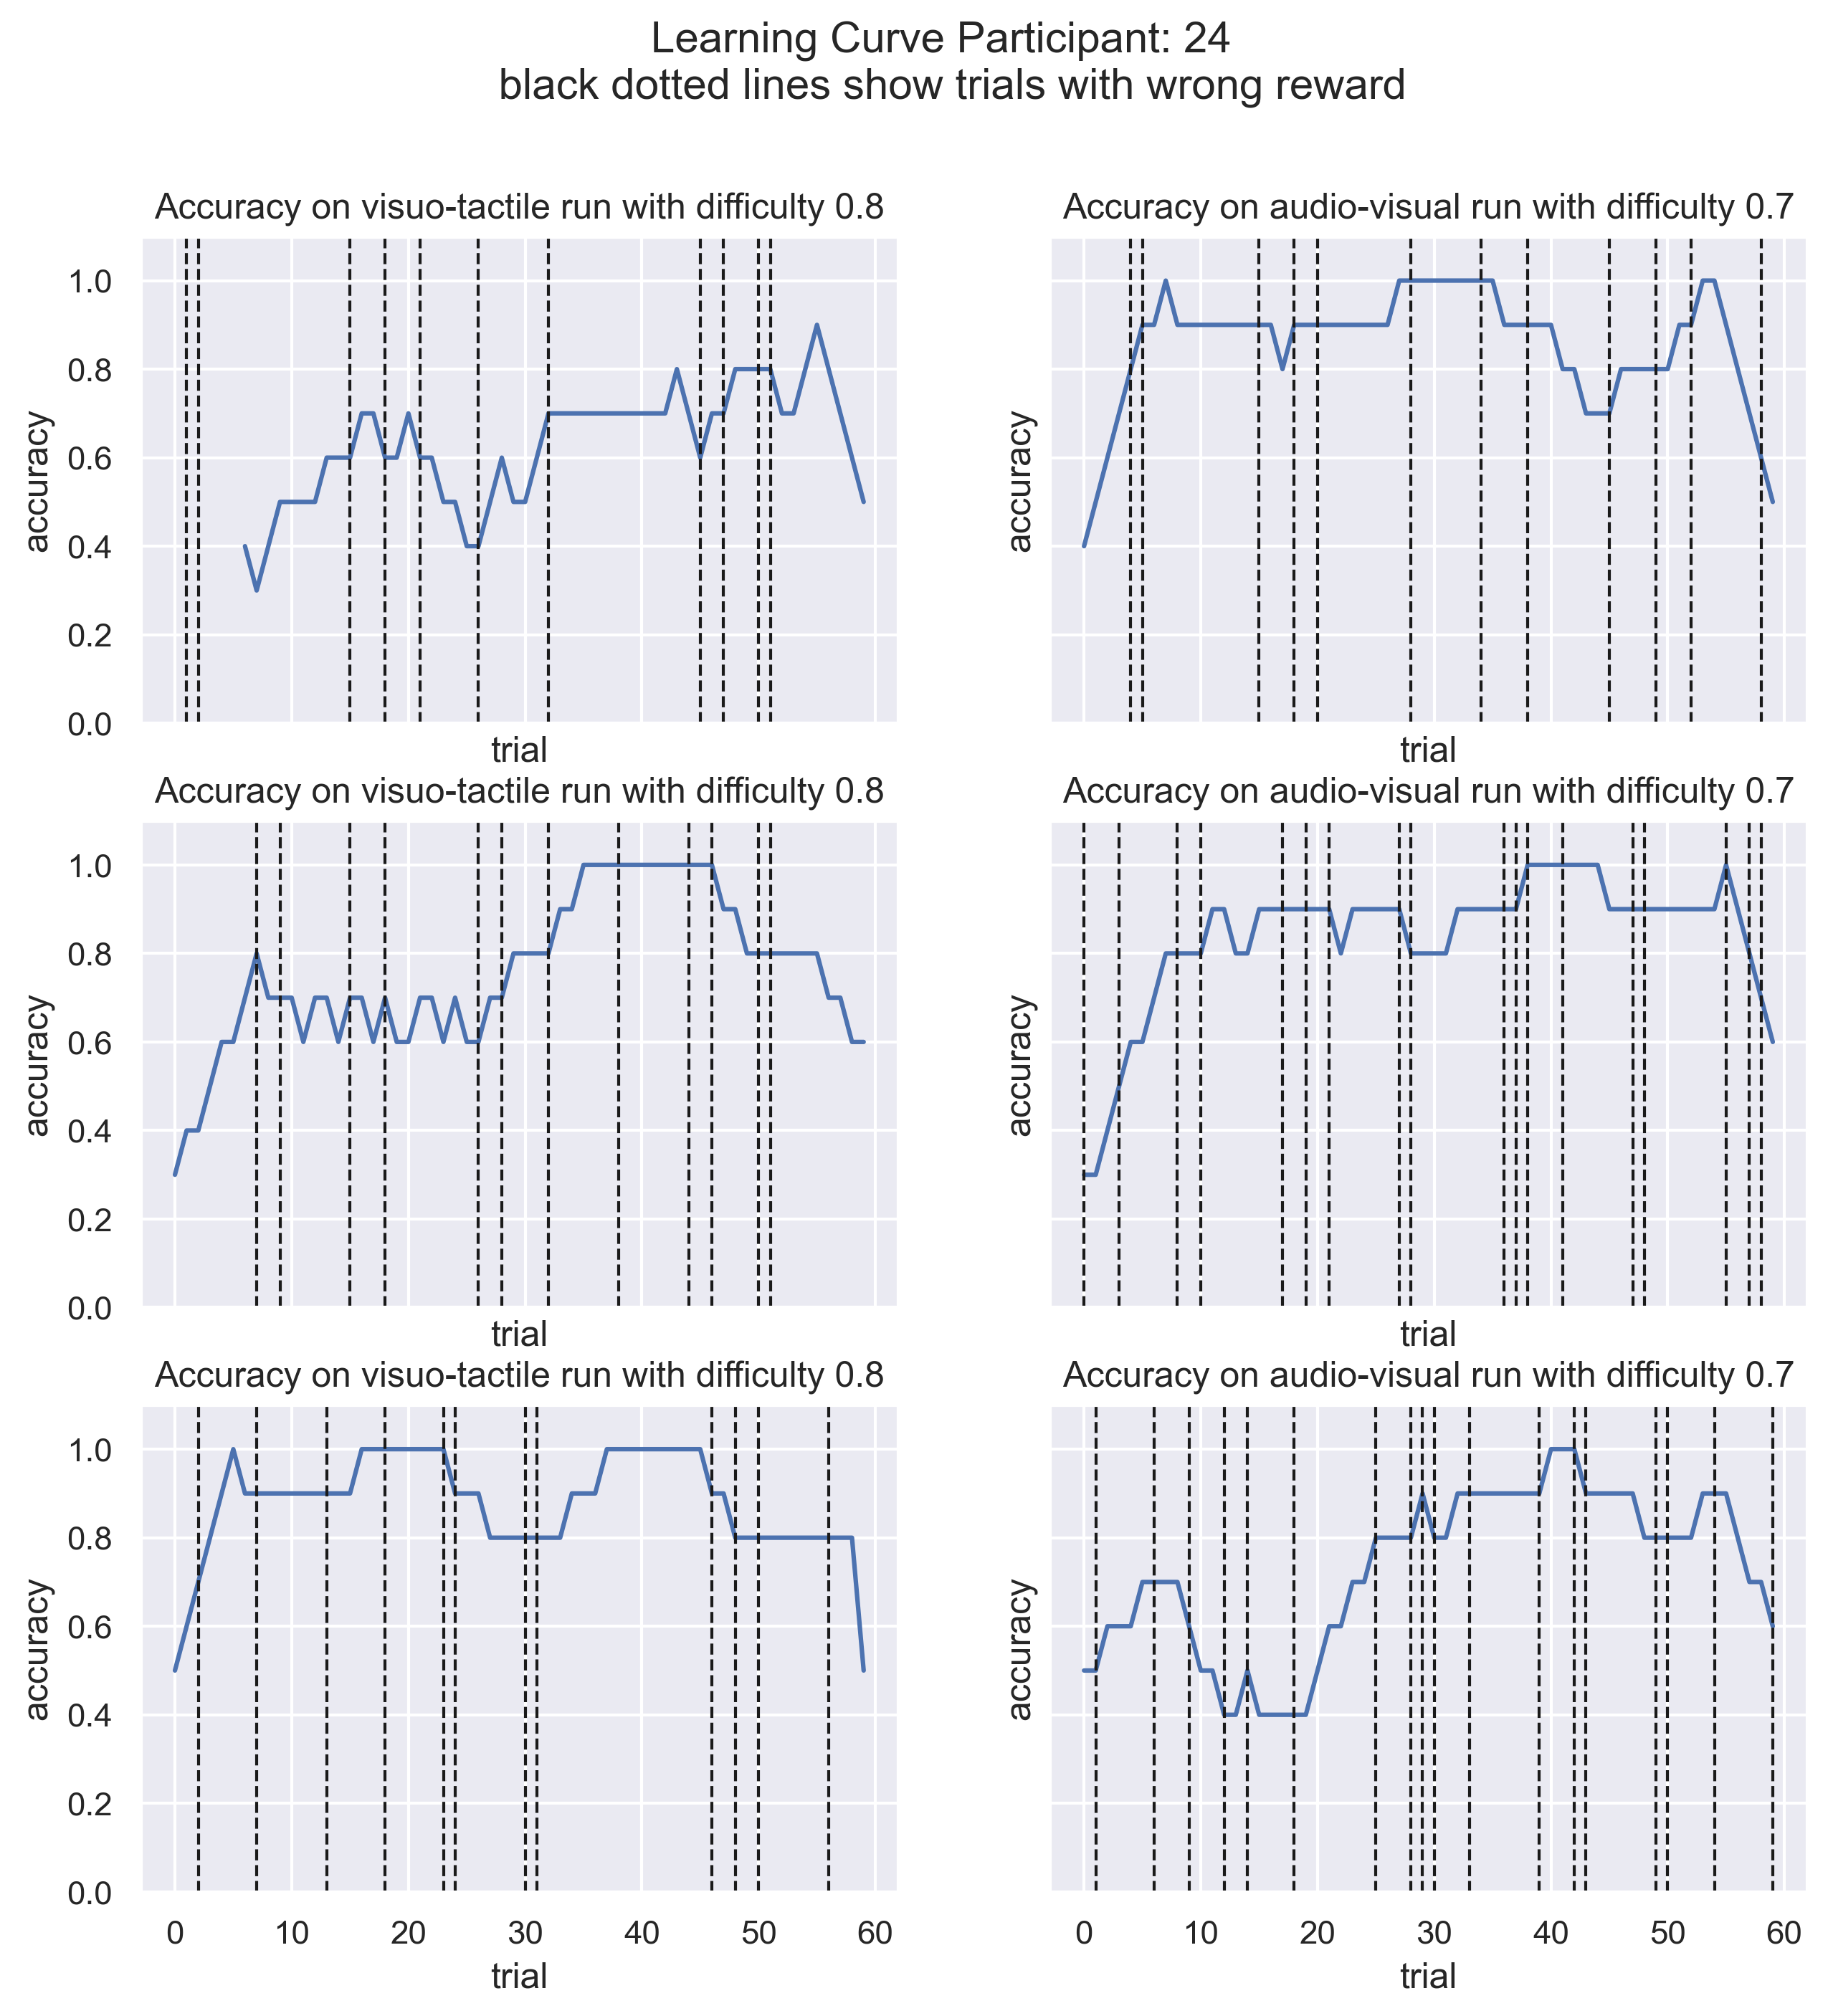

In [8]:
plotAccuracy('24', 10, method='same')

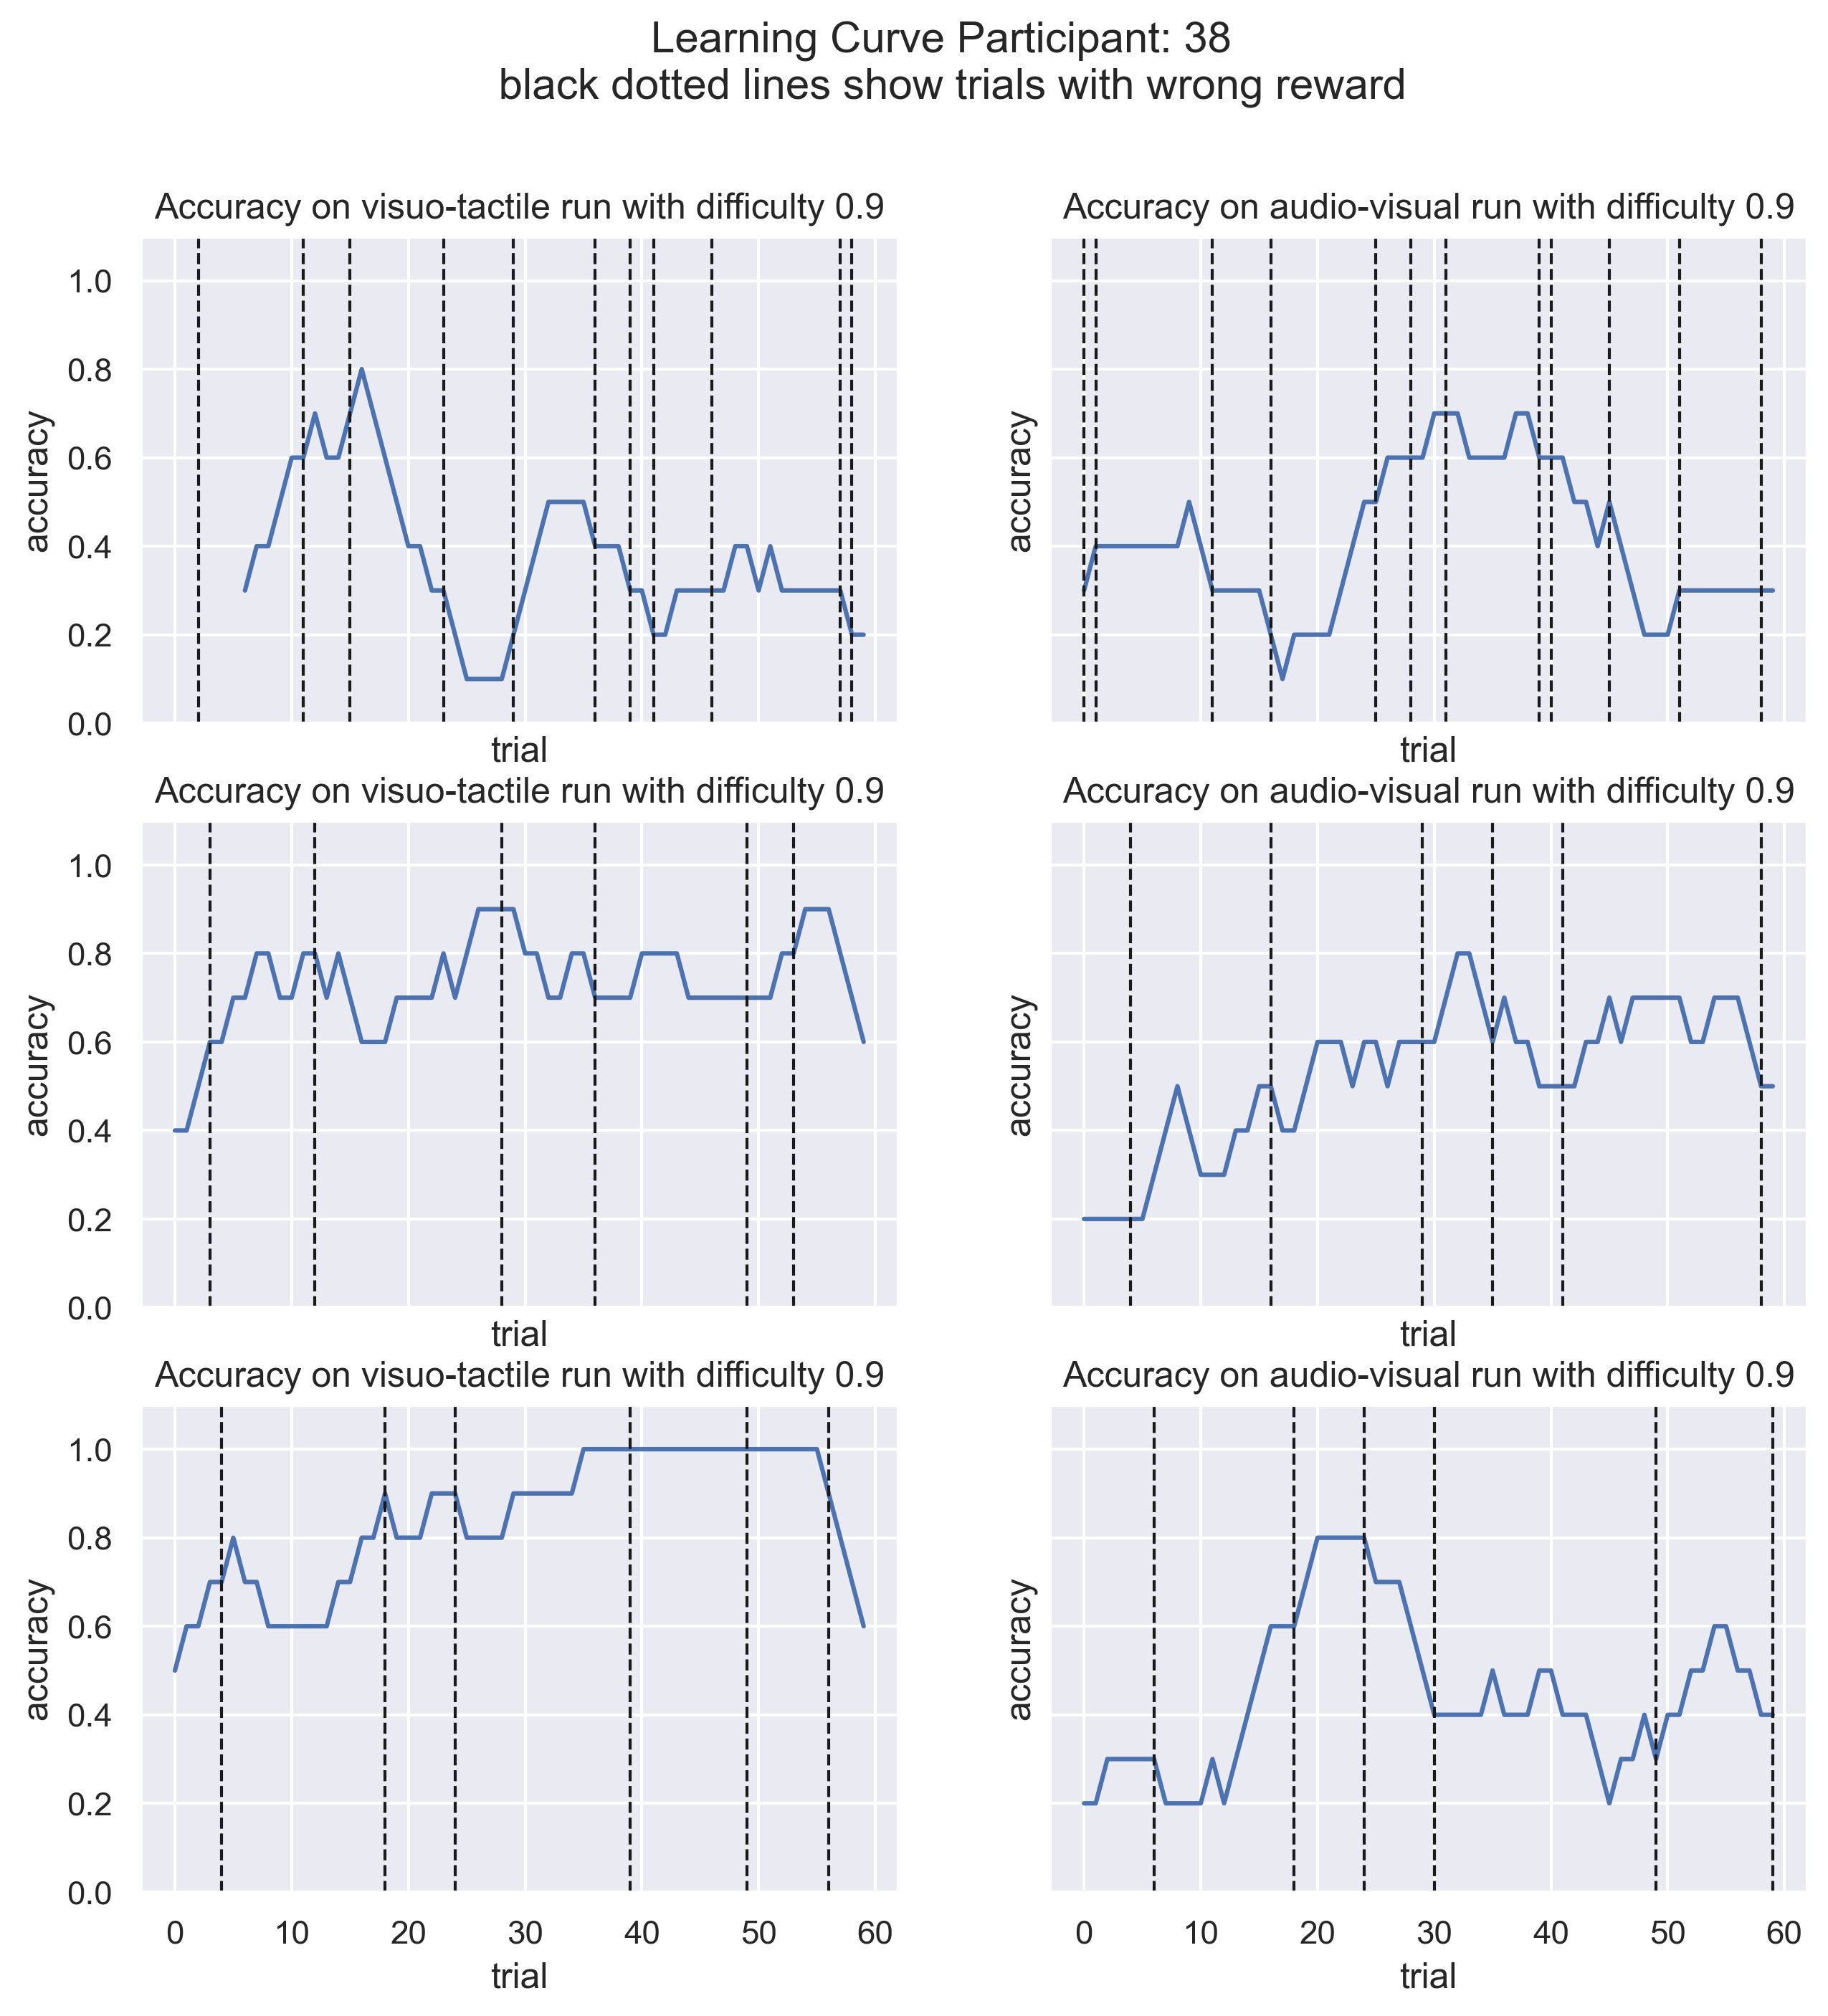

In [9]:
plotAccuracy('38', 10, method='same')

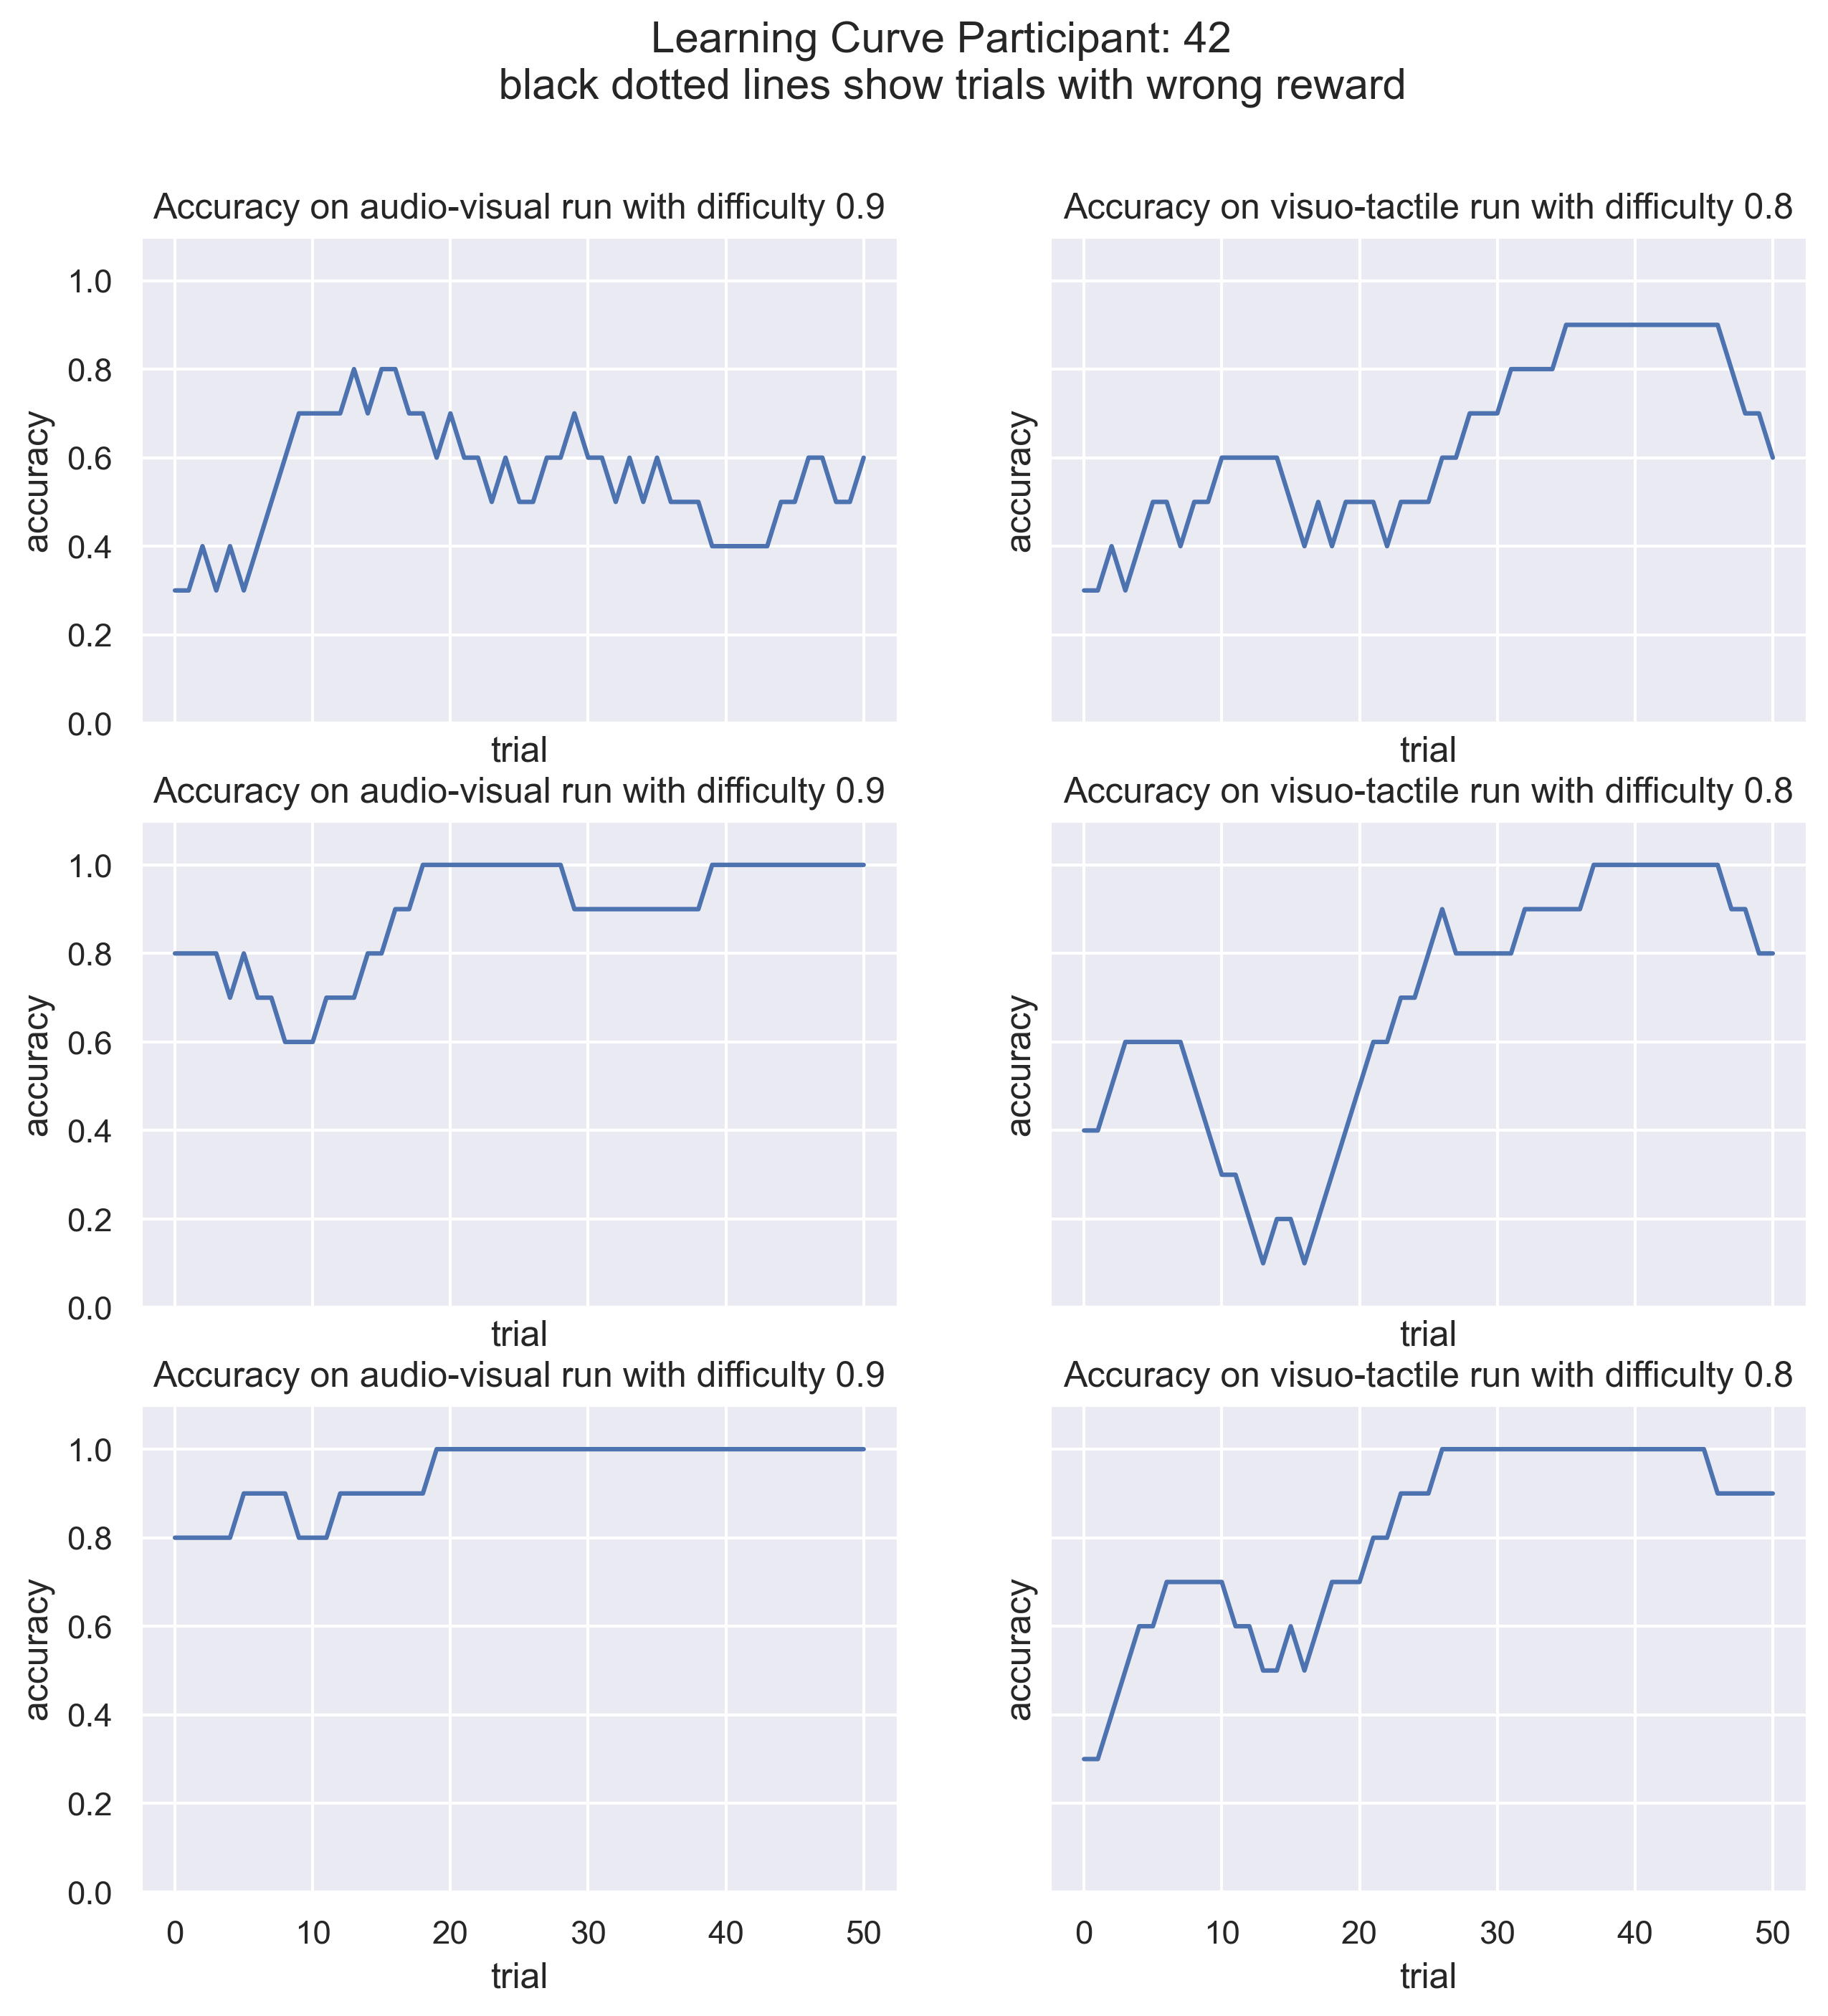

In [10]:
plotAccuracy('42', 10, method='valid')

In [9]:
def cutoff(mode="all"):
    #other mode "skip" to exclude calibration runs
    if platform.system() == 'Windows':
        wanted_dir = 'T:/projects/2022/bedi_casimiro_ruff_multisensorylearningfmri/data/sourcedata/behavior/modified_files'
    else:
        wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

    # Get all savedVals files
    files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv') and not name.startswith("._")]

    allAudioAcc = list()
    allTacAcc = list()
    for idx, file in enumerate(files):
        data = pd.read_csv(file)

        if max(data.runNumber) == 6:
            if mode == "all":
                if ~np.isnan(data.audio[59]):
                    audios = data[(data.runNumber == 1) | (data.runNumber == 3) | (data.runNumber == 5)].reset_index()
                    tactiles = data[(data.runNumber == 2) | (data.runNumber == 4) | (data.runNumber == 6)].reset_index()
                else:
                    tactiles = data[(data.runNumber == 1) | (data.runNumber == 3) | (data.runNumber == 5)].reset_index()
                    audios = data[(data.runNumber == 2) | (data.runNumber == 4) | (data.runNumber == 6)].reset_index()
            elif mode == "skip":
                if ~np.isnan(data.audio[59]):
                    audios = data[(data.runNumber == 3) | (data.runNumber == 5)].reset_index()
                    tactiles = data[(data.runNumber == 4) | (data.runNumber == 6)].reset_index()
                else:
                    tactiles = data[(data.runNumber == 3) | (data.runNumber == 5)].reset_index()
                    audios = data[(data.runNumber == 4) | (data.runNumber == 6)].reset_index()
            allAudioAcc.extend(np.array(audios.totalAccuracy[59::60]))
            allTacAcc.extend(np.array(tactiles.totalAccuracy[59::60]))
        else:
            continue
    

    below5Au = sum(i < 0.5 for i in allAudioAcc)
    below5Tac = sum(i < 0.5 for i in allTacAcc)
    below5 = below5Au + below5Tac

    between5and6Au = sum(0.6 > i > 0.5 for i in allAudioAcc)
    between5and55Au = sum(0.55 > i > 0.5 for i in allAudioAcc)
    between5and6Tac = sum(0.6 > i > 0.5 for i in allTacAcc)
    between5and55Tac = sum(0.55 > i > 0.5 for i in allTacAcc)
    between5and6 = between5and6Au + between5and6Tac
    between5and55 = between5and55Au + between5and55Tac
    
    print(below5Au, between5and6Au, between5and55Au)
    print(below5Tac, between5and6Tac, between5and55Tac)
    print(below5, between5and6, between5and55)

    

In [10]:
cutoff()

33 31 11
40 35 24
73 66 35


In [11]:
cutoff(mode="skip")

18 14 4
14 25 16
32 39 20


In [49]:
def learning(mode, cutoff=0.6):

    if platform.system() == 'Windows':
        wanted_dir = 'T:/projects/2022/bedi_casimiro_ruff_multisensorylearningfmri/data/sourcedata/behavior/modified_files'
    else:
        wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

    # Get all savedVals files
    files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv') and not name.startswith("._")]

    runsLearned = list()
    if mode == "all":
        fig, ax = plt.subplots()
        for file in files:
            data = pd.read_csv(file)
            if max(data.runNumber) == 6:
                accuracies = np.array(data.totalAccuracy[59::60])
                runsLearned.append((accuracies[accuracies >= cutoff]).size)
            else:
                continue
        
        runsLearned_arr = np.unique(np.array(runsLearned), return_counts=True)
        ax.bar(runsLearned_arr[0],runsLearned_arr[1], color='#1D2F6F')
        fig.suptitle("Amount of runs with average accuracy >= {}".format(cutoff))
        start, end = ax.get_ylim()
        # ax.yaxis.set_ticks(np.arange(start, end, 2))
        ax.set_xlabel("Runs")
        ax.set_ylabel("Participants")
            

    elif mode == "skip":
        fig, ax = plt.subplots()
        for file in files:
            data = pd.read_csv(file)
            if max(data.runNumber) == 6:
                accuracies = np.array(data.totalAccuracy[179::60])
                runsLearned.append((accuracies[accuracies >= cutoff]).size)
            else:
                continue
        
        runsLearned_arr = np.unique(np.array(runsLearned), return_counts=True)
        ax.bar(runsLearned_arr[0],runsLearned_arr[1], color='#1D2F6F')
        fig.suptitle("Amount of runs with average accuracy >= {}\n Excl. calibration runs".format(cutoff))
        start, end = ax.get_ylim()
        # ax.yaxis.set_ticks(np.arange(start, end, 2))
        ax.set_xlabel("Runs")
        ax.set_ylabel("Participants")
    
    elif mode == "split":
        fig, ax = plt.subplots(ncols=2, figsize=(11,5))
        runsLearnedAudio = defaultdict(list)
        runsLearnedTactile = defaultdict(list)
        for file in files:
            data = pd.read_csv(file)
            if max(data.runNumber) == 6:
                if ~np.isnan(data.audio[59]):
                    audios = data[(data.runNumber == 3) | (data.runNumber == 5)].reset_index()
                    tactiles = data[(data.runNumber == 4) | (data.runNumber == 6)].reset_index()
                else:
                    tactiles = data[(data.runNumber == 3) | (data.runNumber == 5)].reset_index()
                    audios = data[(data.runNumber == 4) | (data.runNumber == 6)].reset_index()
                
                audioDiff = sum(audios.feedbackAccuracy[:10])/10
                tactileDiff = sum(tactiles.feedbackAccuracy[:10])/10
            
                accuraciesAudio = np.array(audios.totalAccuracy[59::60])
                accuraciesTactile = np.array(tactiles.totalAccuracy[59::60])
                runsLearnedAudio[str(audioDiff)].append((accuraciesAudio[accuraciesAudio >= cutoff]).size)
                runsLearnedTactile[str(tactileDiff)].append((accuraciesTactile[accuraciesTactile >= cutoff]).size)
            else:
                continue

        
        runsLearnedAu_9arr = np.unique(np.array(runsLearnedAudio.get("0.9")), return_counts=True)
        runsLearnedAu_8arr = np.unique(np.array(runsLearnedAudio.get("0.8")), return_counts=True)
        runsLearnedAu_7arr = np.unique(np.array(runsLearnedAudio.get("0.7")), return_counts=True)

        runsLearnedTac_9arr = np.unique(np.array(runsLearnedTactile.get("0.9")), return_counts=True)
        runsLearnedTac_8arr = np.unique(np.array(runsLearnedTactile.get("0.8")), return_counts=True)
        runsLearnedTac_7arr = np.unique(np.array(runsLearnedTactile.get("0.7")), return_counts=True)

        ax[0].bar(runsLearnedAu_9arr[0].astype(str), runsLearnedAu_9arr[1], label="0.9", color='#1D2F6F')
        ax[0].bar(runsLearnedAu_8arr[0].astype(str), runsLearnedAu_8arr[1], label="0.8", color='#8390FA')
        ax[0].bar(runsLearnedAu_7arr[0].astype(str), runsLearnedAu_7arr[1], label="0.7", color='#FAC748')

        ax[1].bar(runsLearnedTac_9arr[0].astype(str), runsLearnedTac_9arr[1], color='#1D2F6F')
        ax[1].bar(runsLearnedTac_8arr[0].astype(str), runsLearnedTac_8arr[1], color='#8390FA')
        ax[1].bar(runsLearnedTac_7arr[0].astype(str), runsLearnedTac_7arr[1], color='#FAC748')

        ax[0].legend()
        fig.suptitle("Amount of runs with average accuracy >= {} by difficulty level\nSeparated by modality".format(cutoff), y=1.05)
        start1, end1 = ax[0].get_ylim()
        start2, end2 = ax[1].get_ylim()
        ax[0].yaxis.set_ticks(np.arange(start1, end1, 2))
        ax[1].yaxis.set_ticks(np.arange(start2, end2, 2))
        ax[0].set_xlabel("Runs")
        ax[0].set_title("Audio")
        ax[0].set_ylabel("Participants")
        ax[1].set_xlabel("Runs")
        ax[1].set_title("Tactile")
        ax[1].set_ylabel("Participants")

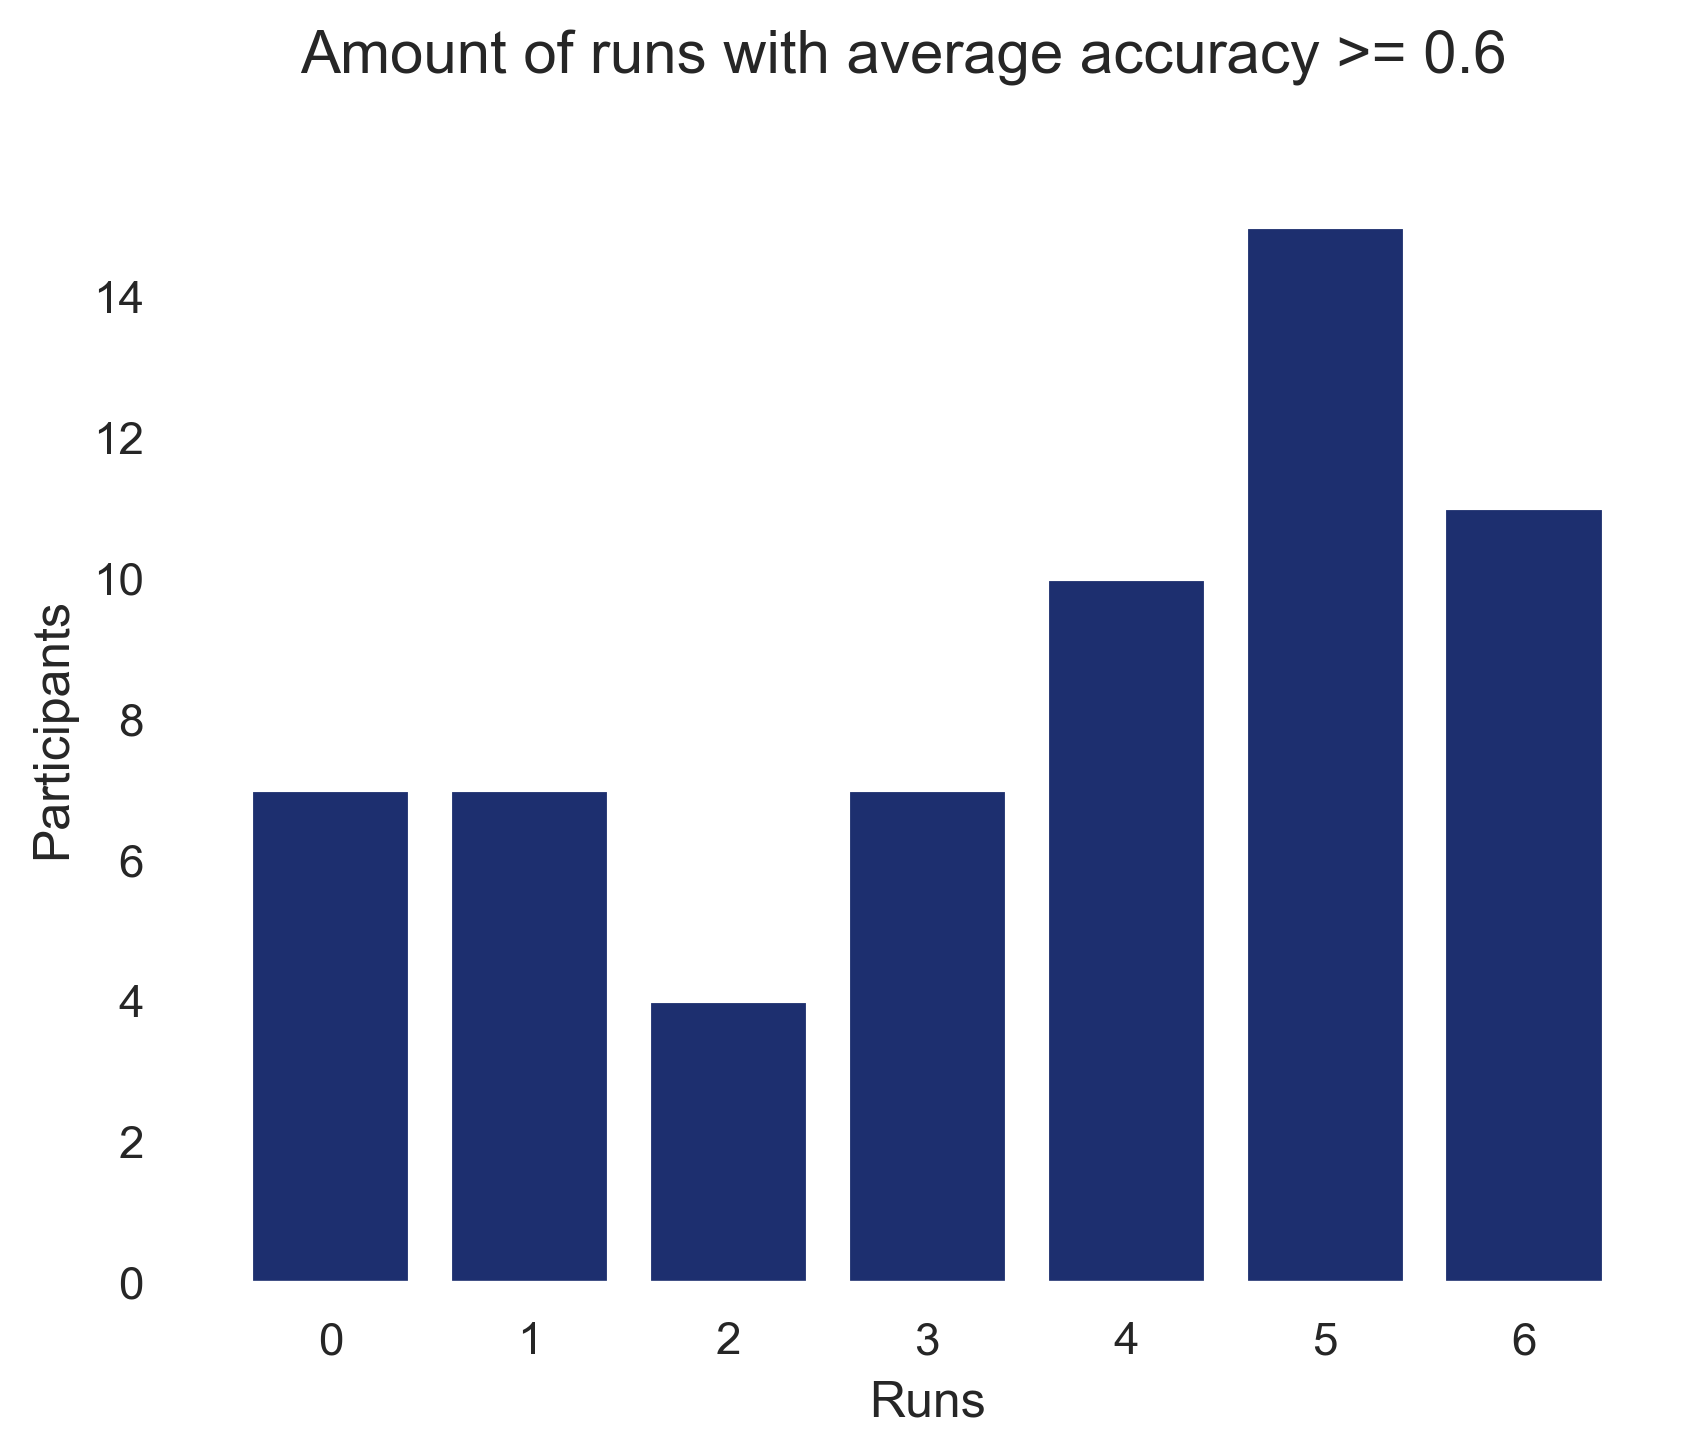

In [50]:
learning("all")

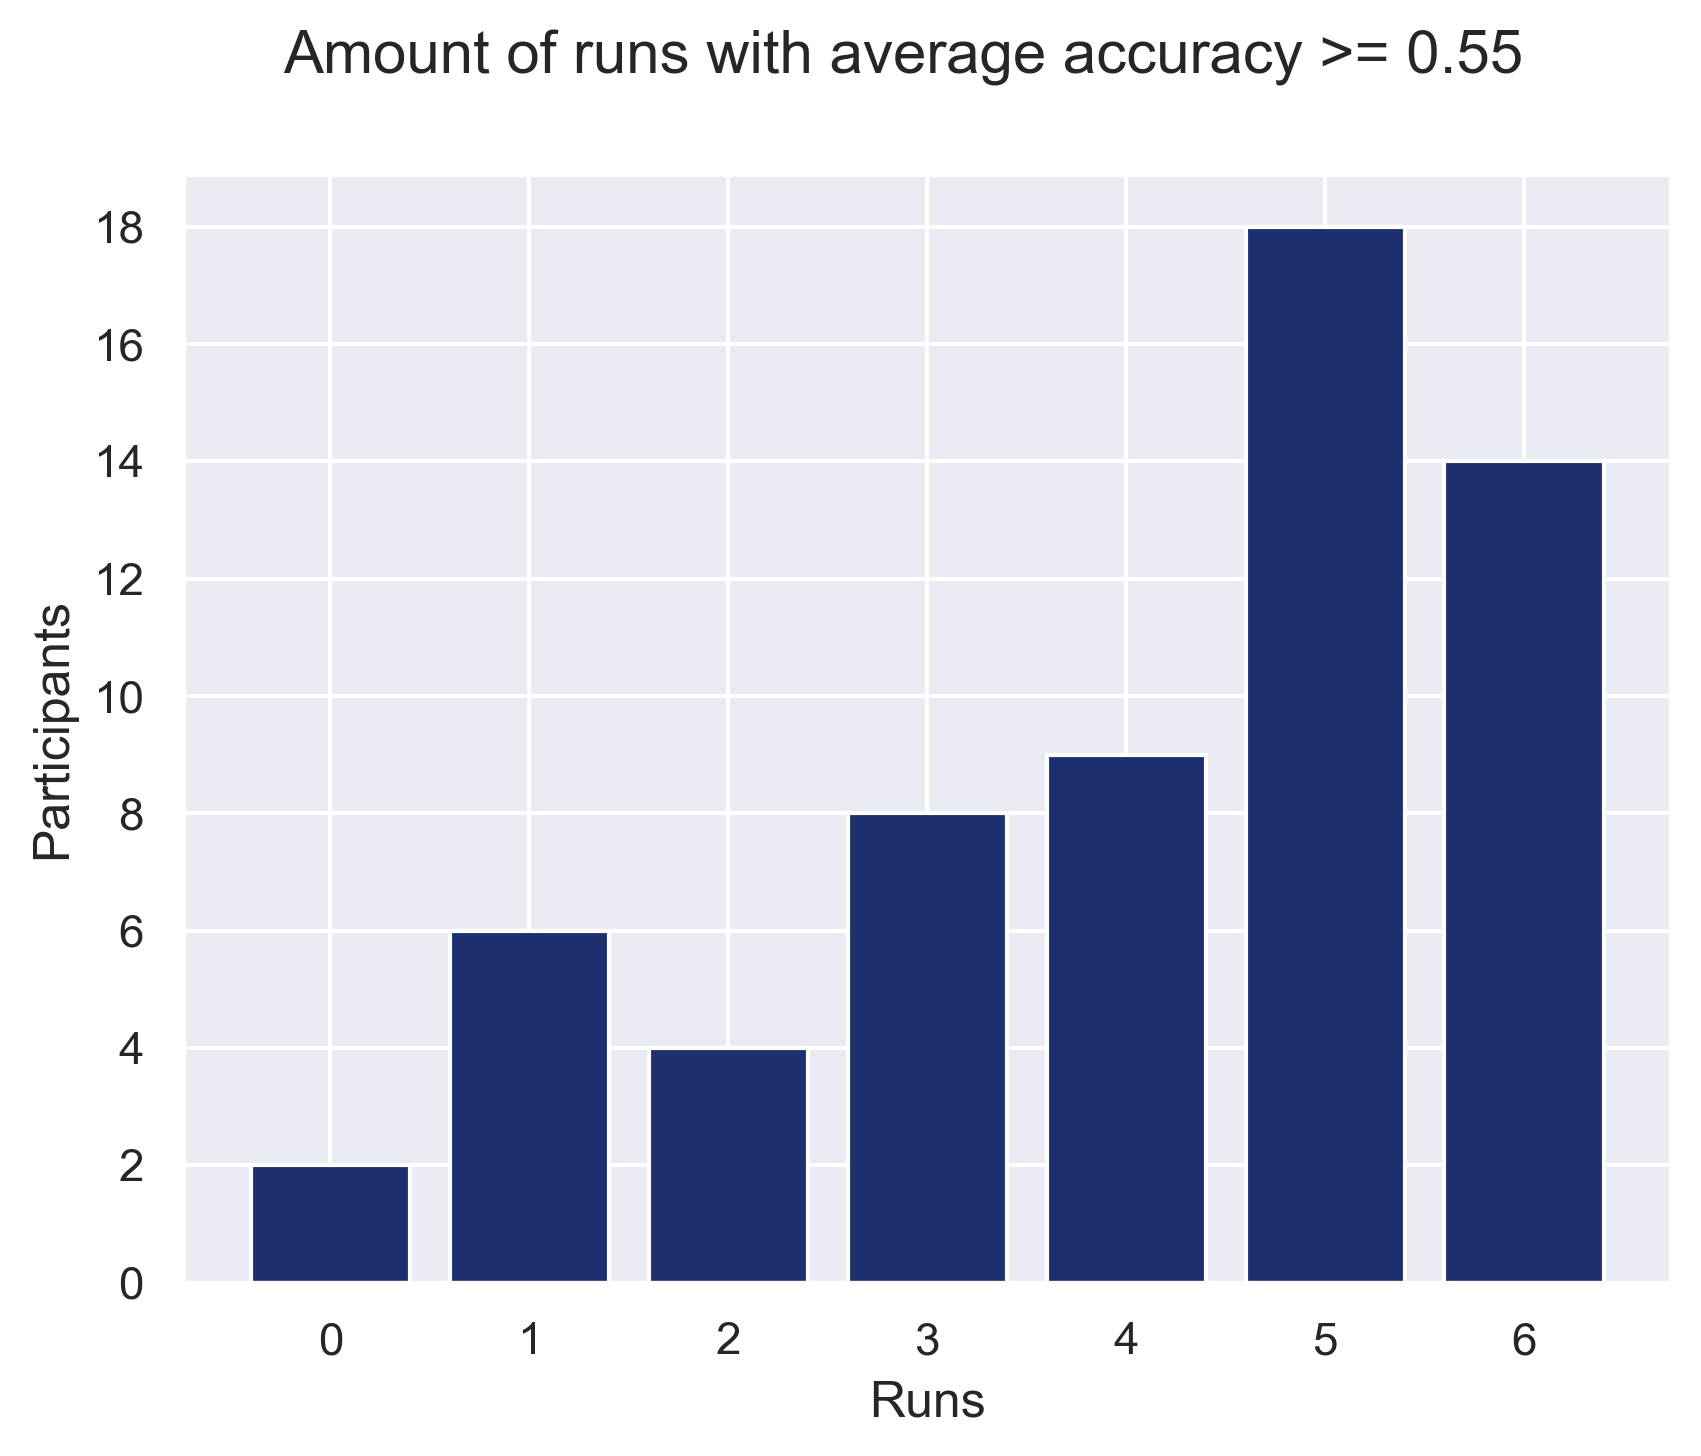

In [14]:
learning("all", cutoff=0.55)

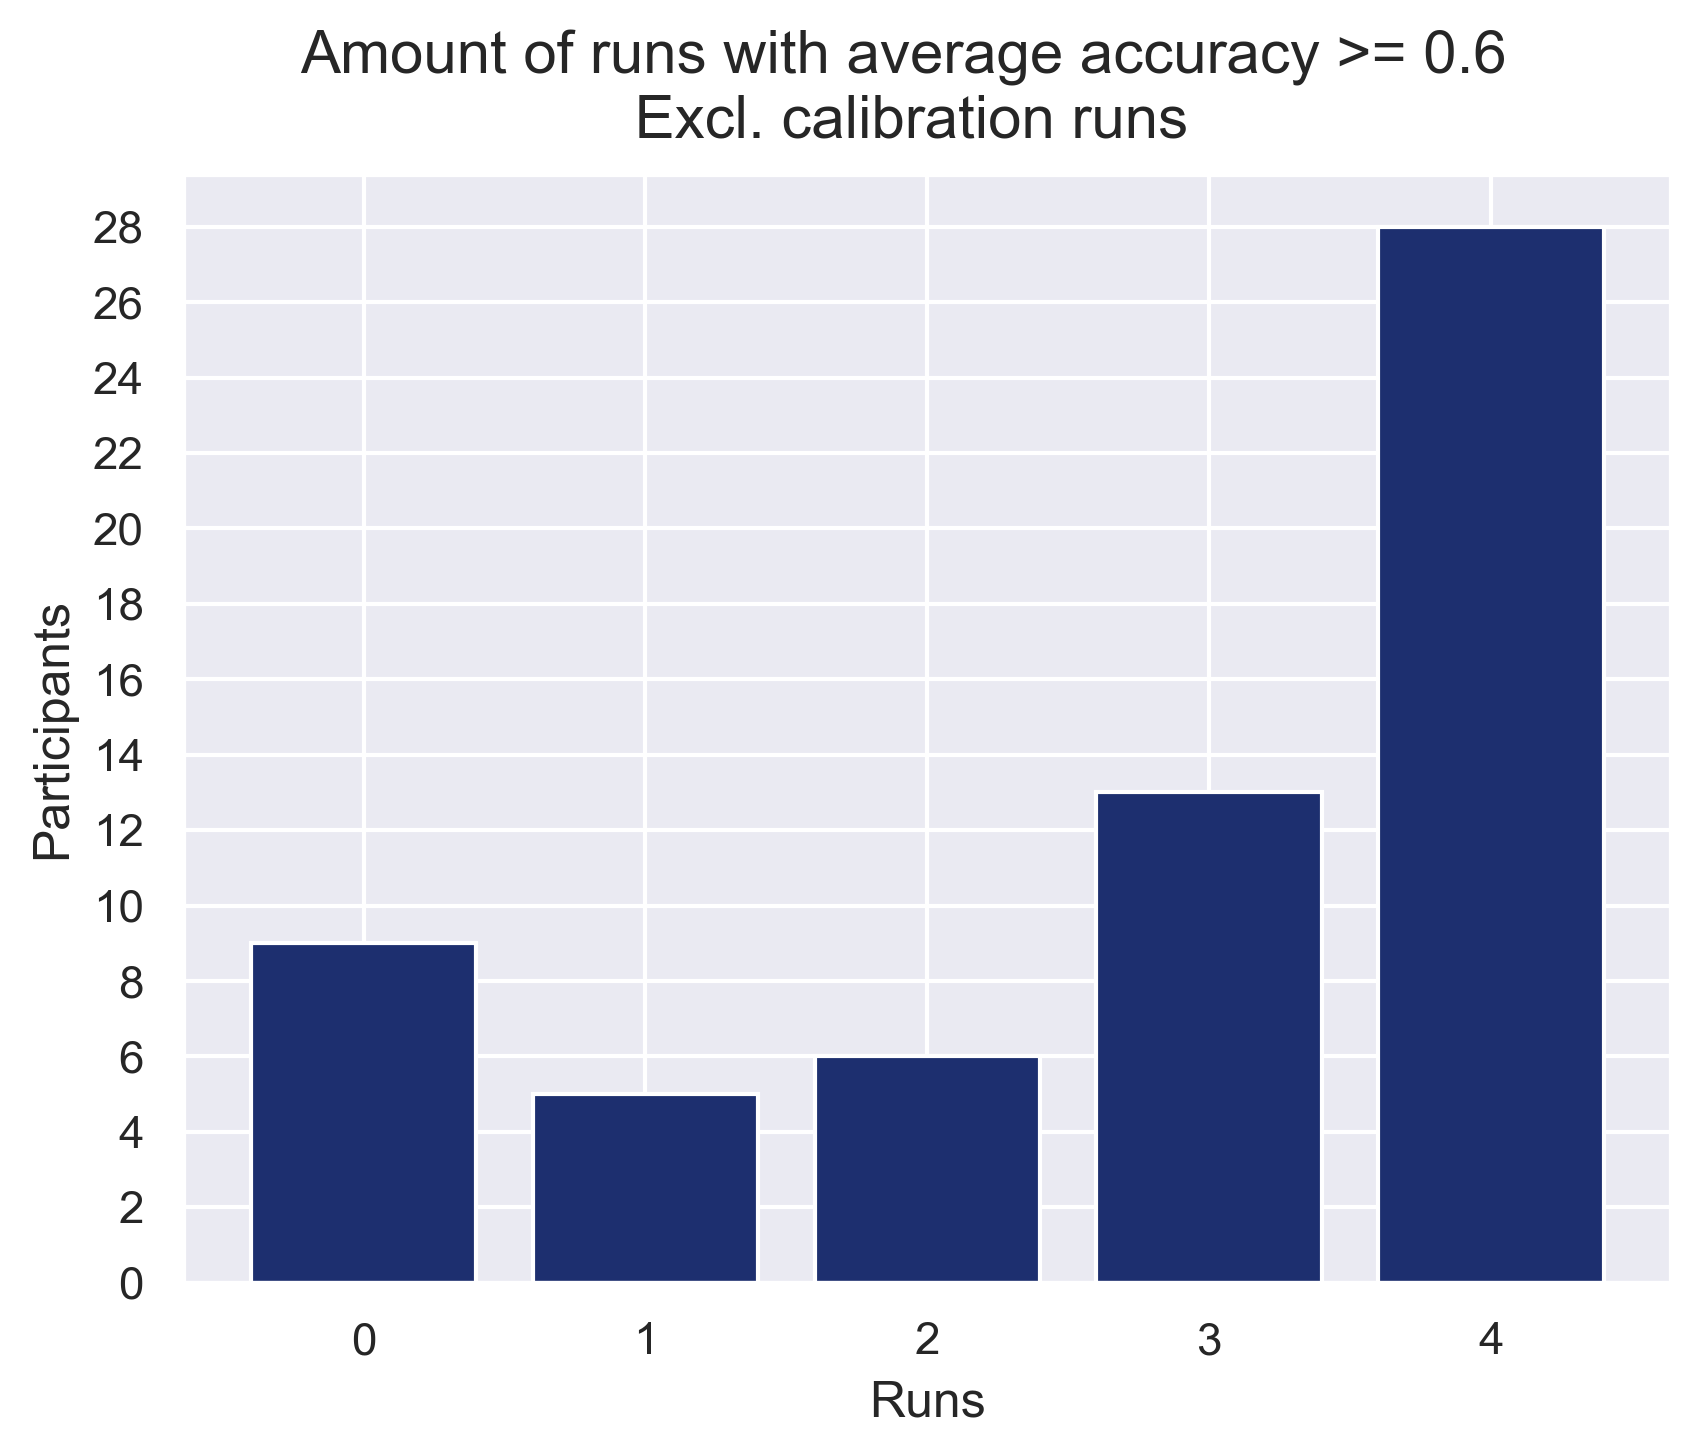

In [15]:
learning(mode="skip")

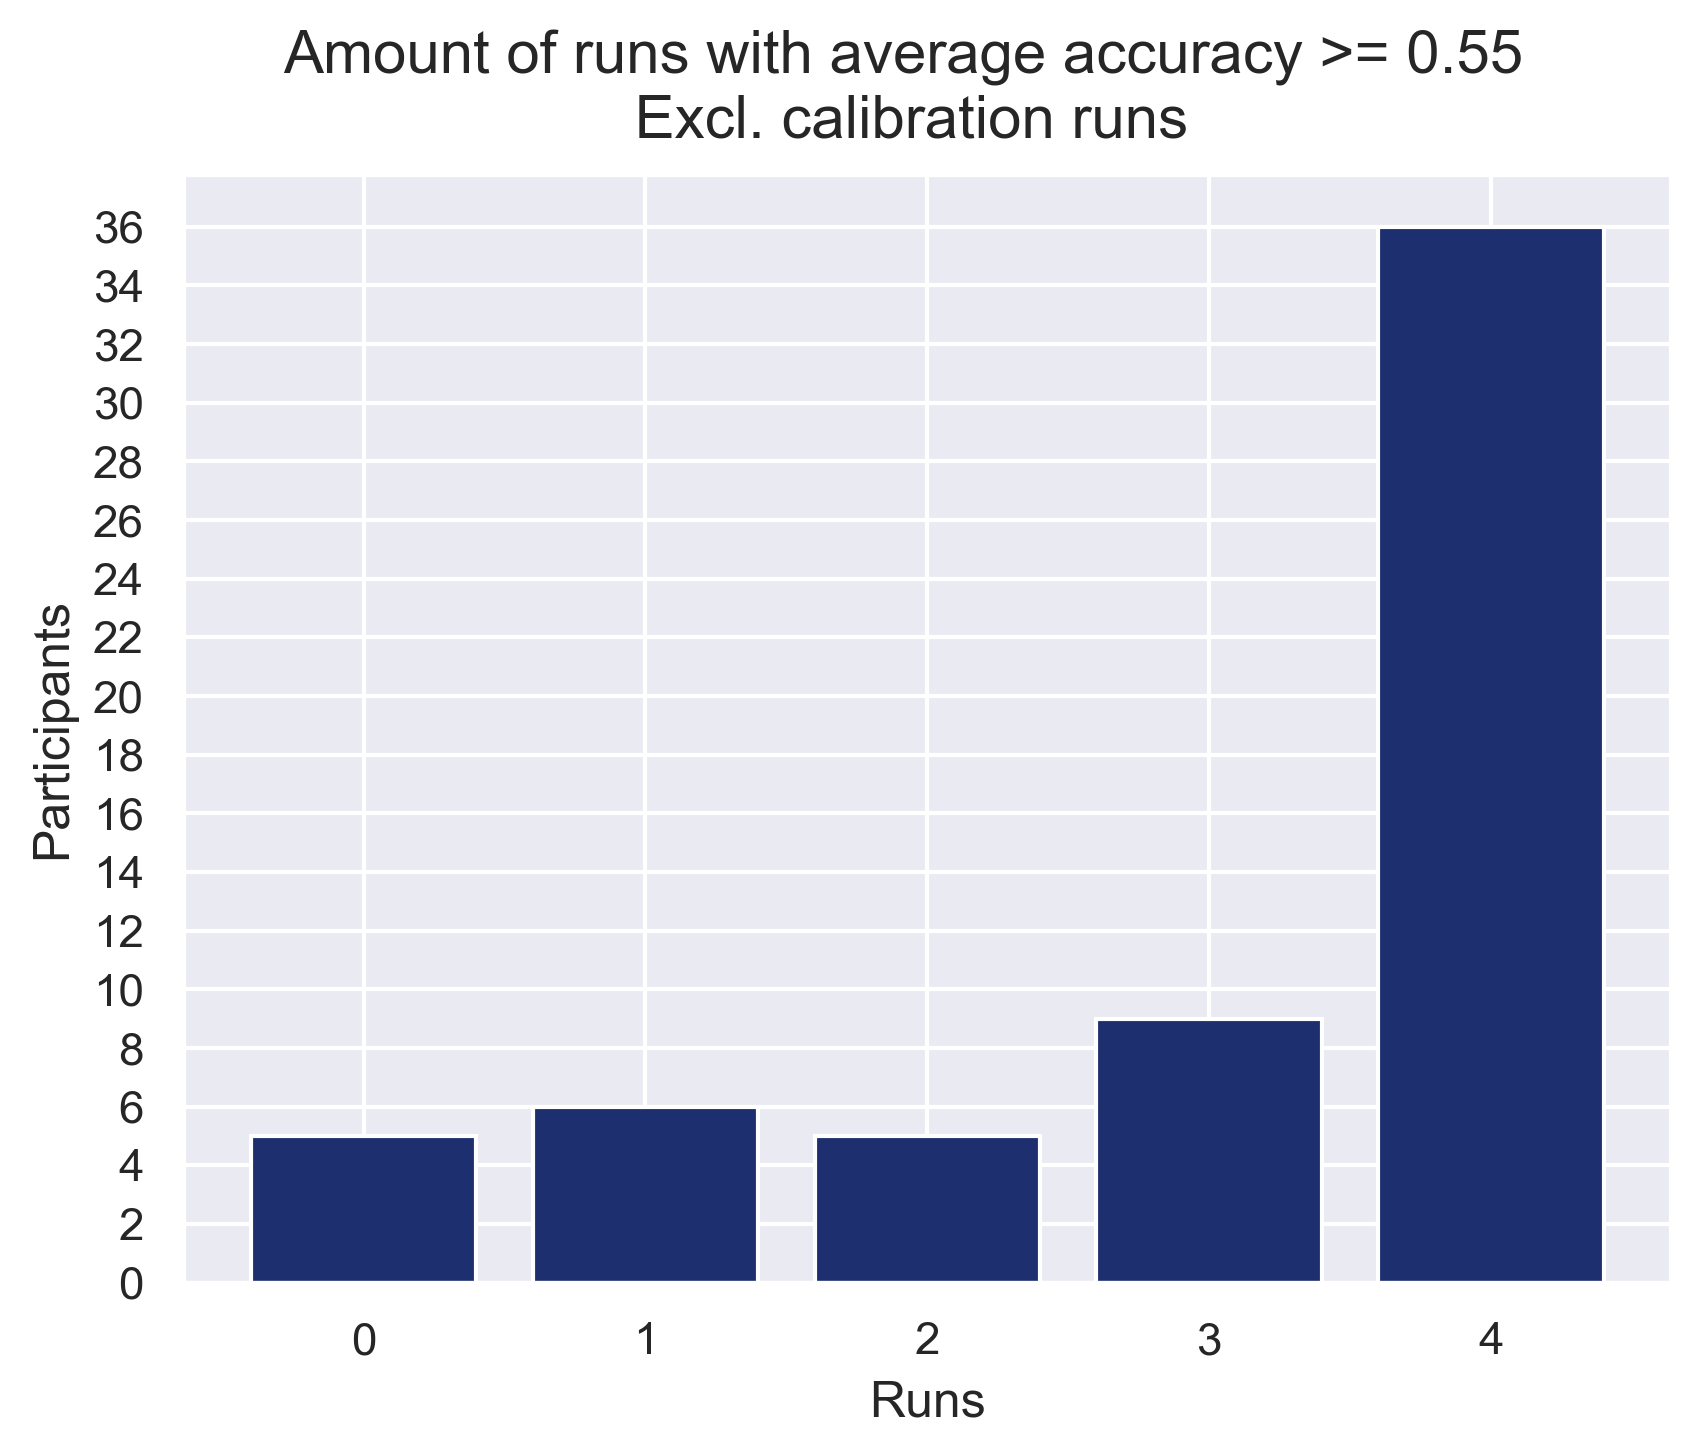

In [16]:
learning(mode="skip", cutoff=.55)

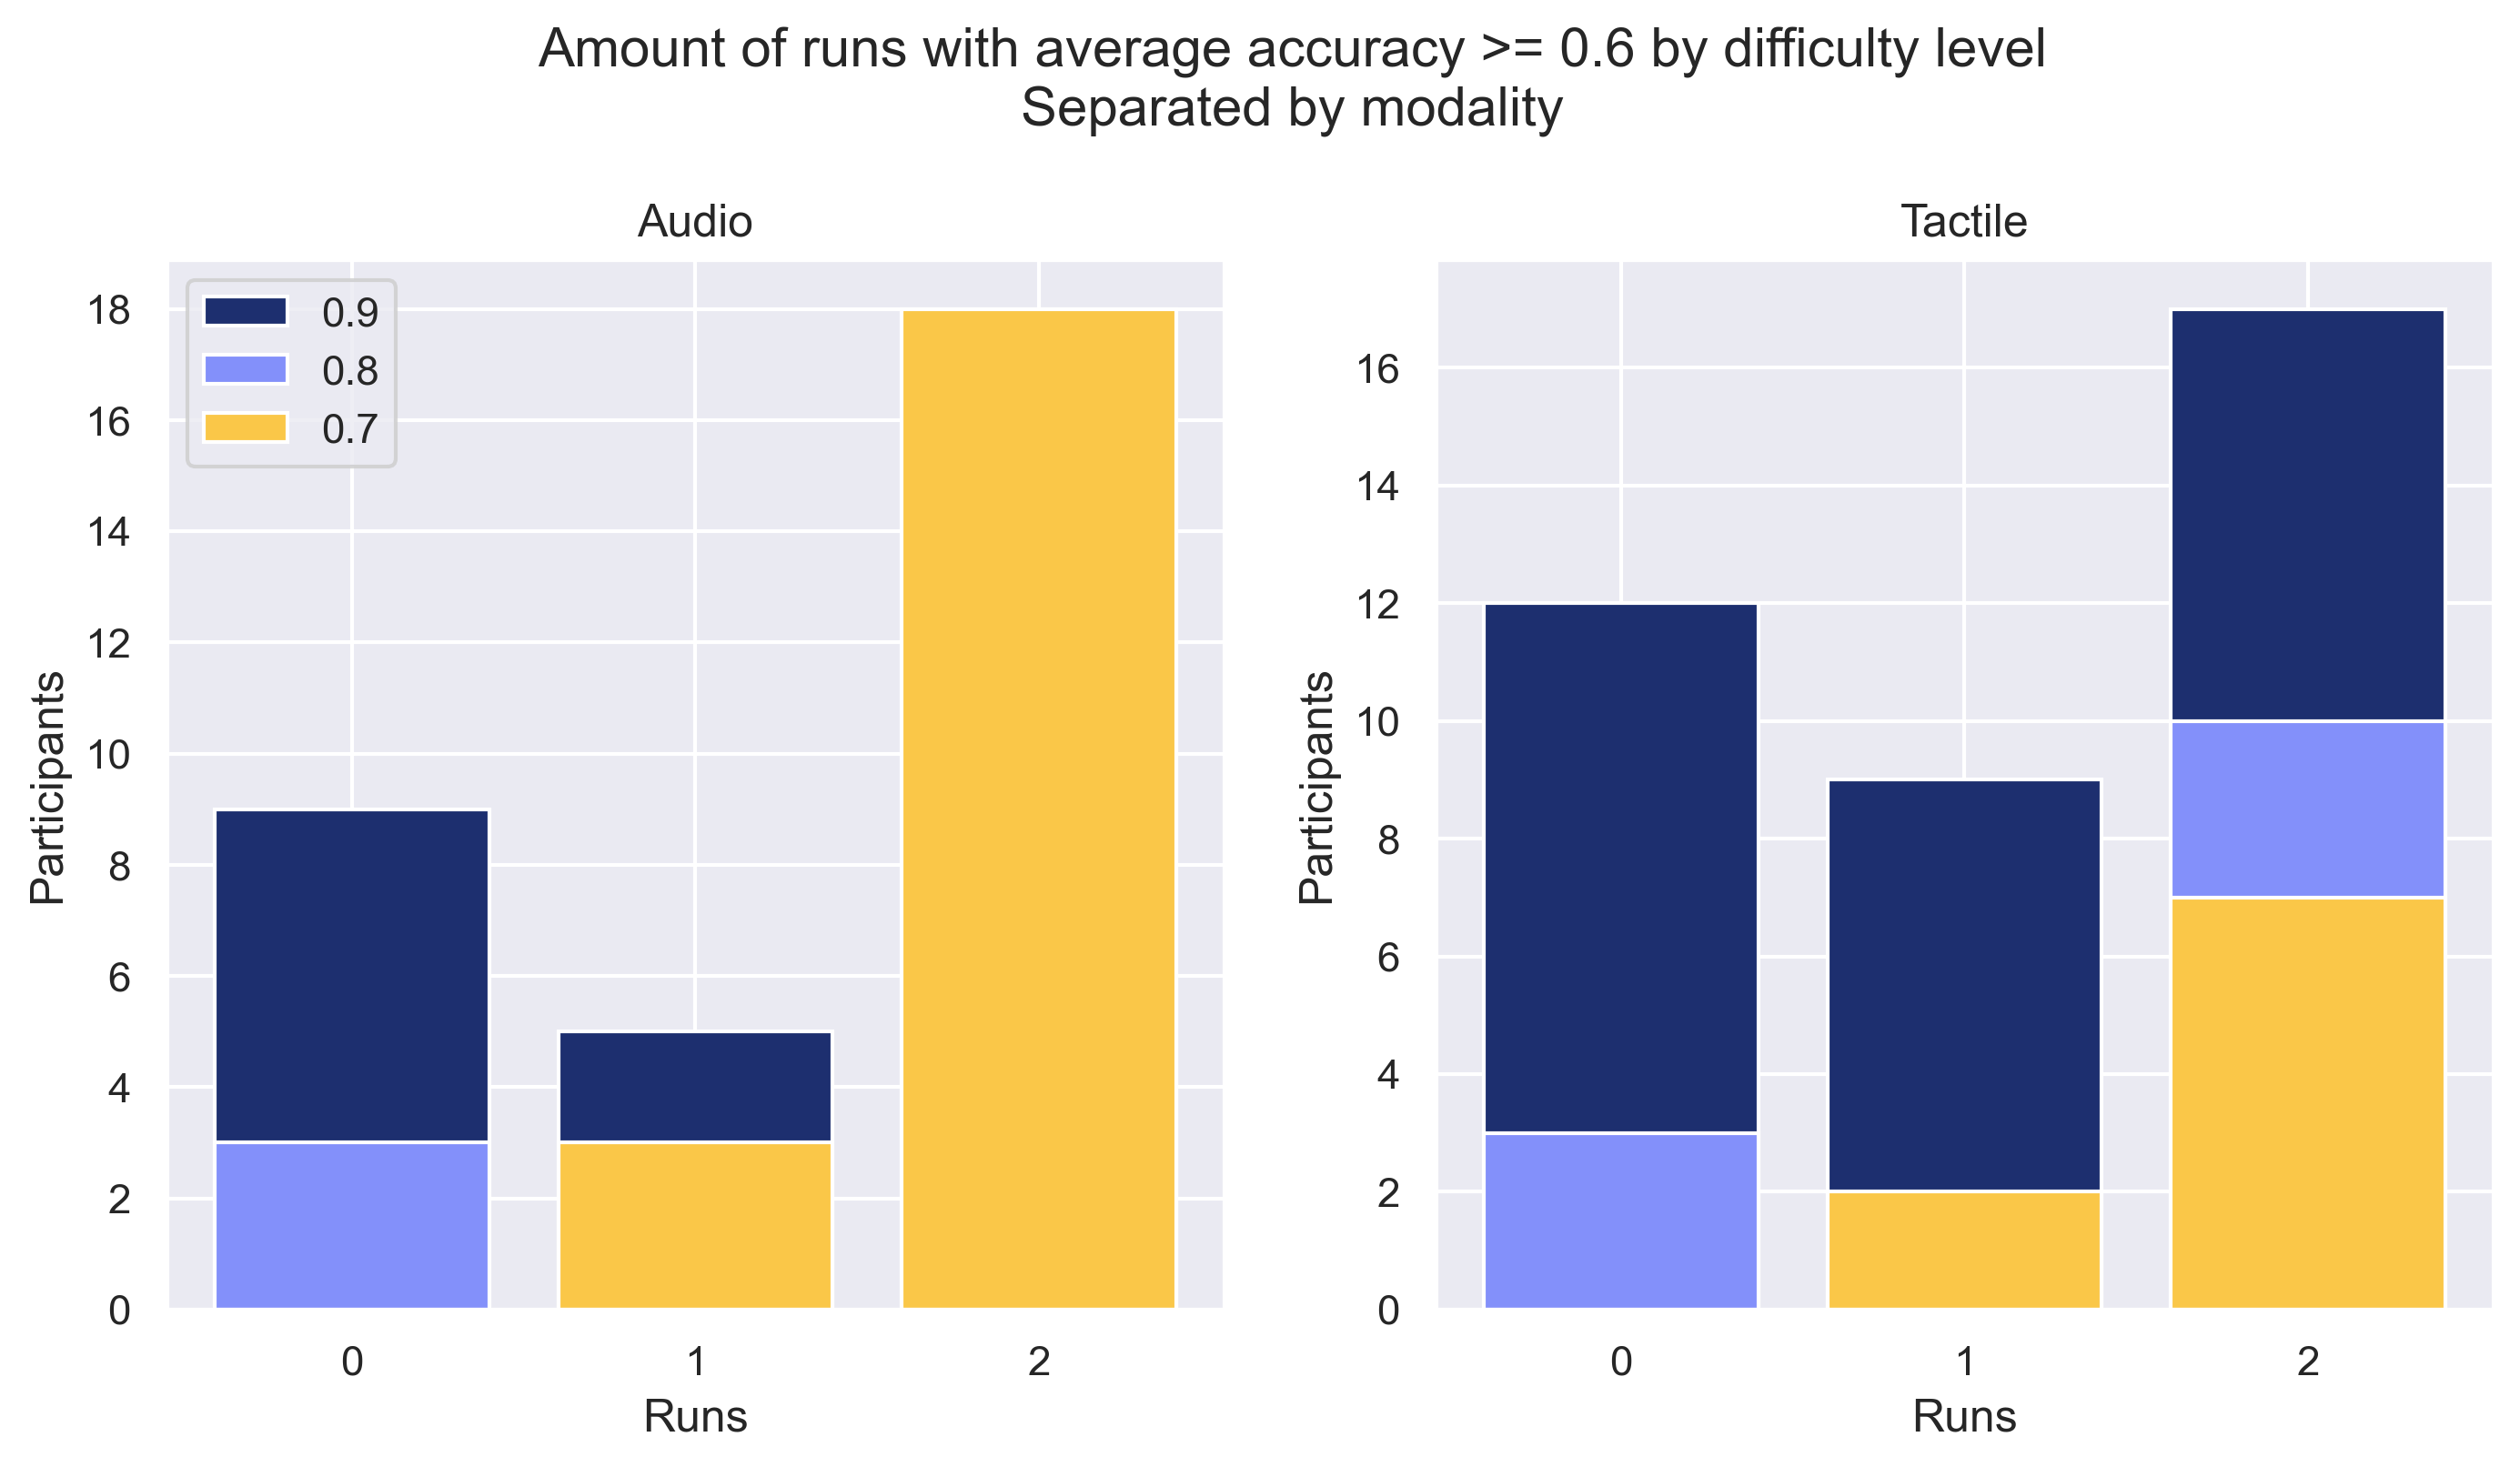

In [17]:
learning(mode="split")

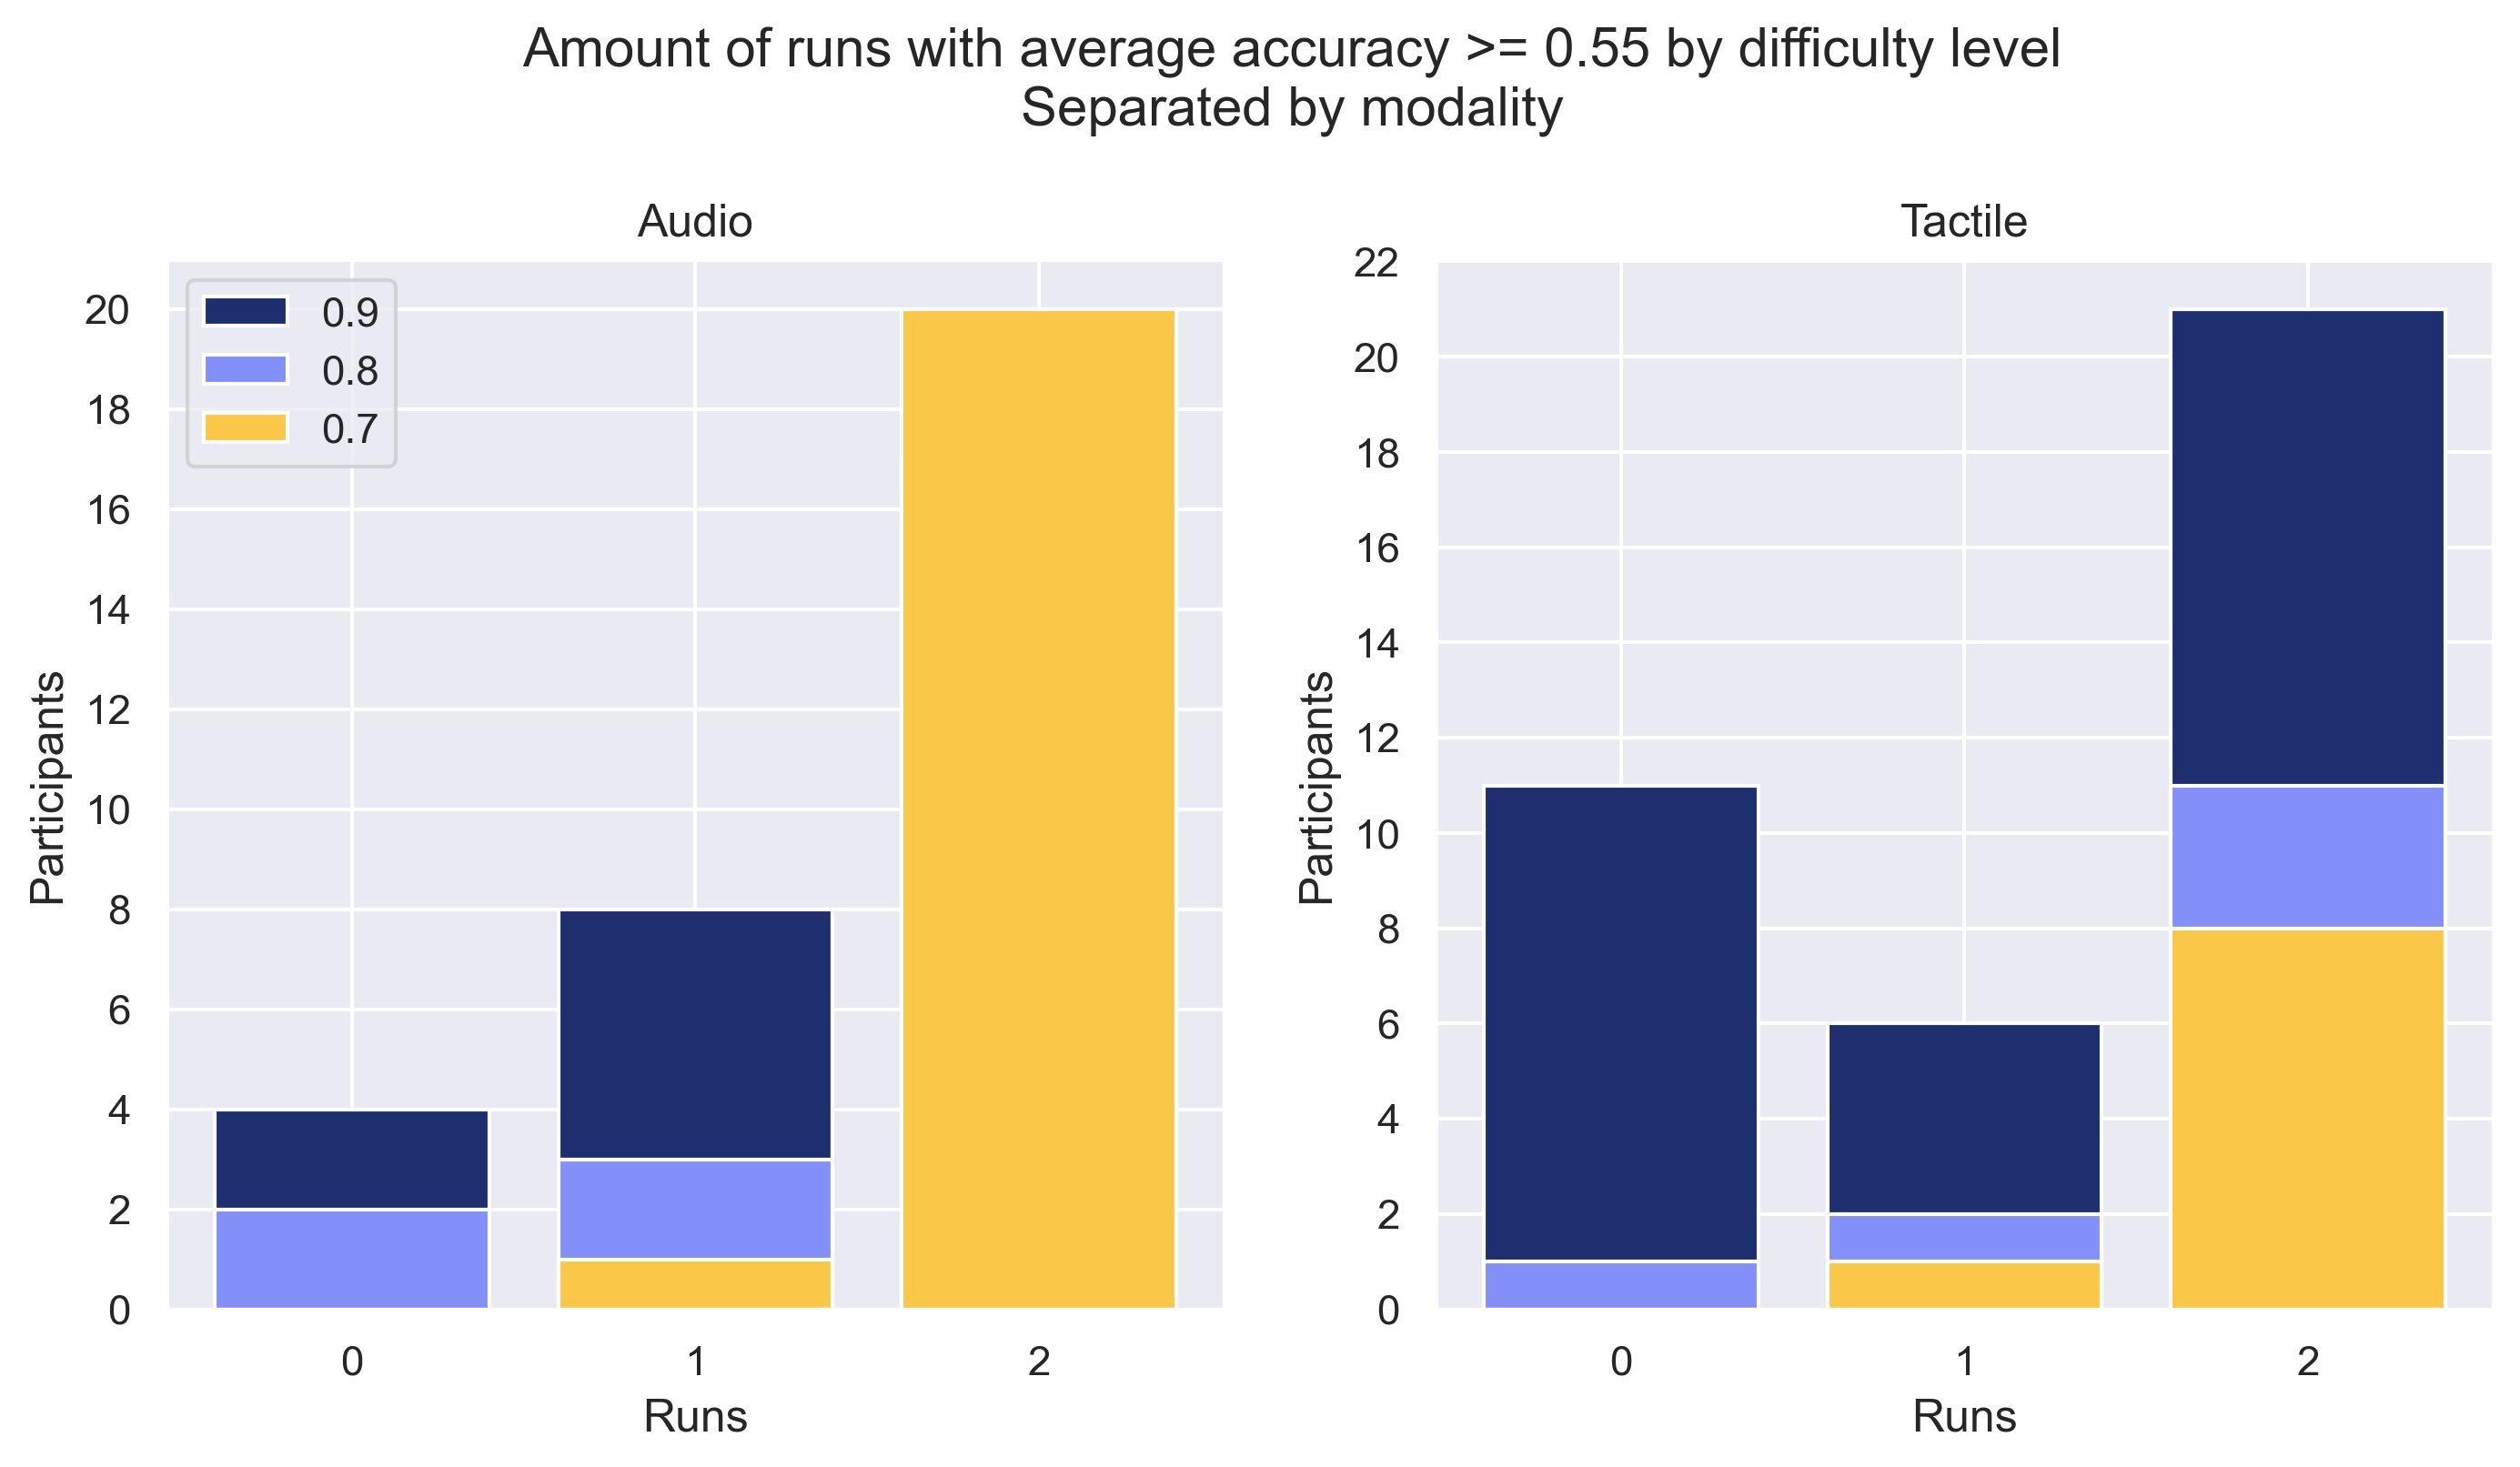

In [18]:
learning(mode="split", cutoff=0.55)

In [19]:
def assignment(cutoff=None):
    
    if platform.system() == 'Windows':
        wanted_dir = 'T:/projects/2022/bedi_casimiro_ruff_multisensorylearningfmri/data/sourcedata/behavior/modified_files'
    else:
        wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

    # Get all savedVals files
    files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv') and not name.startswith("._")]

    fig, ax = plt.subplots()
    allAccAudio = defaultdict(list)
    allAccTac = defaultdict(list)
    audioDiffCounter = defaultdict(int)
    tacDiffCounter = defaultdict(int)
    audioTactileDiff = list()
    for file in files:
        data = pd.read_csv(file)
        if max(data.runNumber) == 6:
            if ~np.isnan(data.audio[59]):
                audios = data[(data.runNumber == 3) | (data.runNumber == 5)].reset_index()
                tactiles = data[(data.runNumber == 4) | (data.runNumber == 6)].reset_index()
            else:
                tactiles = data[(data.runNumber == 3) | (data.runNumber == 5)].reset_index()
                audios = data[(data.runNumber == 4) | (data.runNumber == 6)].reset_index()
            
            audioDiff = sum(audios.feedbackAccuracy[:10])/10
            tactileDiff = sum(tactiles.feedbackAccuracy[:10])/10

            audioTactileDiff.append([audioDiff, tactileDiff])

            audioDiffCounter[audioDiff] += 1
            tacDiffCounter[tactileDiff] += 1
            
            accuraciesAudio = np.array(audios.totalAccuracy[59::60])
            accuraciesTactile = np.array(tactiles.totalAccuracy[59::60])
            if cutoff is not None:
                allAccAudio[audioDiff].extend(list(accuraciesAudio[accuraciesAudio >= cutoff]))
                allAccTac[tactileDiff].extend(list(accuraciesTactile[accuraciesTactile >= cutoff]))
            else:
                allAccAudio[audioDiff].extend(list(accuraciesAudio))
                allAccTac[tactileDiff].extend(list(accuraciesTactile))
        else:
            continue

    averagesAudio = {key: sum(vals) / len(vals) for key, vals in allAccAudio.items()}
    averagesTac = {key: sum(vals) / len(vals) for key, vals in allAccTac.items()}

    averagesAudio_s = [x[1] for x in sorted(averagesAudio.items())]
    averagesTac_s = [x[1] for x in sorted(averagesTac.items())]

    alphas_audio = np.where(averagesAudio_s >= averagesTac_s, 1, 0.2)
    alphas_tac = np.where(averagesTac_s >= averagesAudio_s, 1, 0.2)

    rgbaAudio = np.zeros((3, 4))
    rgbaTac = np.zeros((3, 4))

    rgbaAudio[:,:3] = [0.114, 0.184, 0.435]
    rgbaTac[:,:3] = [0.514, 0.565, 0.987]
    rgbaAudio[:,3] = alphas_audio
    rgbaTac[:,3] = alphas_tac


    audioDiffCounter_s = sorted(audioDiffCounter.items())
    tacDiffCounter_s = sorted(tacDiffCounter.items())
    x = np.arange(3)
    width = 0.4
    plt.bar(x-0.2, [x[1] for x in audioDiffCounter_s], width, color=rgbaAudio)
    plt.bar(x+0.2, [x[1] for x in tacDiffCounter_s], width, color=rgbaTac)
    ax.set_xticks(x)
    ax.set_xticklabels([x[0] for x in audioDiffCounter_s], fontsize=12)
    audio_patch = mpatches.Patch(color=rgbaAudio[0,:3], label='Audio')
    tactile_patch = mpatches.Patch(color=rgbaTac[0,:3], label='Tactile')
    plt.suptitle("Distribution of participants over difficulty levels")
    ax.legend(handles=[audio_patch, tactile_patch],  frameon=False, fontsize=16)
    ax.set_xlabel("Difficulty level")
    ax.set_ylabel("Participants")
    if cutoff is None:
        ax.set_title("Lower opacity indicates lower average accuracy")
    else:
        ax.set_title("Lower opacity indicates lower average accuracy (excl. below {})".format(cutoff))

    fig, ax = plt.subplots()
    audioTactileDiffDf = pd.DataFrame(audioTactileDiff, columns=["audio", "tactile"])
    df = pd.DataFrame(columns=['0.7','0.8','0.9'], index=['0.7','0.8','0.9'])
    df.iloc[0,0] = audioTactileDiffDf[(audioTactileDiffDf.audio == 0.7) & (audioTactileDiffDf.tactile == 0.7)].shape[0]
    df.iloc[0,1] = audioTactileDiffDf[(audioTactileDiffDf.audio == 0.7) & (audioTactileDiffDf.tactile == 0.8)].shape[0]
    df.iloc[0,2] = audioTactileDiffDf[(audioTactileDiffDf.audio == 0.7) & (audioTactileDiffDf.tactile == 0.9)].shape[0]
    df.iloc[1,0] = audioTactileDiffDf[(audioTactileDiffDf.audio == 0.8) & (audioTactileDiffDf.tactile == 0.7)].shape[0]
    df.iloc[1,1] = audioTactileDiffDf[(audioTactileDiffDf.audio == 0.8) & (audioTactileDiffDf.tactile == 0.8)].shape[0]
    df.iloc[1,2] = audioTactileDiffDf[(audioTactileDiffDf.audio == 0.8) & (audioTactileDiffDf.tactile == 0.9)].shape[0]
    df.iloc[2,0] = audioTactileDiffDf[(audioTactileDiffDf.audio == 0.9) & (audioTactileDiffDf.tactile == 0.7)].shape[0]
    df.iloc[2,1] = audioTactileDiffDf[(audioTactileDiffDf.audio == 0.9) & (audioTactileDiffDf.tactile == 0.8)].shape[0]
    df.iloc[2,2] = audioTactileDiffDf[(audioTactileDiffDf.audio == 0.9) & (audioTactileDiffDf.tactile == 0.9)].shape[0]
    sns.heatmap(df.astype(float), annot=True, cmap="crest")
    ax.set_xlabel("Tactile")
    ax.set_ylabel("Audio")
    fig.suptitle("Distribution of participants over combinations of difficulty levels")
    
    plt.show()

    #T-tests?
        
        


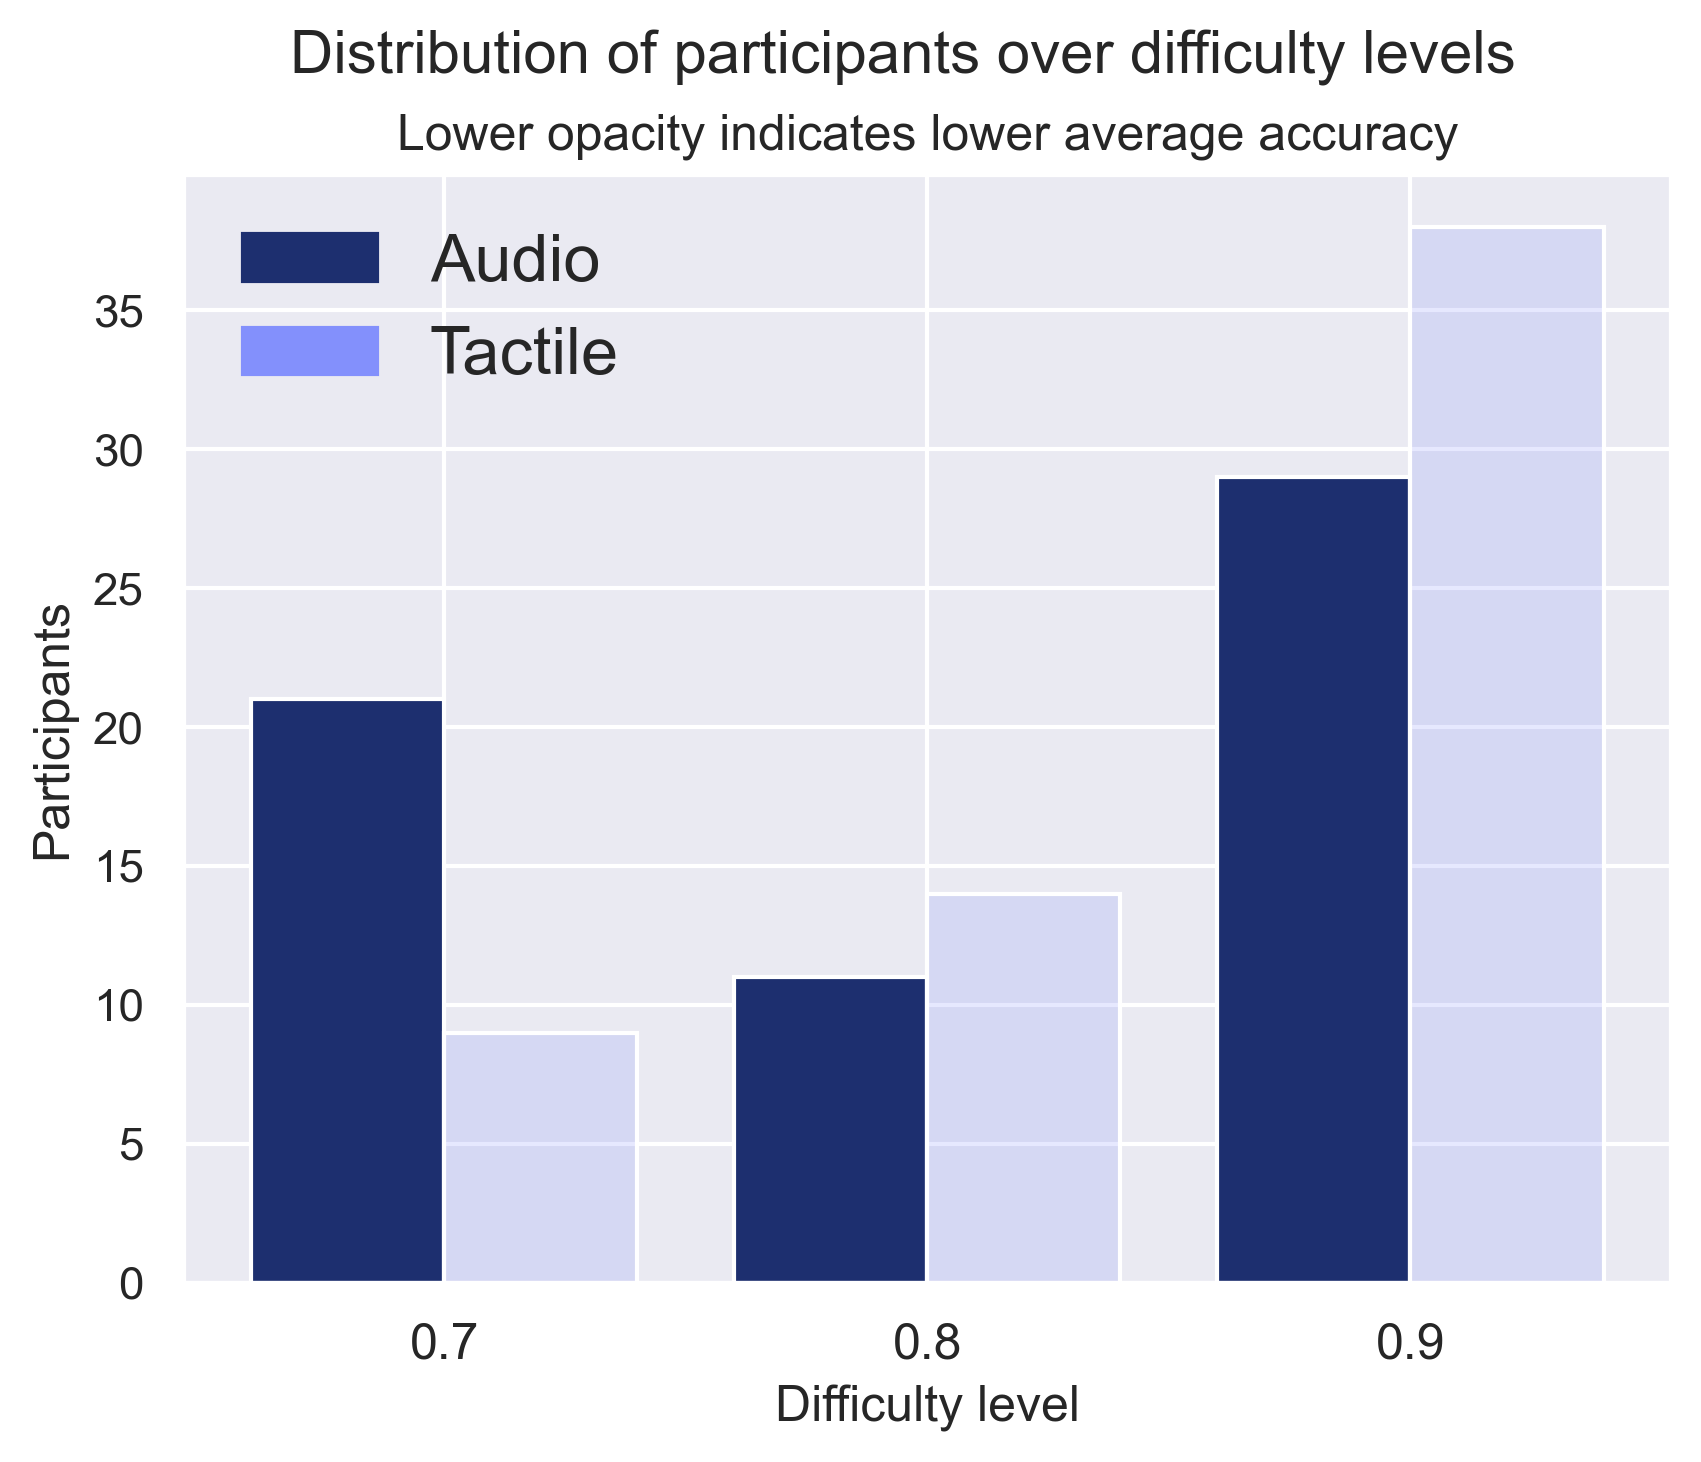

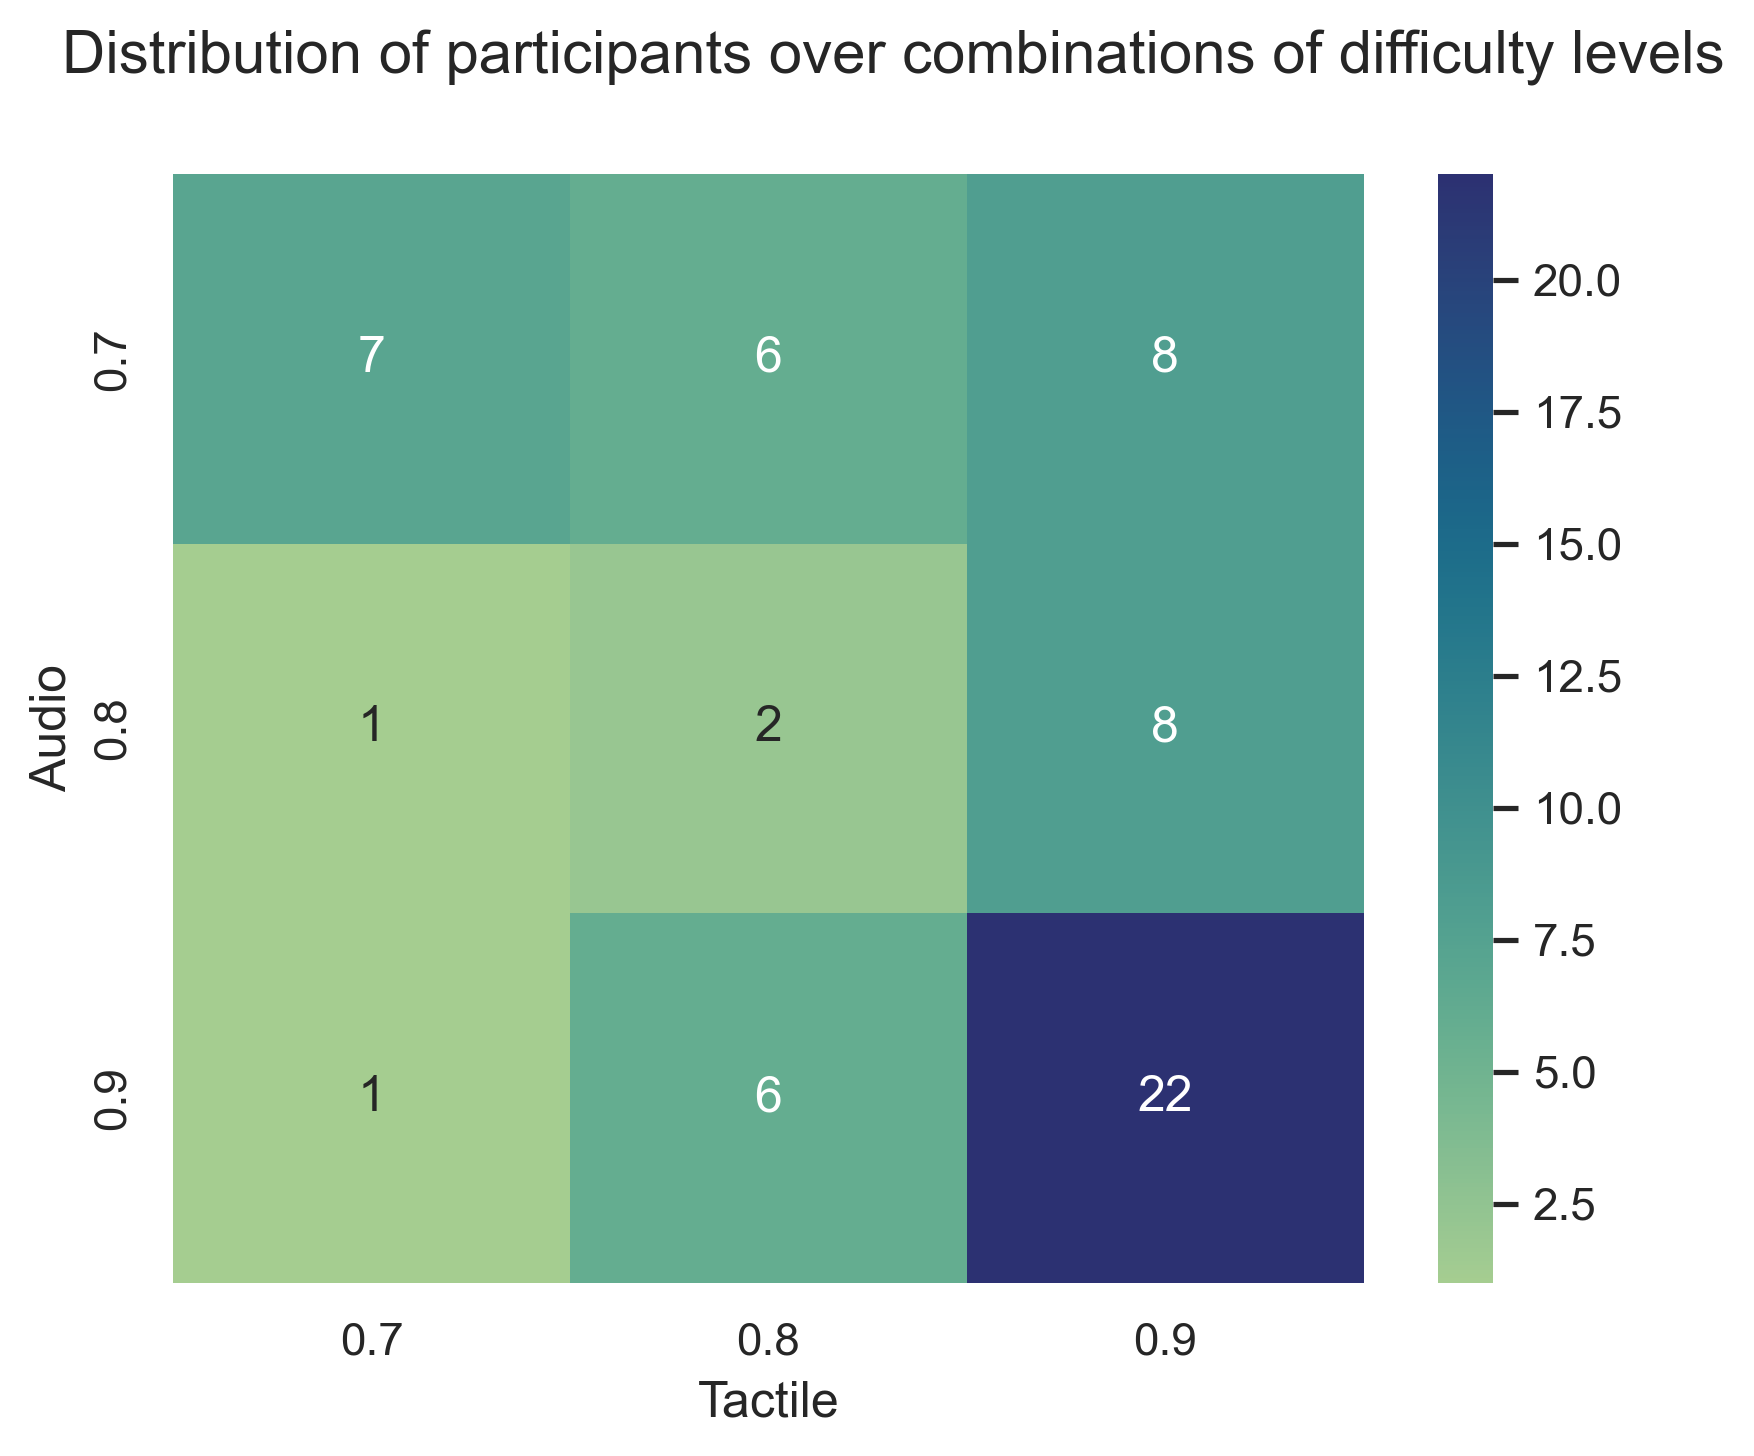

In [20]:
assignment()

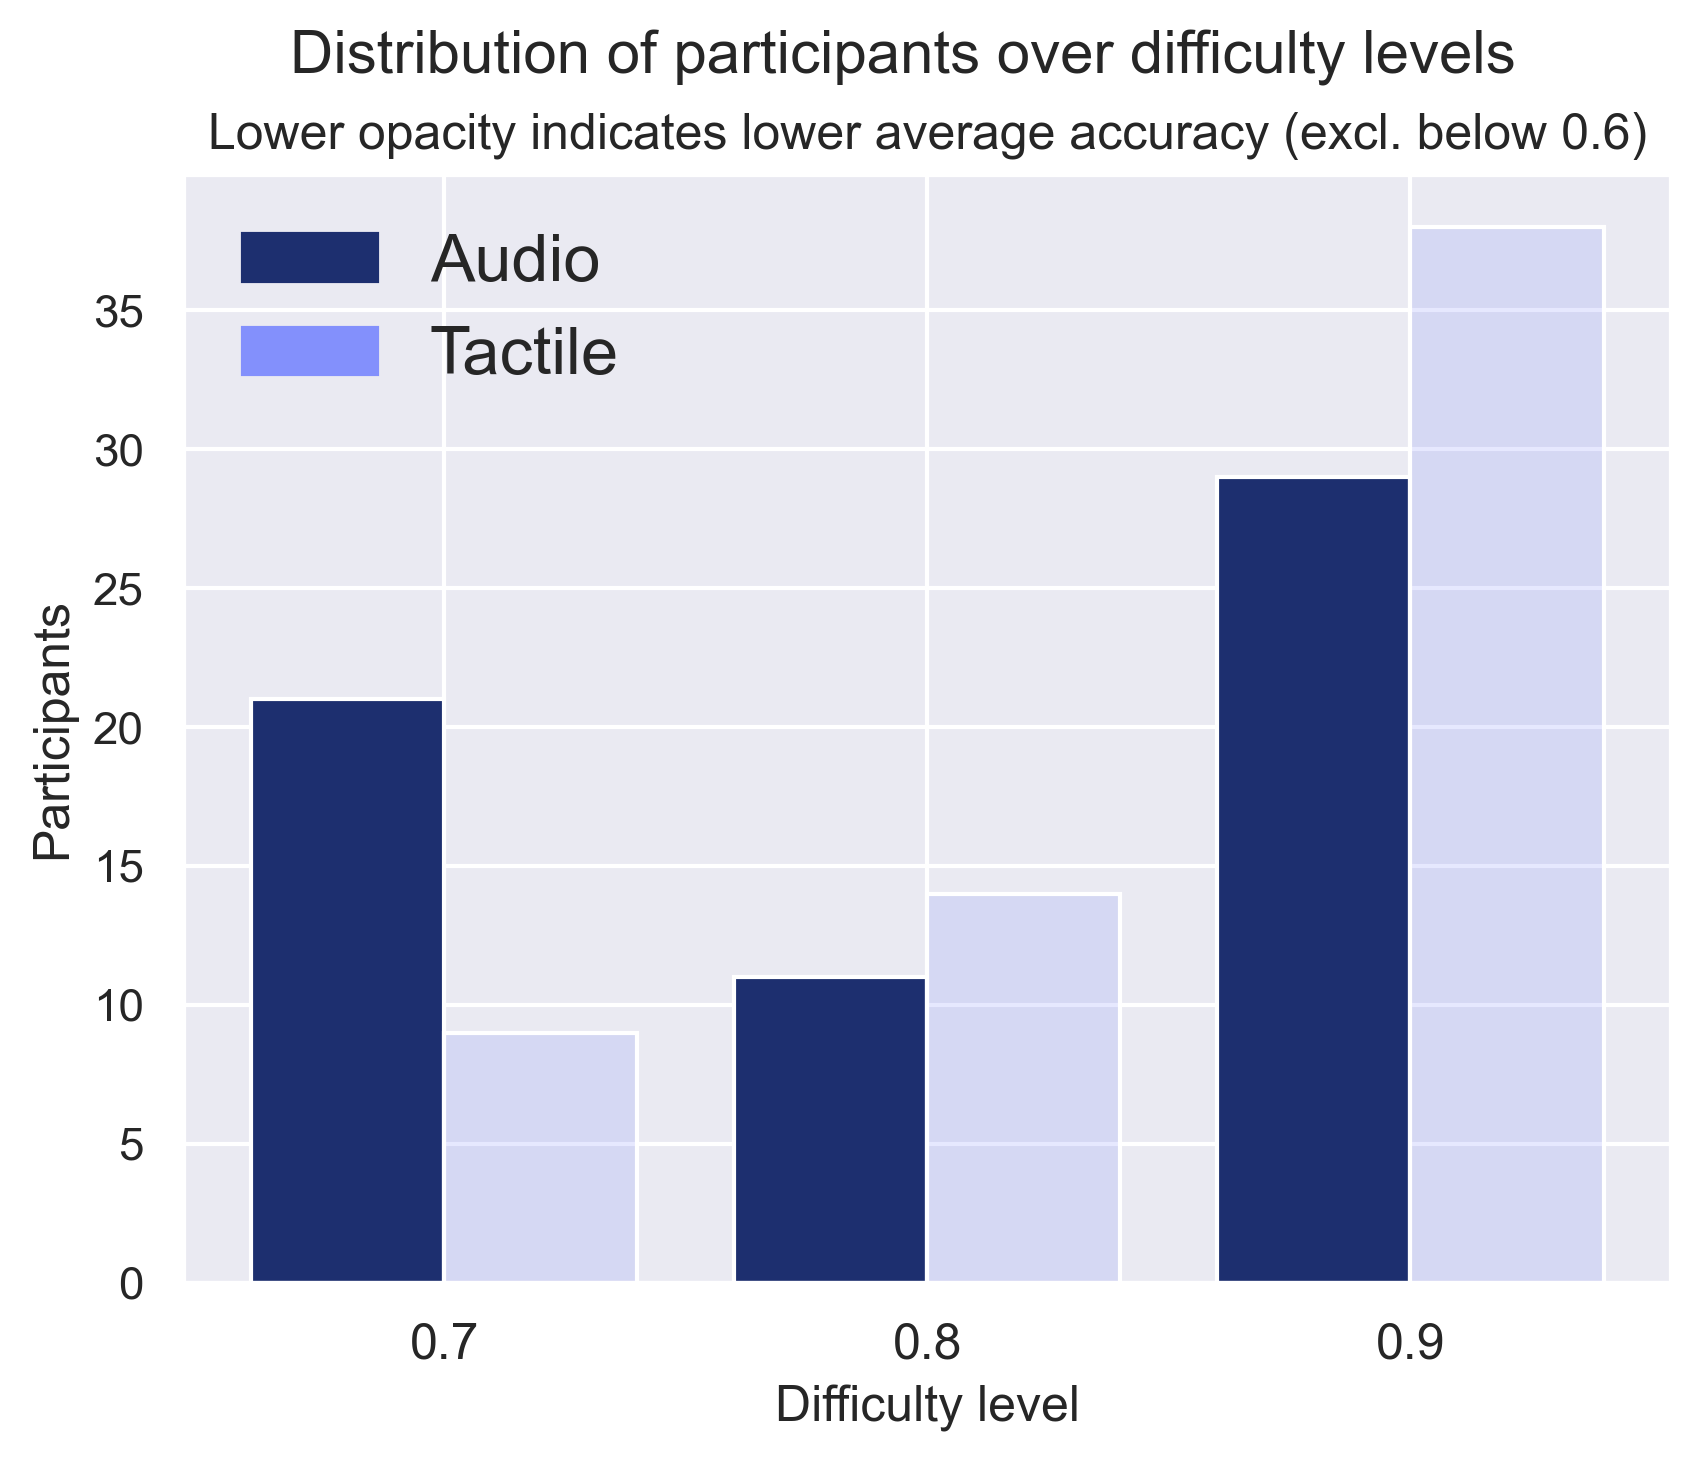

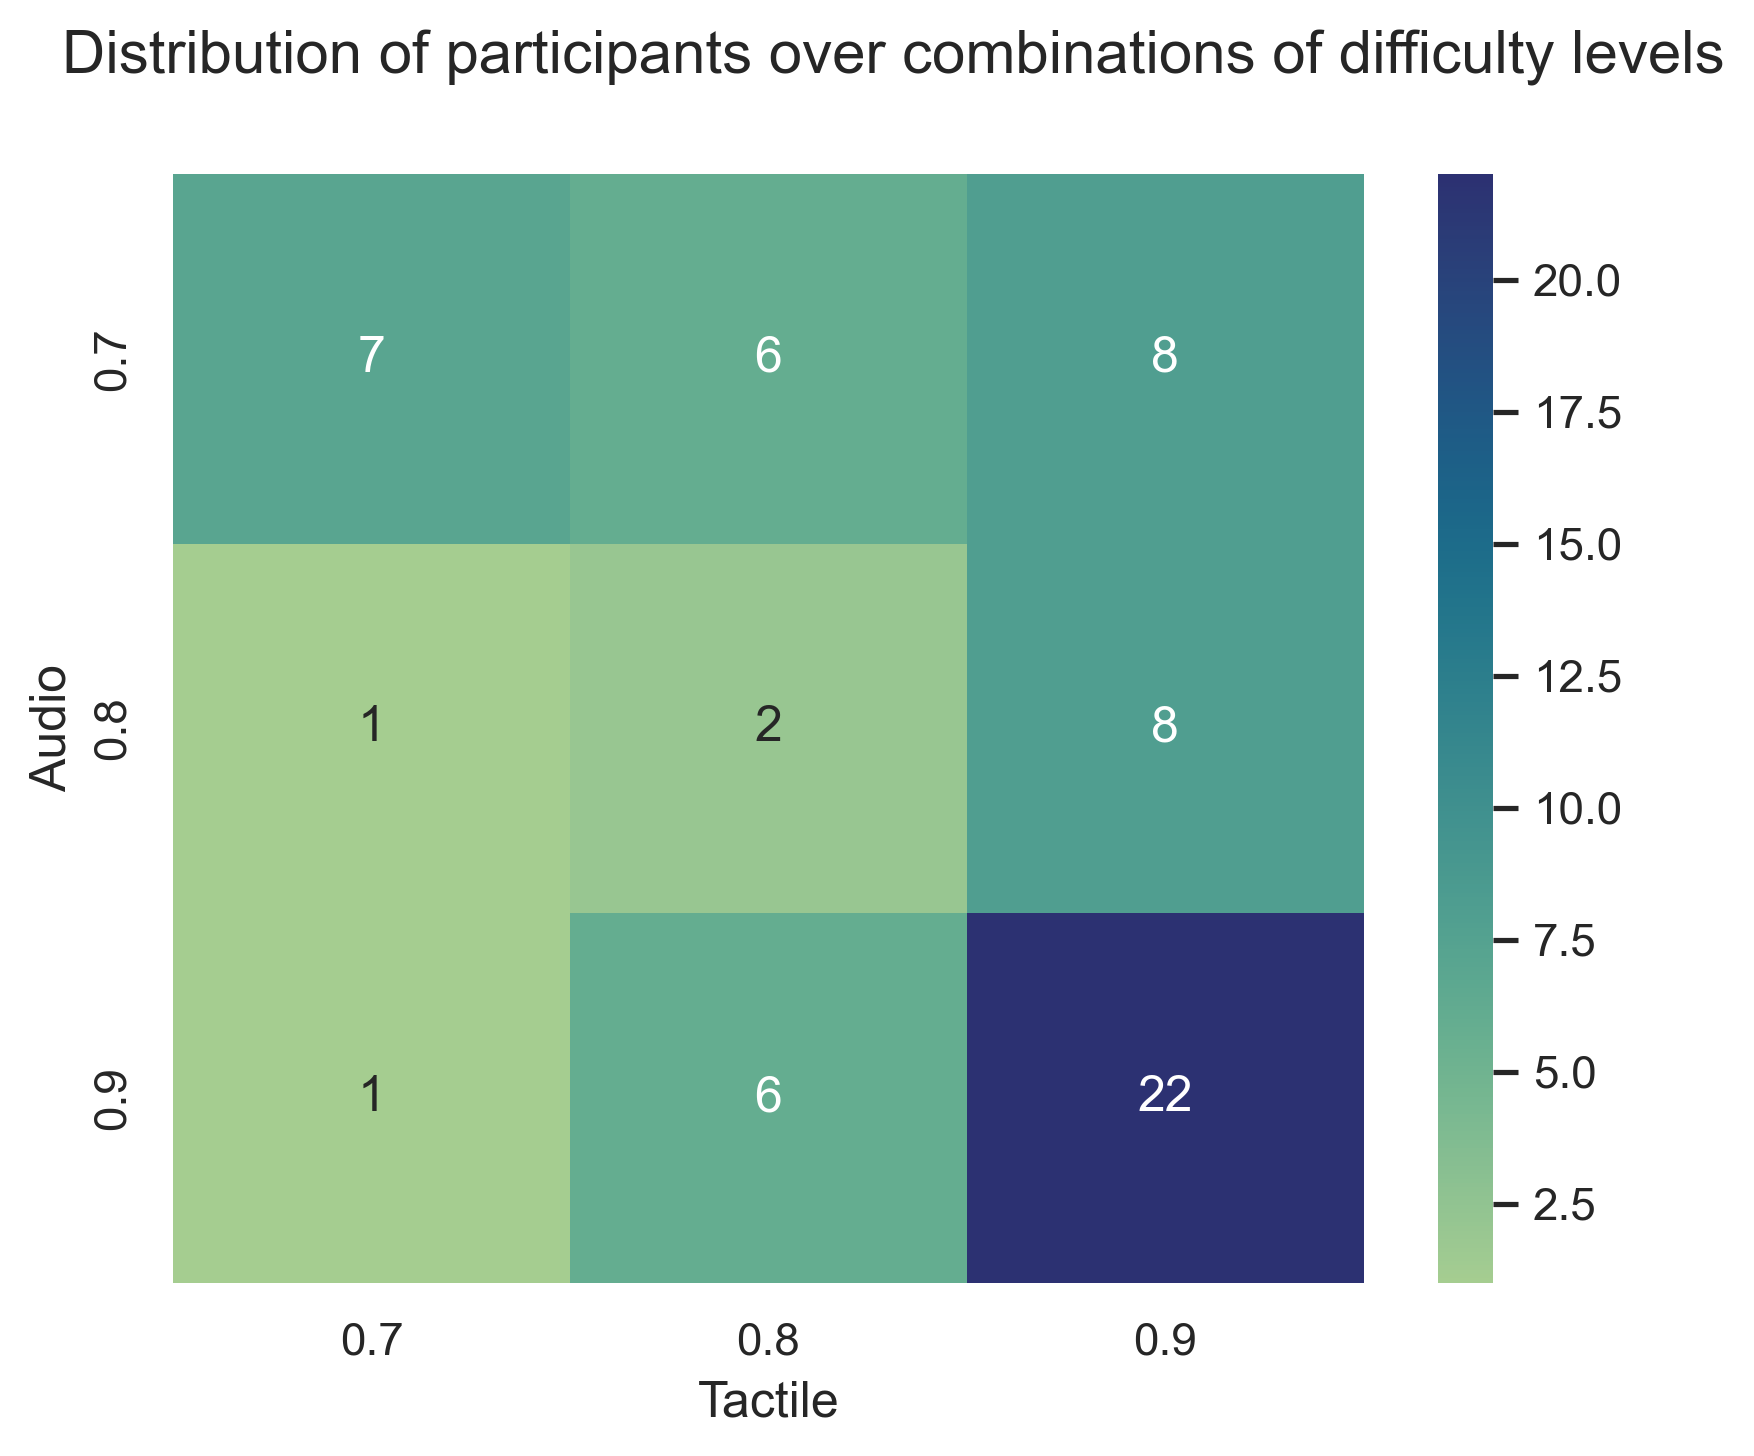

In [21]:
assignment(cutoff=0.6)

In [22]:
def reg_RT_Acc(mode="person"):
    #person: one dot per person in audio and tactile corr plot
    #runs: one dot per run for each person, so 2 dots in audio and tactile

    if platform.system() == 'Windows':
        wanted_dir = 'T:/projects/2022/bedi_casimiro_ruff_multisensorylearningfmri/data/sourcedata/behavior/modified_files'
    else:
        wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

    # Get all savedVals files
    files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv') and not name.startswith("._")]

    dataList = list()
    
    for file in files:
        data = pd.read_csv(file)
        if max(data.runNumber) == 6:
            if ~np.isnan(data.audio[59]):
                audios = data[(data.runNumber == 3) | (data.runNumber == 5)].reset_index()
                tactiles = data[(data.runNumber == 4) | (data.runNumber == 6)].reset_index()
            else:
                tactiles = data[(data.runNumber == 3) | (data.runNumber == 5)].reset_index()
                audios = data[(data.runNumber == 4) | (data.runNumber == 6)].reset_index()
            
            audioDiff = sum(audios.feedbackAccuracy[:10])/10
            tactileDiff = sum(tactiles.feedbackAccuracy[:10])/10
            
            if mode == "person":
                avgAudio_RT = np.mean(audios.responseTime)
                avgTac_RT = np.mean(tactiles.responseTime)

                avgAccuracyAudio = np.mean(np.array(audios.totalAccuracy[59::60]))
                avgAccuracyTactile = np.mean(np.array(tactiles.totalAccuracy[59::60]))

                dataList.append([avgAudio_RT, avgAccuracyAudio, audioDiff, "audio"])
                dataList.append([avgTac_RT, avgAccuracyTactile, tactileDiff, "tactile"])
            
            elif mode == "runs":
                avgAudio1_RT = np.mean(audios.responseTime[:60])
                avgAudio2_RT = np.mean(audios.responseTime[60:])

                avgTac1_RT = np.mean(tactiles.responseTime[:60])
                avgTac2_RT = np.mean(tactiles.responseTime[60:])

                avgAccuracyAudio1 = np.mean(audios.totalAccuracy[59])
                avgAccuracyAudio2 = np.mean(audios.totalAccuracy[119])

                avgAccuracyTactile1 = np.mean(tactiles.totalAccuracy[59])
                avgAccuracyTactile2 = np.mean(tactiles.totalAccuracy[119])

                dataList.append([avgAudio1_RT, avgAccuracyAudio1, audioDiff, "audio"])
                dataList.append([avgAudio2_RT, avgAccuracyAudio2, audioDiff, "audio"])
                dataList.append([avgTac1_RT, avgAccuracyTactile1, tactileDiff, "tactile"])
                dataList.append([avgTac2_RT, avgAccuracyTactile2, tactileDiff, "tactile"])
        else:
            continue

    dataDf = pd.DataFrame(dataList, columns=["RT", "Acc", "difficulty", "type"])
    

    rAudio7, pAudio7 = stats.pearsonr(dataDf[(dataDf.difficulty == 0.7) & (dataDf.type == "audio")].Acc, dataDf[(dataDf.difficulty == 0.7) & (dataDf.type == "audio")].RT)
    rAudio8, pAudio8 = stats.pearsonr(dataDf[(dataDf.difficulty == 0.8) & (dataDf.type == "audio")].Acc, dataDf[(dataDf.difficulty == 0.8) & (dataDf.type == "audio")].RT)
    rAudio9, pAudio9 = stats.pearsonr(dataDf[(dataDf.difficulty == 0.9) & (dataDf.type == "audio")].Acc, dataDf[(dataDf.difficulty == 0.9) & (dataDf.type == "audio")].RT)

    rTac7, pTac7 = stats.pearsonr(dataDf[(dataDf.difficulty == 0.7) & (dataDf.type == "tactile")].Acc, dataDf[(dataDf.difficulty == 0.7) & (dataDf.type == "tactile")].RT)
    rTac8, pTac8 = stats.pearsonr(dataDf[(dataDf.difficulty == 0.8) & (dataDf.type == "tactile")].Acc, dataDf[(dataDf.difficulty == 0.8) & (dataDf.type == "tactile")].RT)
    rTac9, pTac9 = stats.pearsonr(dataDf[(dataDf.difficulty == 0.9) & (dataDf.type == "tactile")].Acc, dataDf[(dataDf.difficulty == 0.9) & (dataDf.type == "tactile")].RT)
    
    
    g = sns.lmplot(
    data=dataDf, x="Acc", y="RT",
    hue="type", col="difficulty", height=4, legend=True, facet_kws=dict(sharex=False, sharey=False))
    ax = plt.gca()
    
    if mode == "person":
        g.figure.suptitle("correlation between average accuracy and response time - one dot per person (runs 3-6)")
    if mode == "runs":
        g.figure.suptitle("correlation between average accuracy and response time - one dot per run (runs 3-6)")

    g.figure.subplots_adjust(top=.8)
    g.set_xlabels("Accuracy")
    g.set_ylabels("Response Time")
    

    print("For Audio \n 0.7 - Pearson's R: {0}, p-value: {1} \n 0.8 - Pearson's R: {2}, p-value: {3} \n 0.9 - Pearson's R: {4}, p-value: {5}".format(rAudio7, pAudio7, rAudio8, pAudio8, rAudio9, pAudio9))
    print("For Tactile \n 0.7 - Pearson's R: {0}, p-value: {1} \n 0.8 - Pearson's R: {2}, p-value: {3} \n 0.9 - Pearson's R: {4}, p-value: {5}".format(rTac7, pTac7, rTac8, pTac8, rTac9, pTac9))
    

For Audio 
 0.7 - Pearson's R: 0.02611055981285025, p-value: 0.9105494856143096 
 0.8 - Pearson's R: -0.29837048768922975, p-value: 0.3728154929545378 
 0.9 - Pearson's R: 0.05759797034434366, p-value: 0.7666365978255534
For Tactile 
 0.7 - Pearson's R: -0.20787838957666033, p-value: 0.5914688446993054 
 0.8 - Pearson's R: 0.47994323658691523, p-value: 0.08241956563146102 
 0.9 - Pearson's R: -0.13100232053512334, p-value: 0.4330615067360447


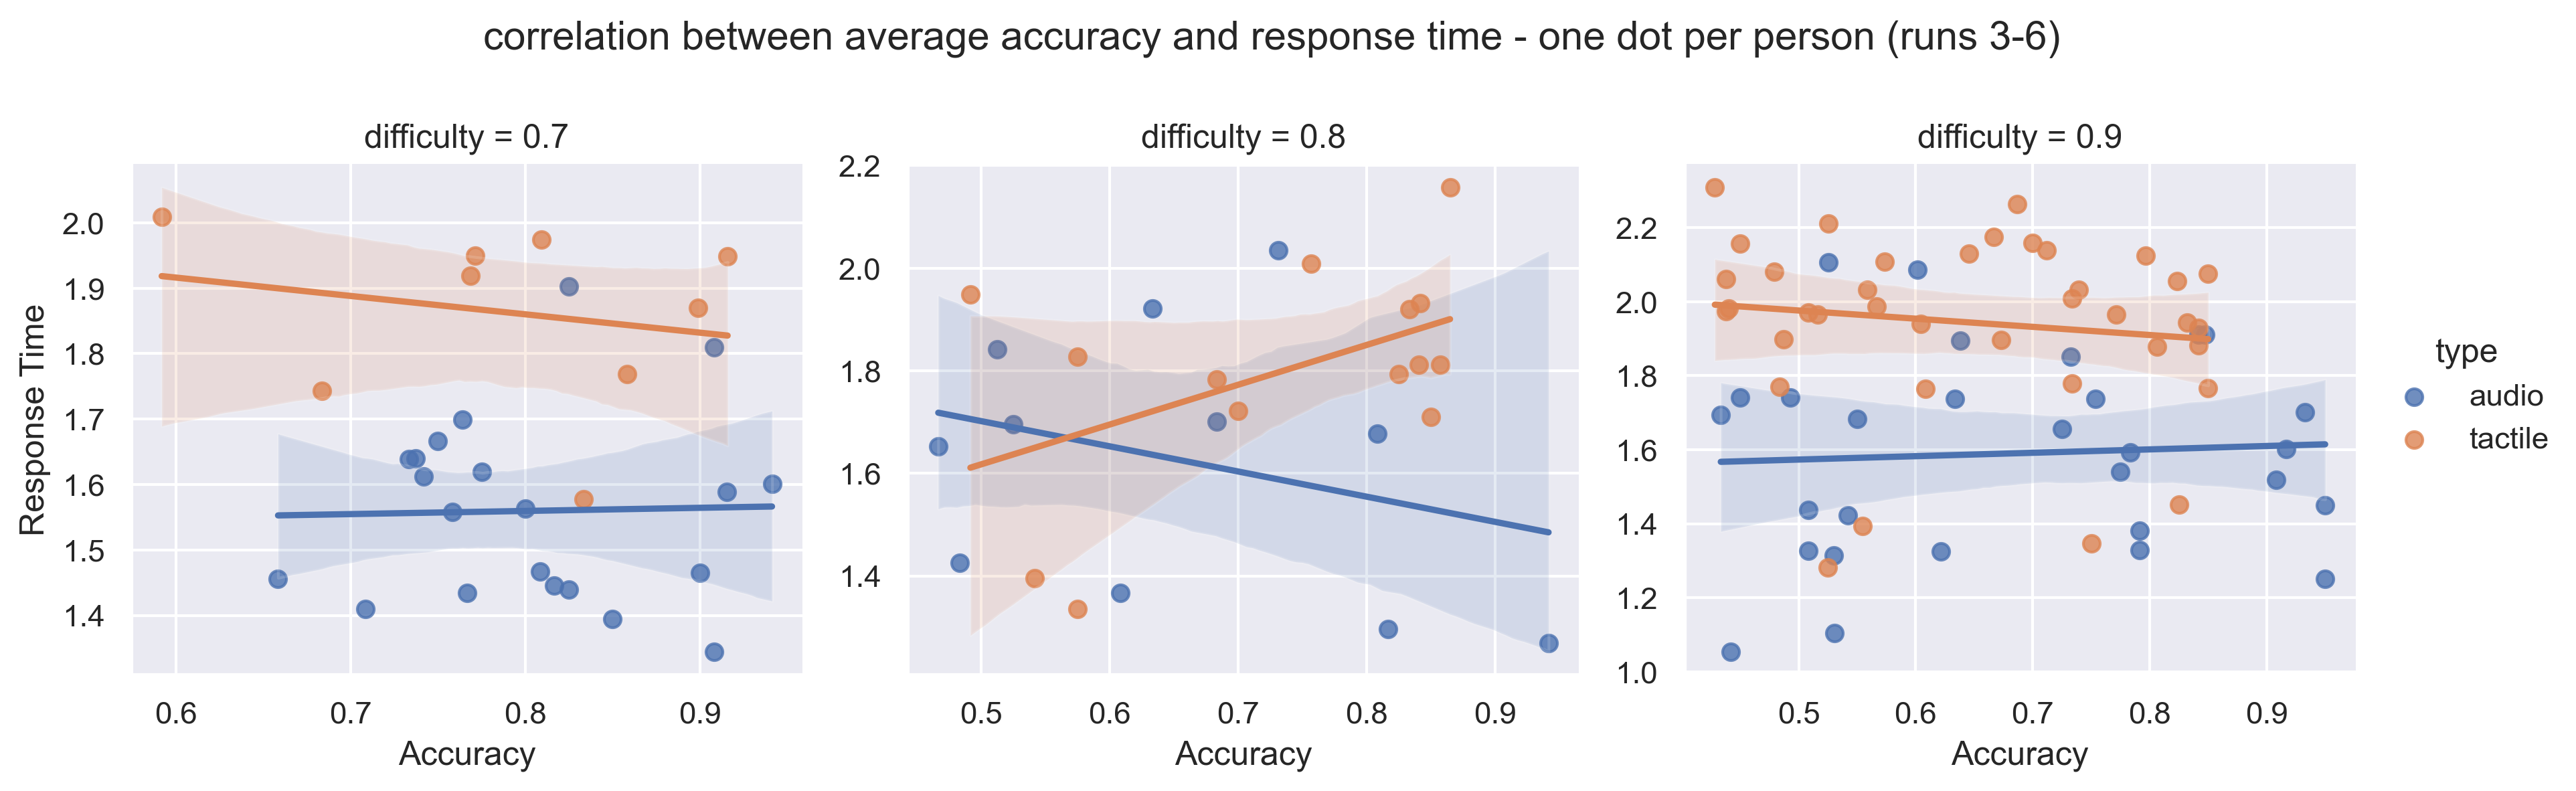

In [23]:
reg_RT_Acc()

For Audio 
 0.7 - Pearson's R: -0.16249949725790064, p-value: 0.3038607187974707 
 0.8 - Pearson's R: -0.29004070723138503, p-value: 0.19041235568798465 
 0.9 - Pearson's R: 0.022495181098936178, p-value: 0.8668901323189405
For Tactile 
 0.7 - Pearson's R: -0.3437685347782781, p-value: 0.16247841029380808 
 0.8 - Pearson's R: 0.33323807527434385, p-value: 0.08312079178970243 
 0.9 - Pearson's R: -0.12264007157836448, p-value: 0.2912321992812063


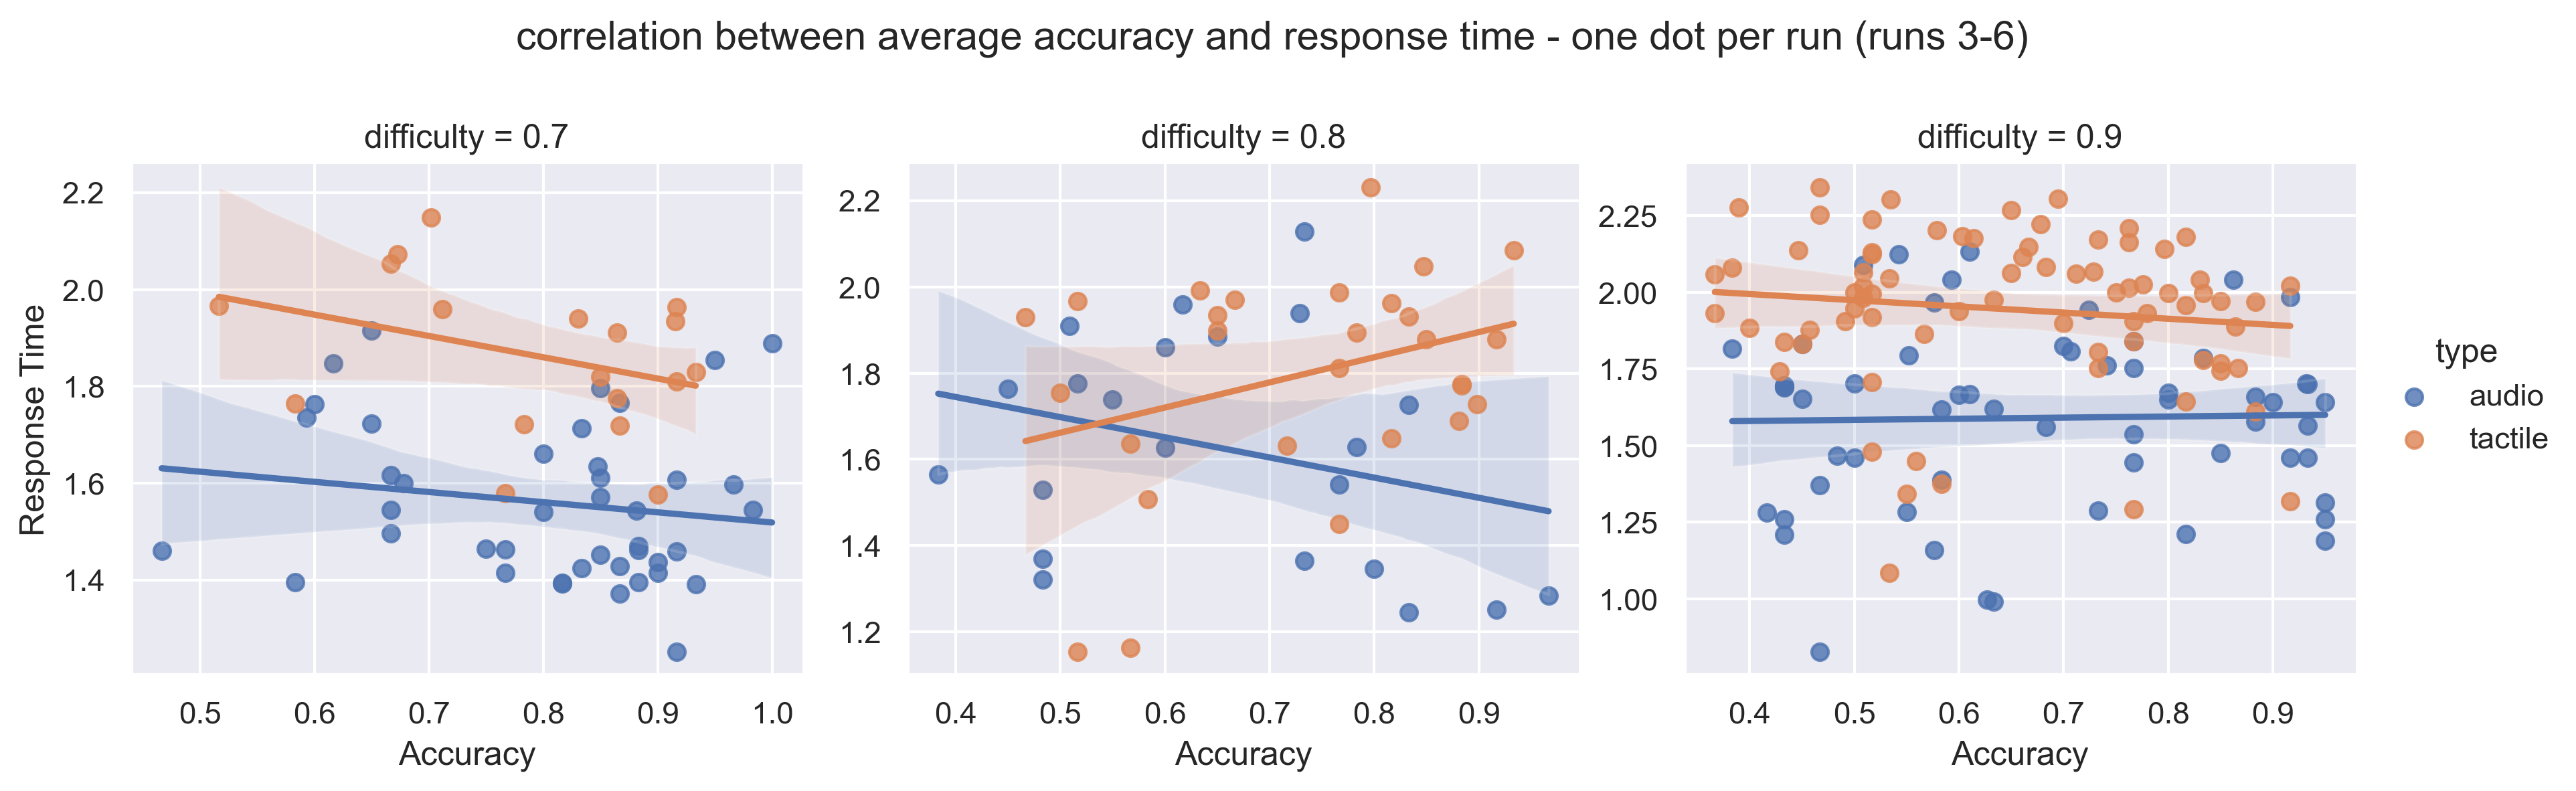

In [24]:
reg_RT_Acc(mode="runs")

In [25]:
def reg_run1_run2():

    if platform.system() == 'Windows':
        wanted_dir = 'T:/projects/2022/bedi_casimiro_ruff_multisensorylearningfmri/data/sourcedata/behavior/modified_files'
    else:
        wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

    # Get all savedVals files
    files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv') and not name.startswith("._")]

    dataList = list()
    
    for file in files:
        data = pd.read_csv(file)
        if max(data.runNumber) == 6:
            if ~np.isnan(data.audio[59]):
                audios = data[(data.runNumber == 3) | (data.runNumber == 5)].reset_index()
                tactiles = data[(data.runNumber == 4) | (data.runNumber == 6)].reset_index()
            else:
                tactiles = data[(data.runNumber == 3) | (data.runNumber == 5)].reset_index()
                audios = data[(data.runNumber == 4) | (data.runNumber == 6)].reset_index()

            avgAudio1_RT = np.mean(audios.responseTime[:60])
            avgAudio2_RT = np.mean(audios.responseTime[60:])

            avgTac1_RT = np.mean(tactiles.responseTime[:60])
            avgTac2_RT = np.mean(tactiles.responseTime[60:])

            avgAccuracyAudio1 = np.mean(audios.totalAccuracy[59])
            avgAccuracyAudio2 = np.mean(audios.totalAccuracy[119])

            avgAccuracyTactile1 = np.mean(tactiles.totalAccuracy[59])
            avgAccuracyTactile2 = np.mean(tactiles.totalAccuracy[119])

            dataList.append([avgAudio1_RT, avgAudio2_RT, "RT", "audio"])
            dataList.append([avgTac1_RT, avgTac2_RT, "RT", "tactile"])
            dataList.append([avgAccuracyAudio1, avgAccuracyAudio2, "accuracy", "audio"])
            dataList.append([avgAccuracyTactile1, avgAccuracyTactile2, "accuracy", "tactile"])
        
        else:
            continue

    dataDf = pd.DataFrame(dataList, columns=["run 1", "run 2", "measure", "type"])

    g = sns.lmplot(
    data=dataDf, x="run 1", y="run 2",
    hue="type", col="measure", height=4, legend=True, facet_kws=dict(sharex=False, sharey=False))

    def annotate(data, **kws):
        r, p = stats.pearsonr(dataDf[dataDf.type == "audio"]['run 1'], dataDf[dataDf.type == "audio"]['run 2'])
        r2, p2 = stats.pearsonr(dataDf[dataDf.type == "tactile"]['run 1'], dataDf[dataDf.type == "tactile"]['run 2'])
        ax = plt.gca()
        ax.text(.01, .85, 'Audio: r={:.2f}, p={:.2g} \nTactile: r={:.2f}, p={:.2g}'.format(r, p, r2, p2),
            transform=ax.transAxes)
    
    g.map_dataframe(annotate)
    g.figure.suptitle("Correlation between response time and accuracy of runs within modality (after calibration)")
    g.figure.subplots_adjust(top=.8)
    plt.show()

    
        

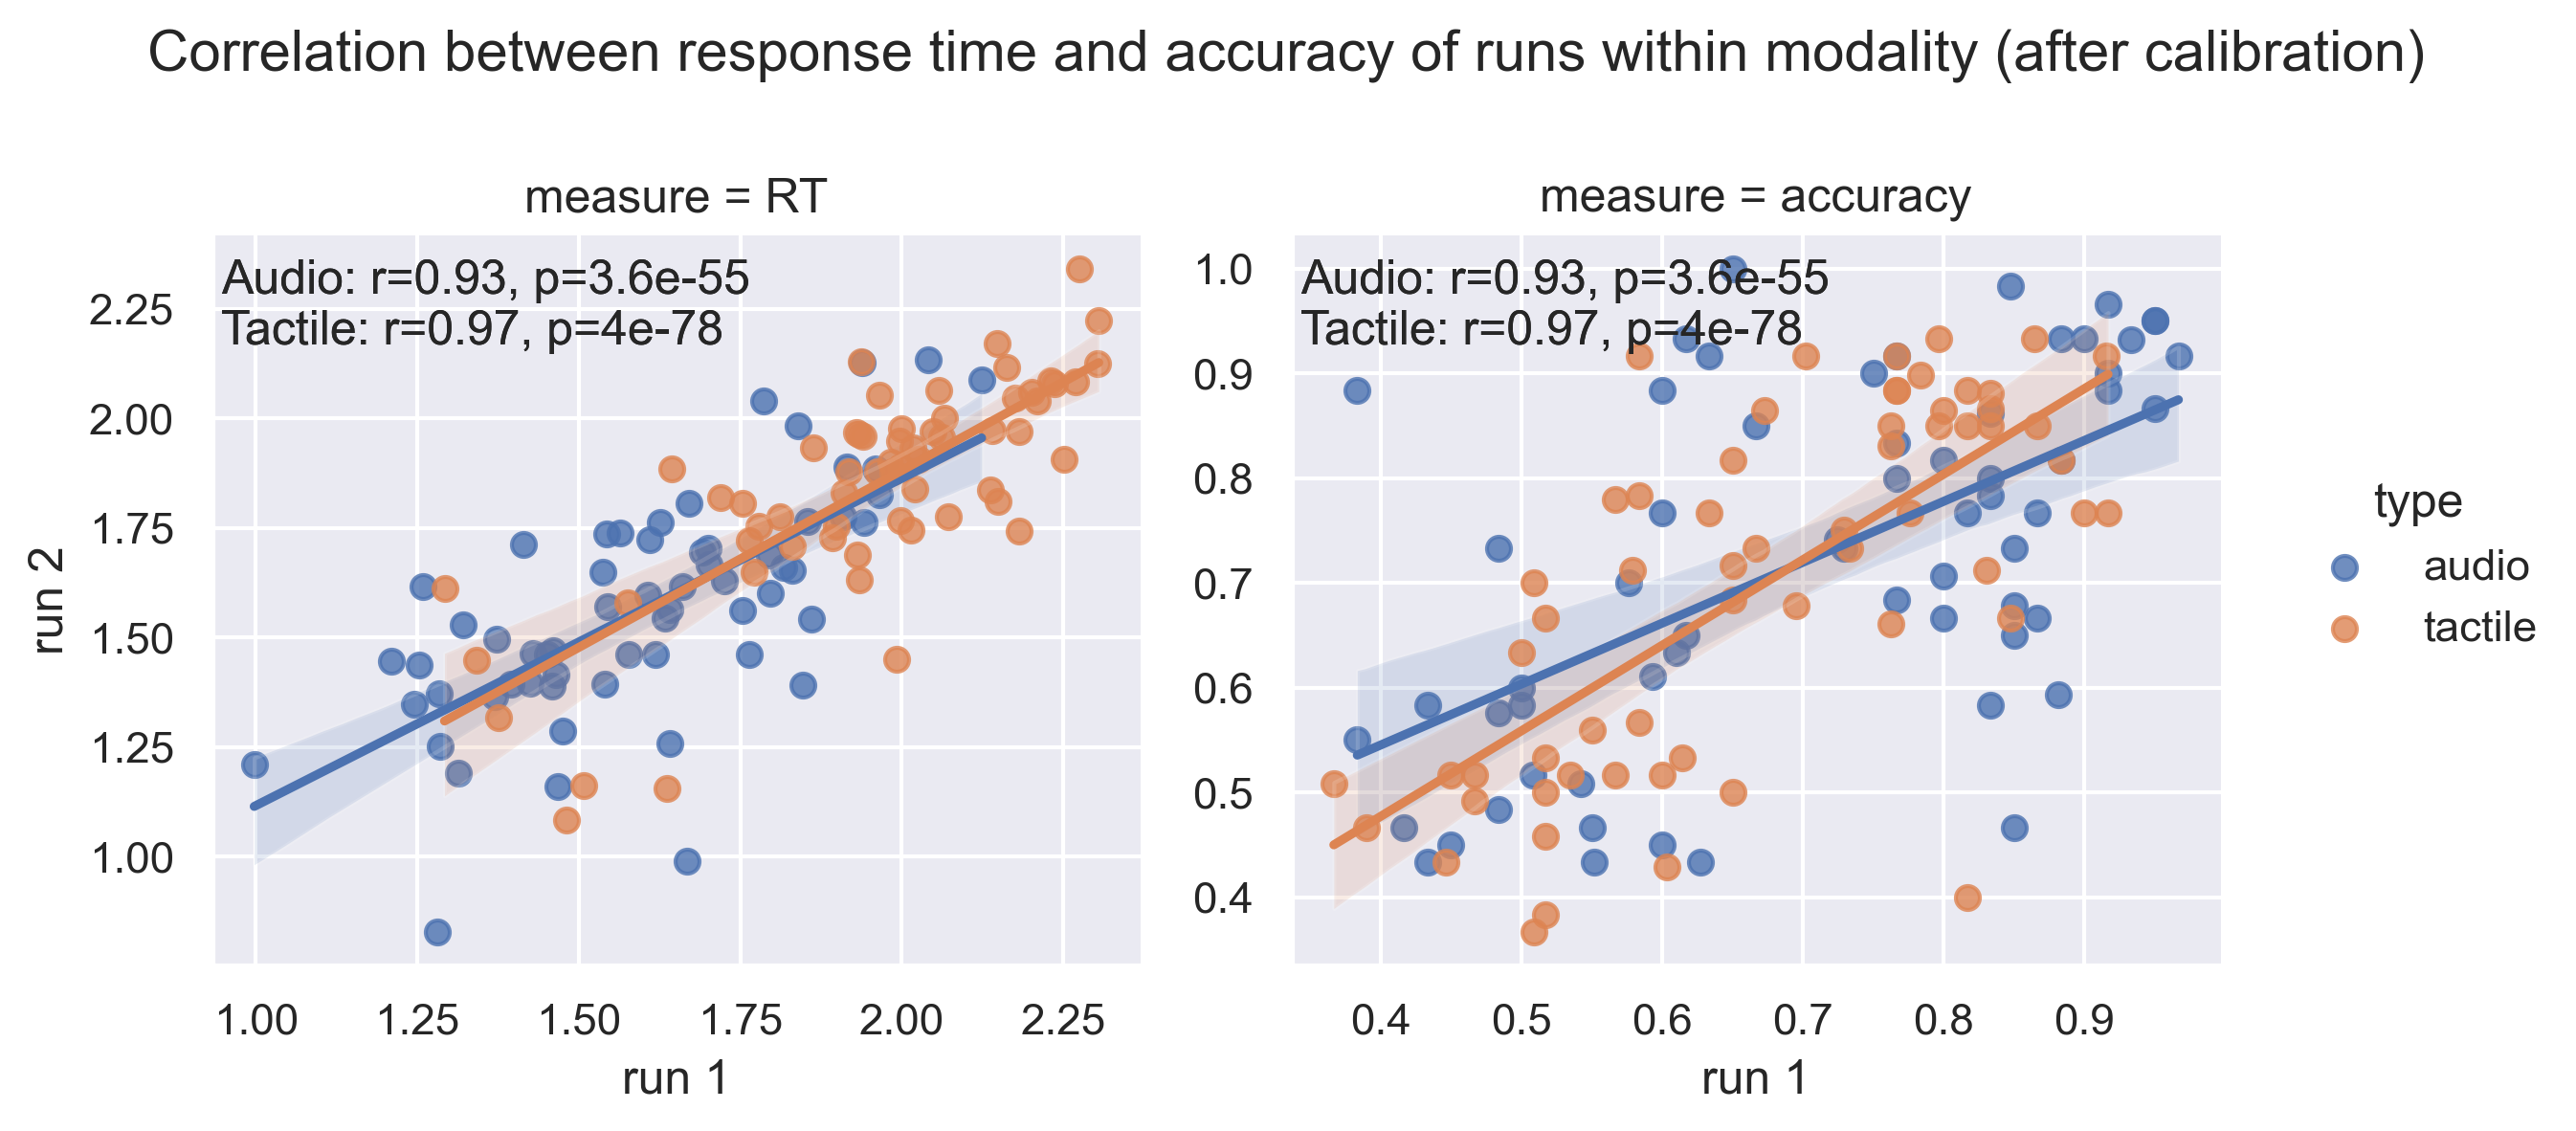

In [26]:
reg_run1_run2()

In [64]:
def effectsOnRT(exclude=False, cutoff=0.6, mode="bar"):
    #Mode: bar, barSplit or box
    plt.rcParams['axes.facecolor'] = 'white'
    # Set a high DPI for high-quality images
    plt.rcParams['figure.dpi'] = 300
    if platform.system() == 'Windows':
        wanted_dir = '/data/sourcedata/behavior/modified_files'
    else:
        wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

    # Get all savedVals files
    files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv') and not name.startswith("._")]

    # Loop through files and store RT vals, audio, tactile with probability per run and trial type
    audioRTCondRuns, audioRTAccCondRuns, audioAccCondRuns, audioAccRuns, tactileRTCondRuns, tactileRTAccCondRuns, tactileAccCondRuns, tactileAccRuns = (list() for i in range(8))

    for file in files:
        data = pd.read_csv(file)
        if max(data.runNumber) == 6:
            if ~np.isnan(data.audio[59]):
                audios = data[(data.runNumber == 1) | (data.runNumber == 3) | (data.runNumber == 5)][['responseTime', 'audio', 'tactile', 'combinationConditionalProbability', 'totalAccuracy', 'accurate']].reset_index()
                audiosAcc = audios[audios.accurate == 1].reset_index()
                tactiles = data[(data.runNumber == 2) | (data.runNumber == 4) | (data.runNumber == 6)][['responseTime', 'audio', 'tactile', 'combinationConditionalProbability', 'totalAccuracy', 'accurate']].reset_index()
                tactilesAcc = tactiles[tactiles.accurate == 1].reset_index()
            else:
                tactiles = data[(data.runNumber == 1) | (data.runNumber == 3) | (data.runNumber == 5)][['responseTime', 'audio', 'tactile', 'combinationConditionalProbability', 'totalAccuracy', 'accurate']].reset_index()
                tactilesAcc = tactiles[tactiles.accurate == 1].reset_index()
                audios = data[(data.runNumber == 2) | (data.runNumber == 4) | (data.runNumber == 6)][['responseTime', 'audio', 'tactile', 'combinationConditionalProbability', 'totalAccuracy', 'accurate']].reset_index()
                audiosAcc = audios[audios.accurate == 1].reset_index()
        
            if exclude:

                avgAccuracyAudio = np.array(audios.totalAccuracy[59::60])
                avgAccuracyTactile = np.array(tactiles.totalAccuracy[59::60])
                belowCutAudio = np.r_[[range(accIdx*60, accIdx*60+60) for accIdx in np.argwhere(avgAccuracyAudio < cutoff).flatten()]]
                belowCutTactile = np.r_[[range(accIdx*60, accIdx*60+60) for accIdx in np.argwhere(avgAccuracyTactile < cutoff).flatten()]]
                
                audios = audios.drop(belowCutAudio.flatten())
                tactiles = tactiles.drop(belowCutTactile.flatten())
            
            audioRTCondRuns.append(audios.groupby(["combinationConditionalProbability"])["responseTime"].mean().reset_index())
            audioRTAccCondRuns.append(audiosAcc.groupby(["combinationConditionalProbability"])["responseTime"].mean().reset_index())
            audioAccCondRuns.append(audios.groupby(["combinationConditionalProbability"])["accurate"].mean().reset_index())
            audioAccRuns.append(audios.groupby(["accurate"])["responseTime"].mean().reset_index())

            tactileRTCondRuns.append(tactiles.groupby(["combinationConditionalProbability"])["responseTime"].mean().reset_index())
            tactileRTAccCondRuns.append(tactilesAcc.groupby(["combinationConditionalProbability"])["responseTime"].mean().reset_index())
            tactileAccCondRuns.append(tactiles.groupby(["combinationConditionalProbability"])["accurate"].mean().reset_index())
            tactileAccRuns.append(tactiles.groupby(["accurate"])["responseTime"].mean().reset_index())
        else:
            continue
      
    df_audioRTCondRuns = pd.concat(audioRTCondRuns).reset_index()
    df_audioRTCondRuns.head()
    df_audioRTAccCondRuns = pd.concat(audioRTAccCondRuns)
    df_tactileRTCondRuns = pd.concat(tactileRTCondRuns)
    df_tactileRTAccCondRuns = pd.concat(tactileRTAccCondRuns)
    df_audioAccCondRuns = pd.concat(audioAccCondRuns)
    df_tactileAccCondRuns = pd.concat(tactileAccCondRuns)

    df_audioAccRuns = pd.concat(audioAccRuns)
    df_tactileAccRuns = pd.concat(tactileAccRuns)

    if mode == "bar":
        fig, ax = plt.subplots(ncols=2, figsize=(11,5))
        b1 = sns.barplot(data=df_audioRTCondRuns, x="combinationConditionalProbability", y="responseTime", ax=ax[0])
        b1.set_title("Audio", fontsize=22, weight='bold')
        b1.set_xlabel("Conditional probability", fontsize=22, weight='bold')
        b1.set_ylabel("Response time", fontsize=22, weight='bold')
        b2 = sns.barplot(data=df_tactileRTCondRuns, x="combinationConditionalProbability", y="responseTime",  ax=ax[1])
        b2.set_title("Tactile", fontsize=22, weight='bold')
        b2.set_xlabel("Conditional probability", fontsize=22, weight='bold')
        b2.set_ylabel("Response time", fontsize=22, weight='bold')
        b1.set(ylim=(np.mean(df_audioRTCondRuns.responseTime)-0.1, np.mean(df_audioRTCondRuns.responseTime)+0.1))
        b2.set(ylim=(np.mean(df_tactileRTCondRuns.responseTime)-0.1, np.mean(df_tactileRTCondRuns.responseTime)+0.1))
        # ax.yaxis.set_ticks_position('left')
        # ax.spines['bottom'].set_color('black')
        # ax.spines['left'].set_color('black')
        if exclude:
            fig.suptitle("Effect of conditional probability on response time\n(excl. runs with average accuracy < {})".format(cutoff), y=1.05, fontsize=22, weight='bold')
        else:
            fig.suptitle("Effect of conditional probability on response time", y=1.05, fontsize=22, weight='bold')

        
        fig2, ax2 = plt.subplots(ncols=2, figsize=(11,5))
        b7 = sns.barplot(data=df_audioRTAccCondRuns, x="combinationConditionalProbability", y="responseTime", ax=ax2[0])
        b7.set_title("Audio", fontsize=22, weight='bold')
        b7.set_xlabel("Conditional probability", fontsize=22, weight='bold')
        b7.set_ylabel("Response time", fontsize=22, weight='bold')
        b8 = sns.barplot(data=df_tactileRTAccCondRuns, x="combinationConditionalProbability", y="responseTime",  ax=ax2[1])
        b8.set_title("Tactile", fontsize=22, weight='bold')
        b8.set_xlabel("Conditional probability", fontsize=22, weight='bold')
        b8.set_ylabel("Response time", fontsize=22, weight='bold')
        b7.set(ylim=(np.mean(df_audioRTAccCondRuns.responseTime)-0.1, np.mean(df_audioRTAccCondRuns.responseTime)+0.1))
        b8.set(ylim=(np.mean(df_tactileRTAccCondRuns.responseTime)-0.1, np.mean(df_tactileRTAccCondRuns.responseTime)+0.1))
        # ax2.yaxis.set_ticks_position('left')
        # ax2.spines['bottom'].set_color('black')
        # ax2.spines['left'].set_color('black')
        if exclude:
            fig2.suptitle("Effect of conditional probability on response time\n(excl. runs with average accuracy < {})".format(cutoff), y=1.05, fontsize=22, weight='bold')
        else:
            fig2.suptitle("Effect of conditional probability on response time when accurate", y=1.05, fontsize=22, weight='bold')

        pairs = [(0.15, 0.5)]

        test_short_name = ""
        trendAu_arr = df_audioRTCondRuns.reset_index().pivot(values='responseTime', columns=['combinationConditionalProbability'], index=None).apply(lambda x: pd.Series(x.dropna().to_numpy()))
        trendTac_arr = df_tactileRTCondRuns.reset_index().pivot(values='responseTime', columns=['combinationConditionalProbability'], index=None).apply(lambda x: pd.Series(x.dropna().to_numpy()))
        resAu = page_trend_test(trendAu_arr, predicted_ranks=[3, 2, 1])
        resTac = page_trend_test(trendTac_arr, predicted_ranks=[3, 2, 1])
        

        trendAuAcc_arr = df_audioRTAccCondRuns.reset_index().pivot(values='responseTime', columns=['combinationConditionalProbability'], index=None).apply(lambda x: pd.Series(x.dropna().to_numpy()))
        trendTacAcc_arr = df_tactileRTAccCondRuns.reset_index().pivot(values='responseTime', columns=['combinationConditionalProbability'], index=None).apply(lambda x: pd.Series(x.dropna().to_numpy()))
        resAuAcc = page_trend_test(trendAuAcc_arr, predicted_ranks=[3, 2, 1])
        resTacAcc = page_trend_test(trendTacAcc_arr, predicted_ranks=[3, 2, 1])

         
        annotator = Annotator(ax[0], pairs, data=df_audioRTCondRuns, x="combinationConditionalProbability", y="responseTime", errorbar="se")
        annotator.configure(test=None, test_short_name=test_short_name, text_format="simple").set_pvalues(pvalues=[resAu.pvalue]).annotate()
        annotator2 = Annotator(ax[1], pairs, data=df_tactileRTCondRuns, x="combinationConditionalProbability", y="responseTime", errorbar="se")
        annotator2.configure(test=None, test_short_name=test_short_name, text_format="simple").set_pvalues(pvalues=[resTac.pvalue]).annotate()

        annotator = Annotator(ax2[0], pairs, data=df_audioRTAccCondRuns, x="combinationConditionalProbability", y="responseTime", errorbar="se")
        annotator.configure(test=None, test_short_name=test_short_name, text_format="simple").set_pvalues(pvalues=[resAuAcc.pvalue]).annotate()
        annotator2 = Annotator(ax2[1], pairs, data=df_tactileRTAccCondRuns, x="combinationConditionalProbability", y="responseTime", errorbar="se")
        annotator2.configure(test=None, test_short_name=test_short_name, text_format="simple").set_pvalues(pvalues=[resTacAcc.pvalue]).annotate()

        fig, ax = plt.subplots(ncols=2, figsize=(11,5))
        b3 = sns.barplot(data=df_audioAccRuns, x="accurate", y="responseTime", ax=ax[0])
        b3.set_title("Audio", fontsize=22, weight='bold')
        b3.set_xlabel("Accurate", fontsize=22, weight='bold')
        b3.set_ylabel("Response time", fontsize=22, weight='bold')
        b4 = sns.barplot(data=df_tactileAccRuns, x="accurate", y="responseTime", ax=ax[1])
        b4.set_title("Tactile", fontsize=22, weight='bold')
        b4.set_xlabel("Accurate", fontsize=22, weight='bold')
        b4.set_ylabel("Response time", fontsize=22, weight='bold')
        # ax.yaxis.set_ticks_position('left')
        # ax.spines['bottom'].set_color('black')
        # ax.spines['left'].set_color('black')
        b3.set(ylim=(np.mean(df_audioAccRuns.responseTime)-0.2, np.mean(df_audioAccRuns.responseTime)+0.2))
        b4.set(ylim=(np.mean(df_tactileAccRuns.responseTime)-0.2, np.mean(df_tactileAccRuns.responseTime)+0.2))
        if exclude:
            fig.suptitle("Effect of accuracy on response time\n(excl. runs with average accuracy < {})".format(cutoff), y=1.05, fontsize=22, weight='bold')
        else:
            fig.suptitle("Effect of accuracy on response time", fontsize=22, y=1.05, weight='bold')

        pairs = [(0, 1)] 
        
        annotator = Annotator(ax[0], pairs, data=df_audioAccRuns, x="accurate", y="responseTime", errorbar="se")
        annotator.configure(test='t-test_welch', verbose=True, text_format="simple").apply_and_annotate()
        annotator2 = Annotator(ax[1], pairs, data=df_tactileAccRuns, x="accurate", y="responseTime", errorbar="se")
        annotator2.configure(test='t-test_welch', verbose=True, text_format="simple").apply_and_annotate()

        fig, ax = plt.subplots(ncols=2, figsize=(11,5))
        b5 = sns.barplot(data=df_audioAccCondRuns, x="combinationConditionalProbability", y="accurate", ax=ax[0])
        b5.set_title("Audio", fontsize=22, weight='bold')
        b5.set_xlabel("Conditional probability", fontsize=22, weight='bold')
        b5.set_ylabel("Accuracy", fontsize=22, weight='bold')
        b6 = sns.barplot(data=df_tactileAccCondRuns, x="combinationConditionalProbability", y="accurate", ax=ax[1])
        b6.set_title("Tactile", fontsize=22, weight='bold')
        b6.set_xlabel("Conditional probability", fontsize=22, weight='bold')
        b6.set_ylabel("Accuracy", fontsize=22, weight='bold')
        # ax.yaxis.set_ticks_position('left', fontsize=22, weight='bold')
        # ax.spines['bottom'].set_color('black')
        # ax.spines['left'].set_color('black')
        b5.set(ylim=(np.mean(df_audioAccCondRuns.accurate)-0.1, np.mean(df_audioAccCondRuns.accurate)+0.1))
        b6.set(ylim=(np.mean(df_tactileAccCondRuns.accurate)-0.1, np.mean(df_tactileAccCondRuns.accurate)+0.1))
        if exclude:
            fig.suptitle("Effect of conditional probability on accuracy\n(excl. runs with average accuracy < {})".format(cutoff), y=1.05, fontsize=22, weight='bold')
        else:
            fig.suptitle("Effect of conditional probability on accuracy", fontsize=22,  y=1.05, weight='bold')
        
        pairs = [(0.15, 0.5)]

        trendAccAu_arr = df_audioAccCondRuns.reset_index().pivot(values='accurate', columns=['combinationConditionalProbability'], index=None).apply(lambda x: pd.Series(x.dropna().to_numpy()))
        trendAccTac_arr = df_tactileAccCondRuns.reset_index().pivot(values='accurate', columns=['combinationConditionalProbability'], index=None).apply(lambda x: pd.Series(x.dropna().to_numpy()))
        resAccAu = page_trend_test(trendAccAu_arr, predicted_ranks=[1, 2, 3])
        resAccTac = page_trend_test(trendAccTac_arr, predicted_ranks=[1, 2, 3])
        
        annotator = Annotator(ax[0], pairs, data=df_audioAccCondRuns, x="combinationConditionalProbability", y="accurate", errorbar="se")
        annotator.configure(test=None, test_short_name=test_short_name, text_format="simple").set_pvalues(pvalues=[resAccAu.pvalue]).annotate()
        annotator2 = Annotator(ax[1], pairs, data=df_tactileAccCondRuns, x="combinationConditionalProbability", y="accurate", errorbar="se")
        annotator2.configure(test=None, test_short_name=test_short_name, text_format="simple").set_pvalues(pvalues=[resAccTac.pvalue]).annotate()


    elif mode == "barSplit":
        fig, ax = plt.subplots(ncols=2, figsize=(11,5))
        b1 = sns.barplot(data=df_audioRTCondRuns, x="combinationConditionalProbability", y="responseTime", hue="accurate", ax=ax[0])
        b2 = sns.barplot(data=df_tactileRTCondRuns, x="combinationConditionalProbability", y="responseTime", hue="accurate", ax=ax[1])
        b1.set_title("Audio", fontsize=22, weight='bold')
        b1.set_xlabel("Conditional probability", fontsize=22, weight='bold')
        b1.set_ylabel("Response time", fontsize=22, weight='bold')
        b2.set_title("Tactile", fontsize=22, weight='bold')
        b2.set_xlabel("Conditional probability", fontsize=22, weight='bold')
        b2.set_ylabel("Response time", fontsize=22, weight='bold')
        # ax.yaxis.set_ticks_position('left')
        # ax.spines['bottom'].set_color('black')
        # ax.spines['left'].set_color('black')
        b1.set(ylim=(np.mean(df_audioRTCondRuns.responseTime)-0.1, np.mean(df_audioRTCondRuns.responseTime)+0.2))
        b2.set(ylim=(np.mean(df_tactileRTCondRuns.responseTime)-0.1, np.mean(df_tactileRTCondRuns.responseTime)+0.2))
        if exclude:
            fig.suptitle("Effect of conditional probability on response time for correct and incorrect responses\n(excl. runs with average accuracy < {})".format(cutoff), y=1.05, fontsize=22, weight='bold')
        else:
            fig.suptitle("Effect of conditional probability on response time for correct and incorrect responses", fontsize=22, weight='bold')
        
        pairs = [[(0.15, 0), (0.35, 0)],  
         [(0.15, 0), (0.5, 0)],  
         [(0.35, 0), (0.5, 0)], 
         [(0.15, 1), (0.35, 1)], 
         [(0.15, 1), (0.5, 1)],   
         [(0.35, 1), (0.5, 1)]] 
        
        annotator = Annotator(ax[0], pairs, data=df_audioRTCondRuns, x="combinationConditionalProbability", y="responseTime", hue="accurate", errorbar="se")
        annotator.configure(test='t-test_welch', verbose=True).apply_and_annotate()
        annotator2 = Annotator(ax[1], pairs, data=df_tactileRTCondRuns, x="combinationConditionalProbability", y="responseTime", hue="accurate", errorbar="se")
        annotator2.configure(test='t-test_welch', verbose=True).apply_and_annotate()



    plt.show()


0.15 vs. 0.5: Custom statistical test, P_val:4.950e-05
0.15 vs. 0.5: Custom statistical test, P_val:7.373e-02
0.15 vs. 0.5: Custom statistical test, P_val:1.559e-05
0.15 vs. 0.5: Custom statistical test, P_val:1.490e-02
0.0 vs. 1.0: Welch's t-test independent samples, P_val:2.737e-03 t=3.061e+00
0.0 vs. 1.0: Welch's t-test independent samples, P_val:2.380e-02 t=2.290e+00
0.15 vs. 0.5: Custom statistical test, P_val:7.162e-05
0.15 vs. 0.5: Custom statistical test, P_val:6.941e-06


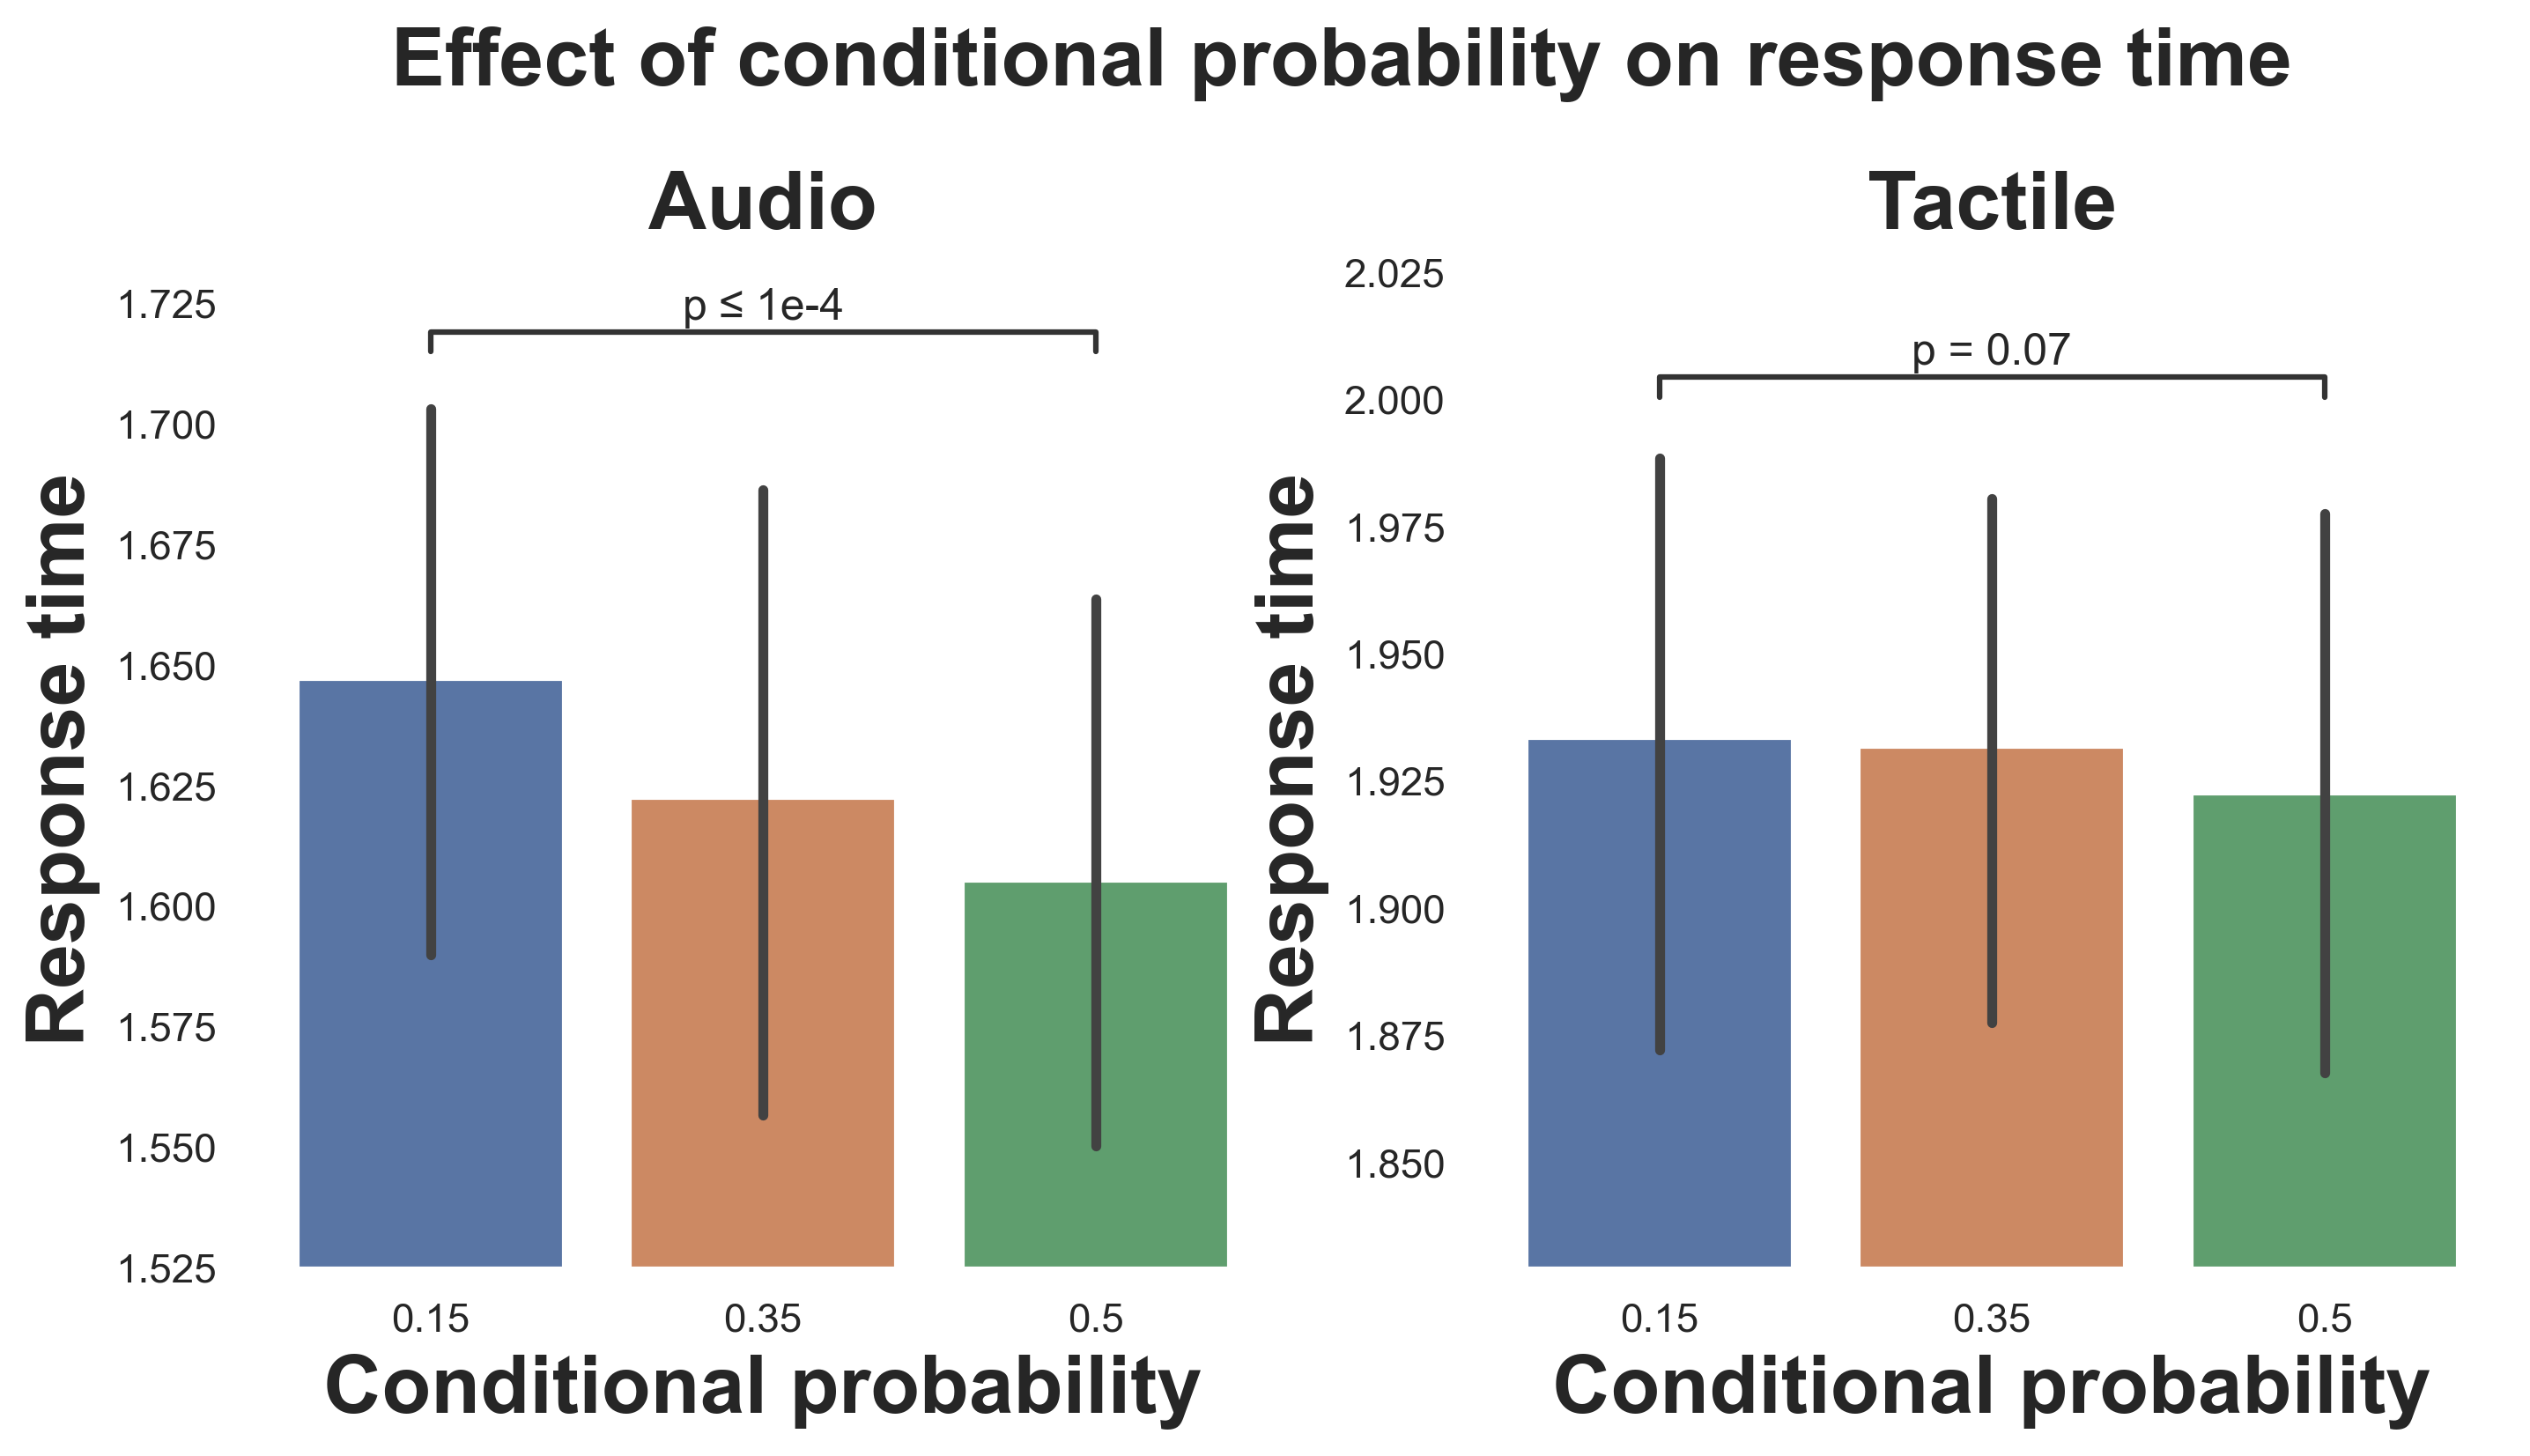

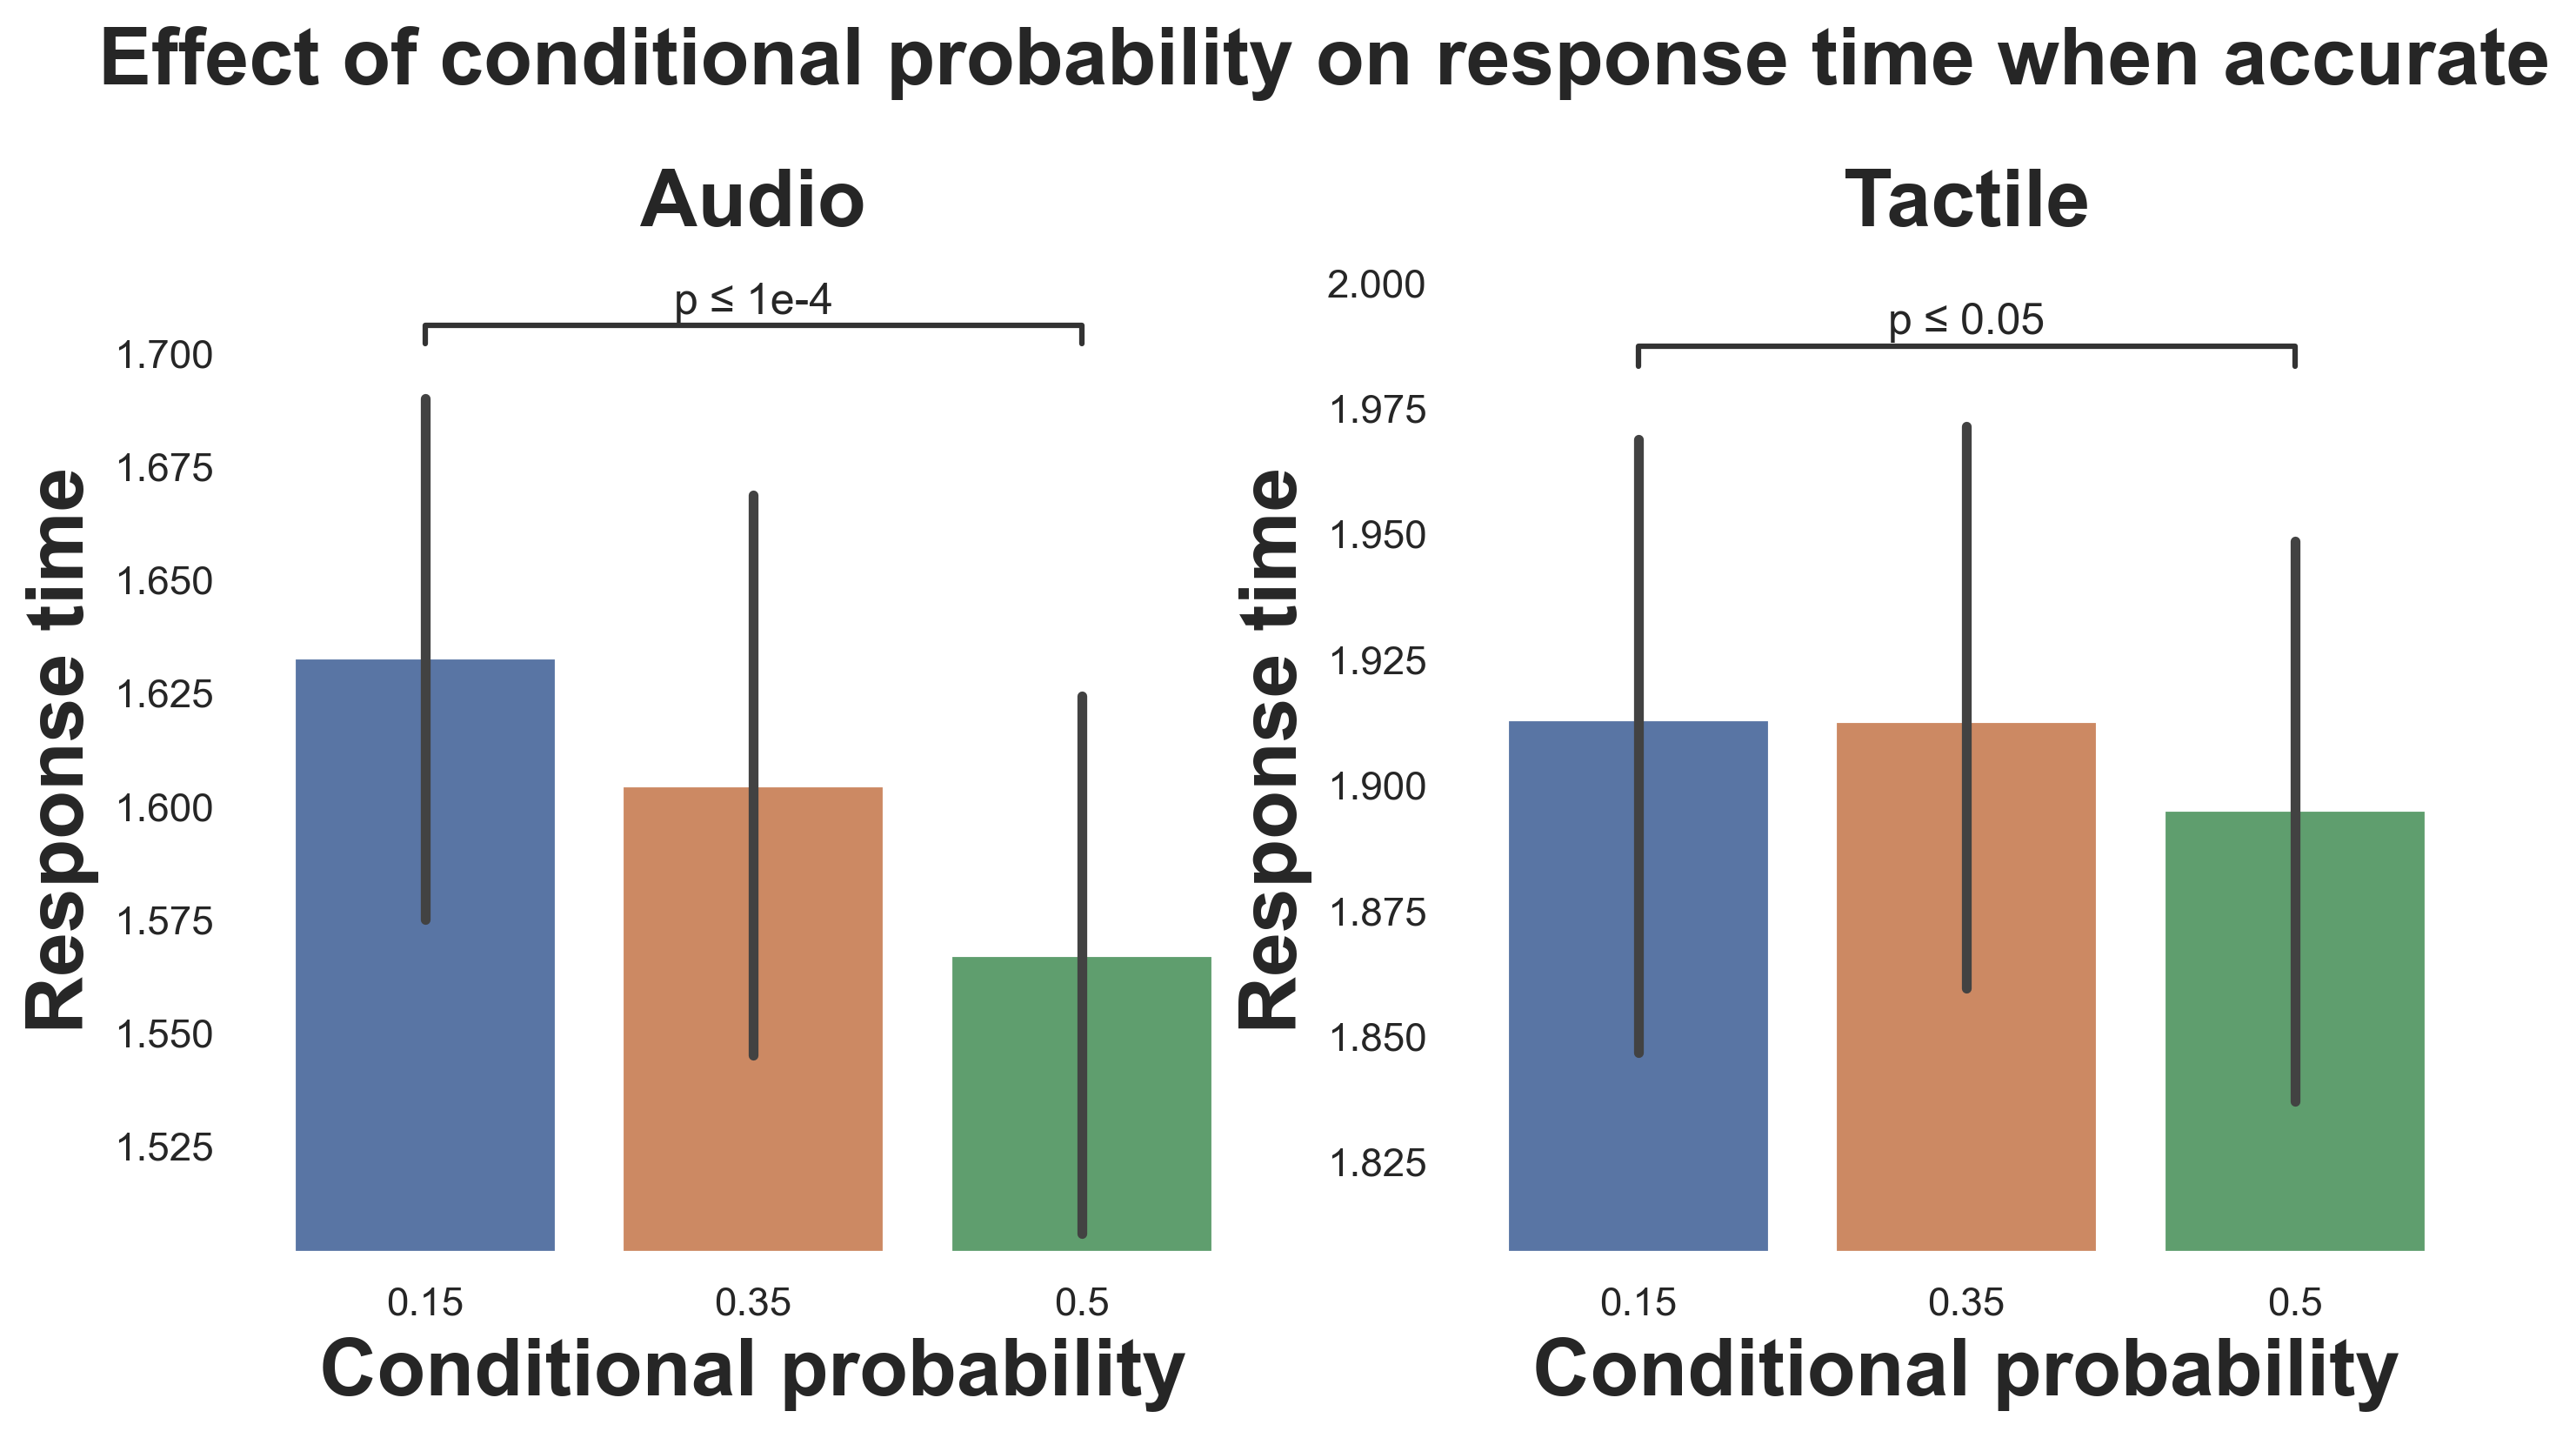

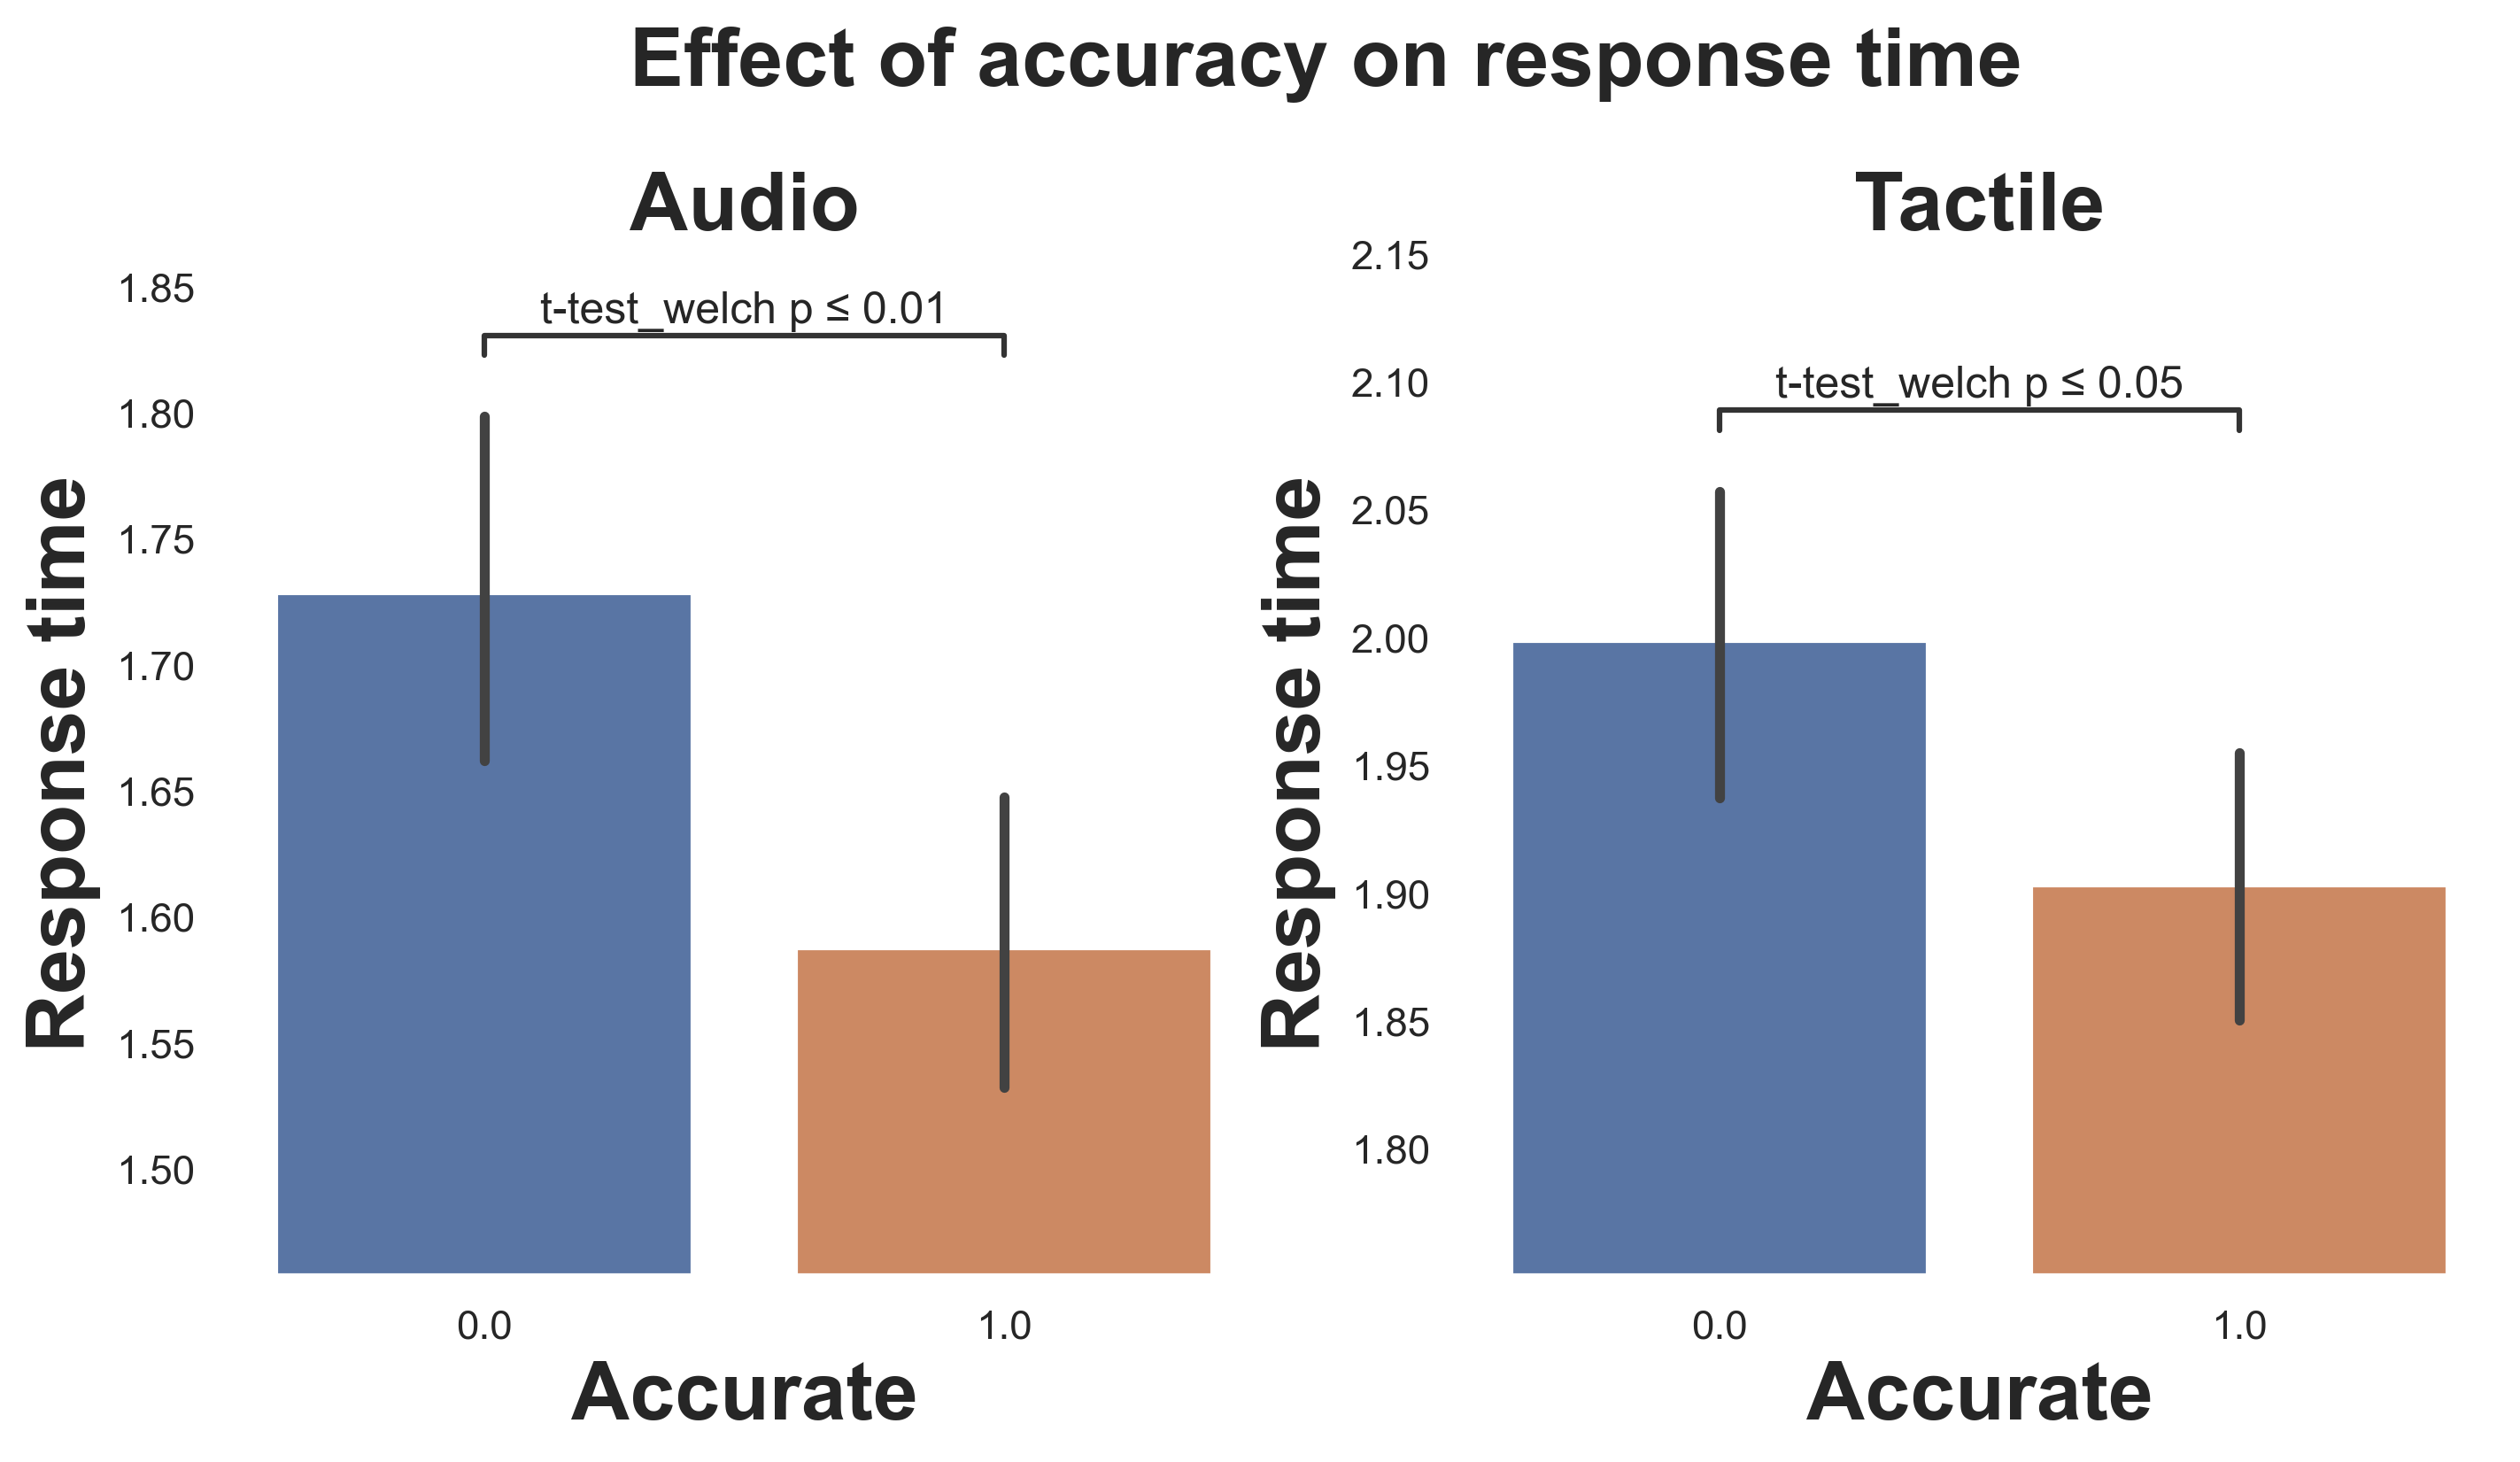

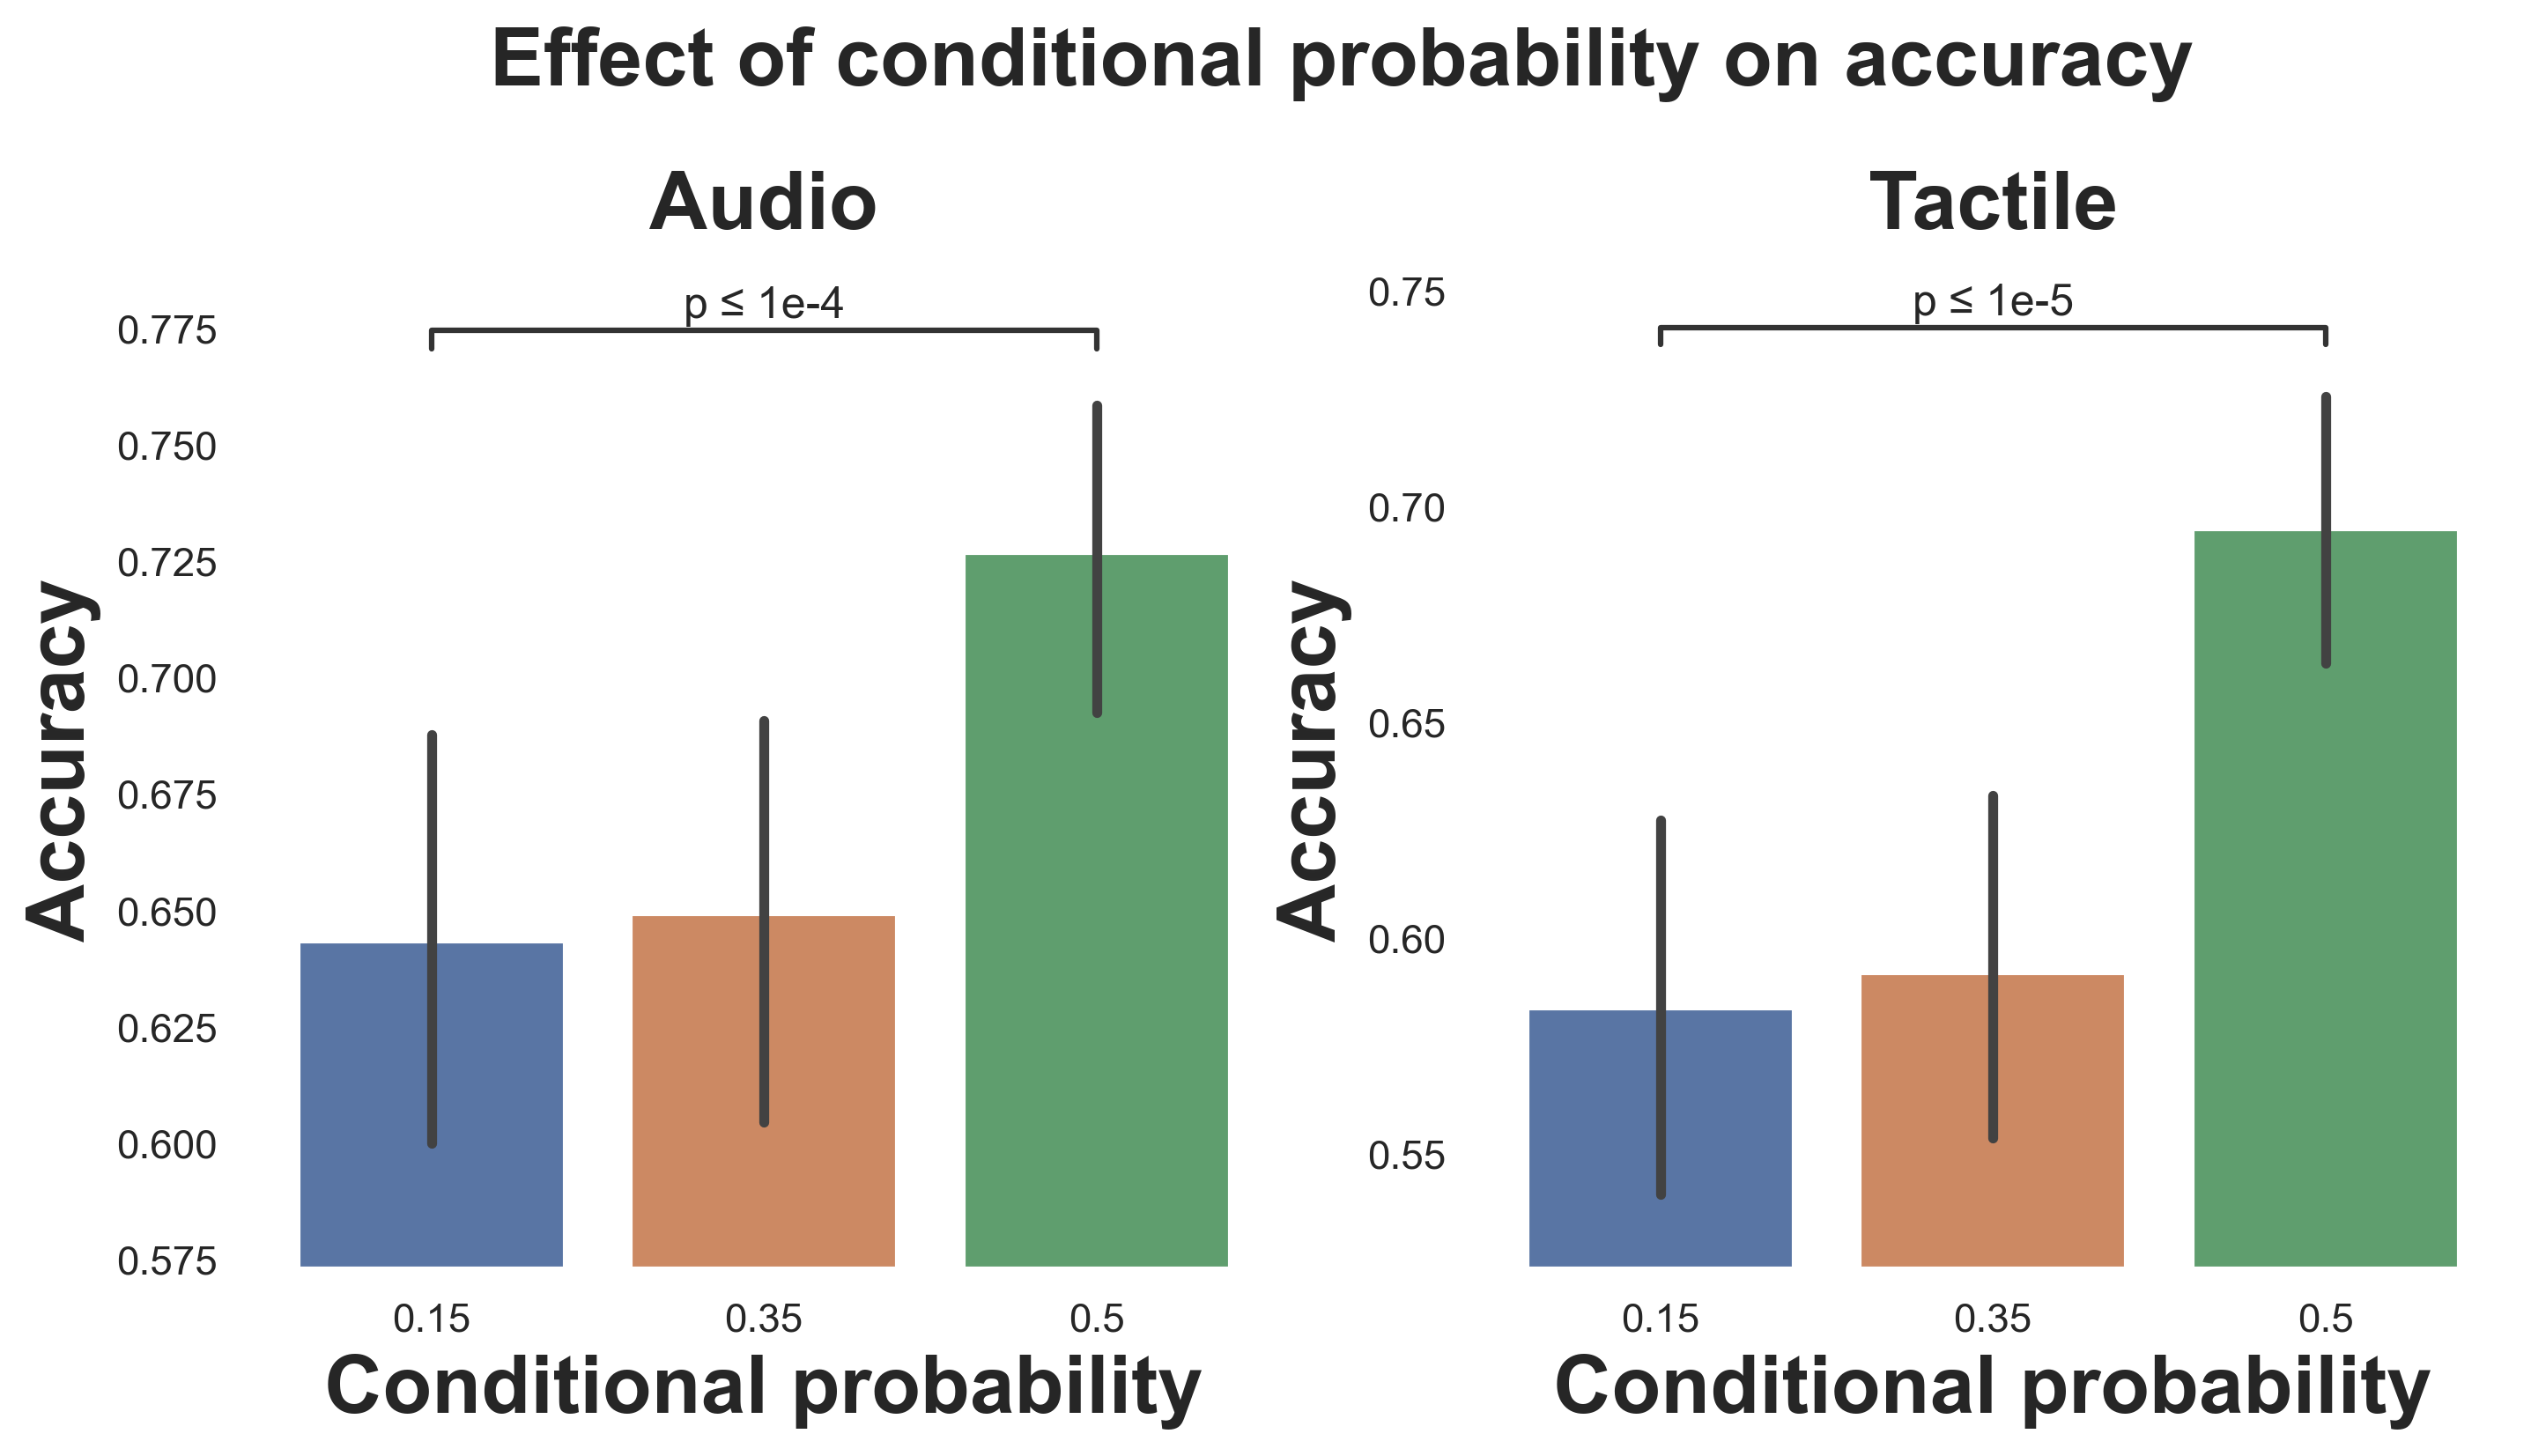

In [65]:
effectsOnRT(exclude=False)

ValueError: Could not interpret input 'accurate'

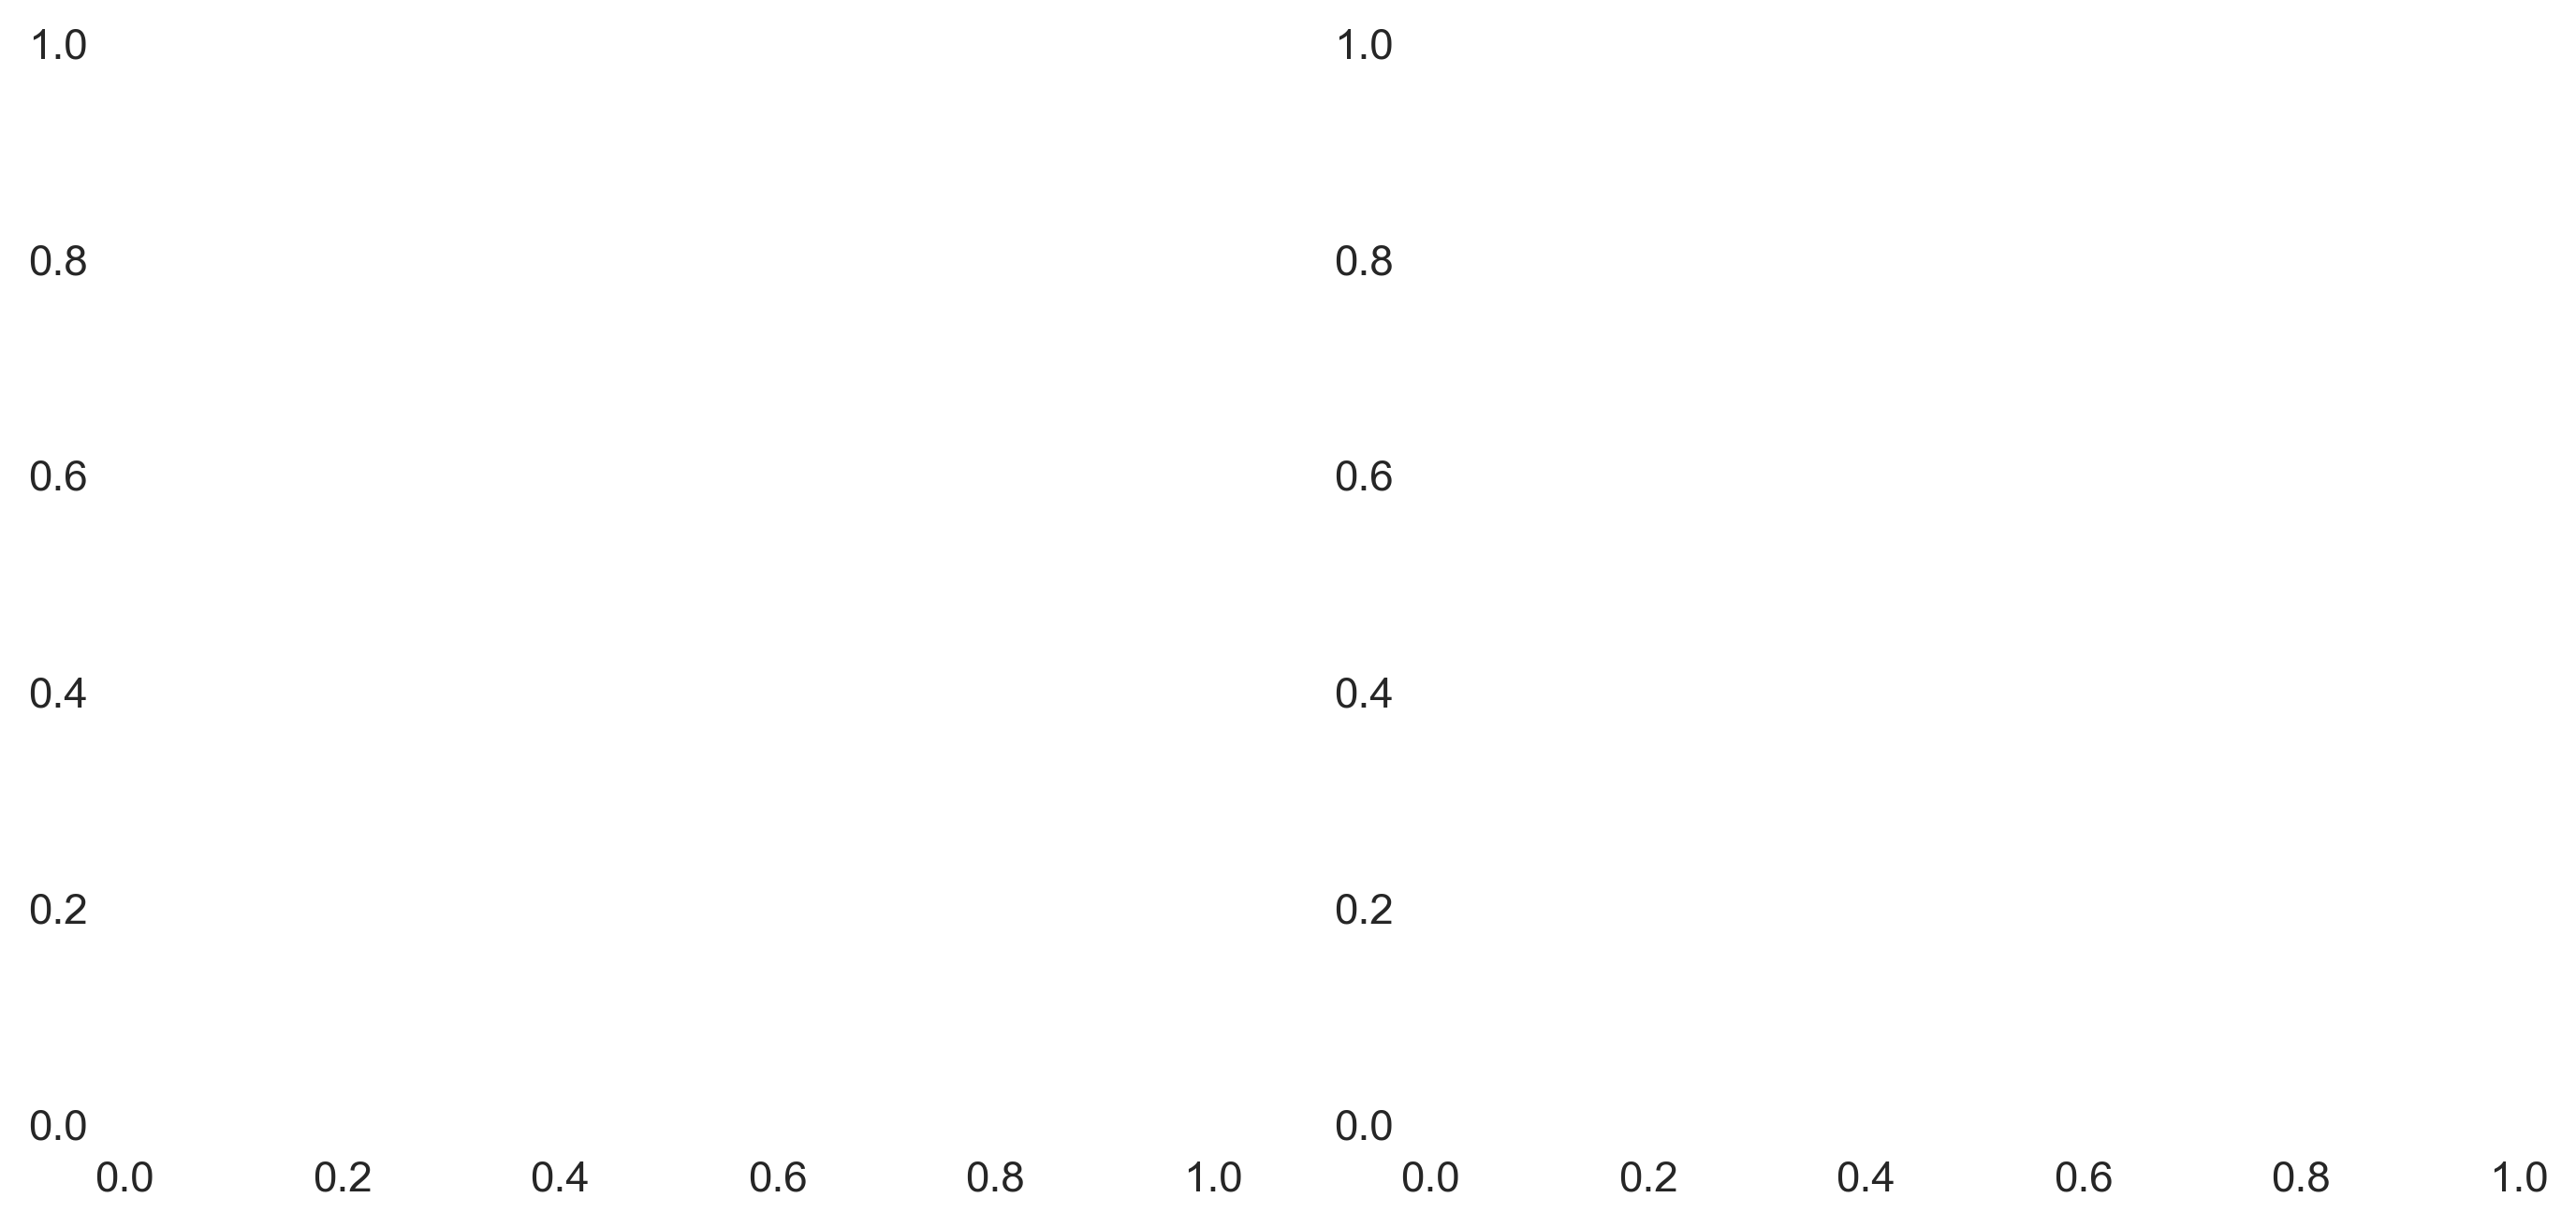

In [53]:
effectsOnRT(exclude=False, mode="barSplit")

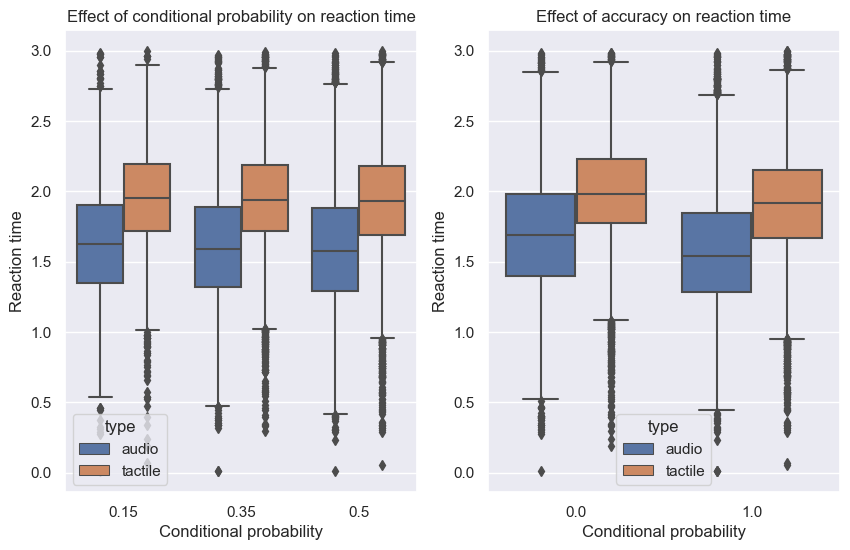

In [27]:
effectsOnRT(exclude=False, mode="box")

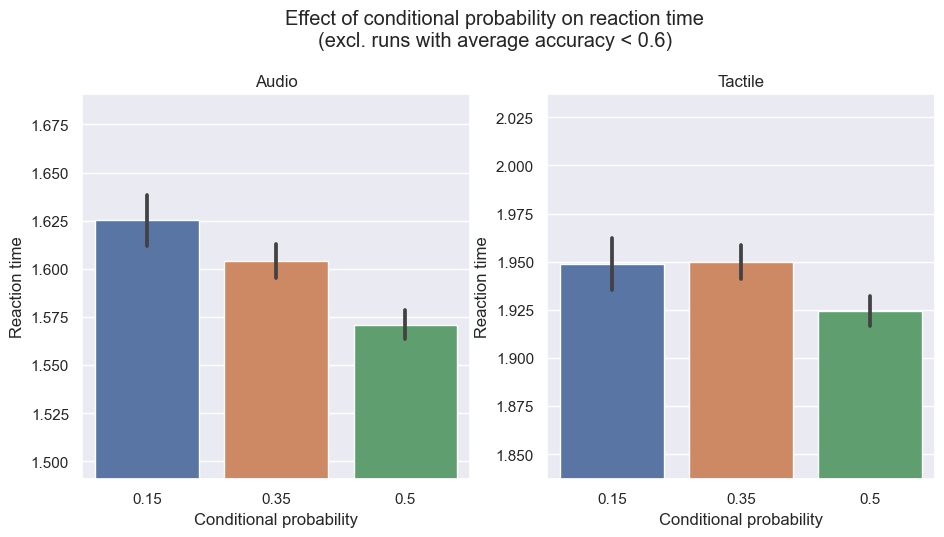

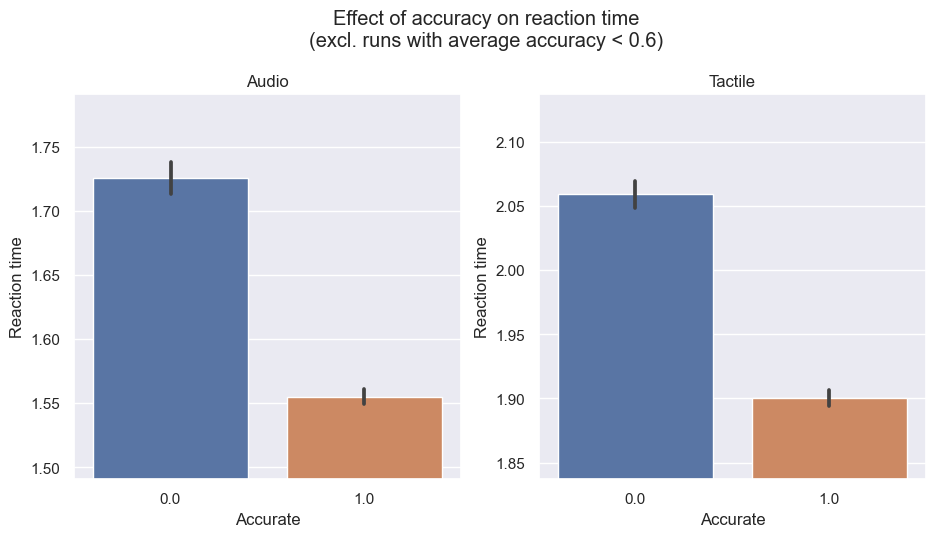

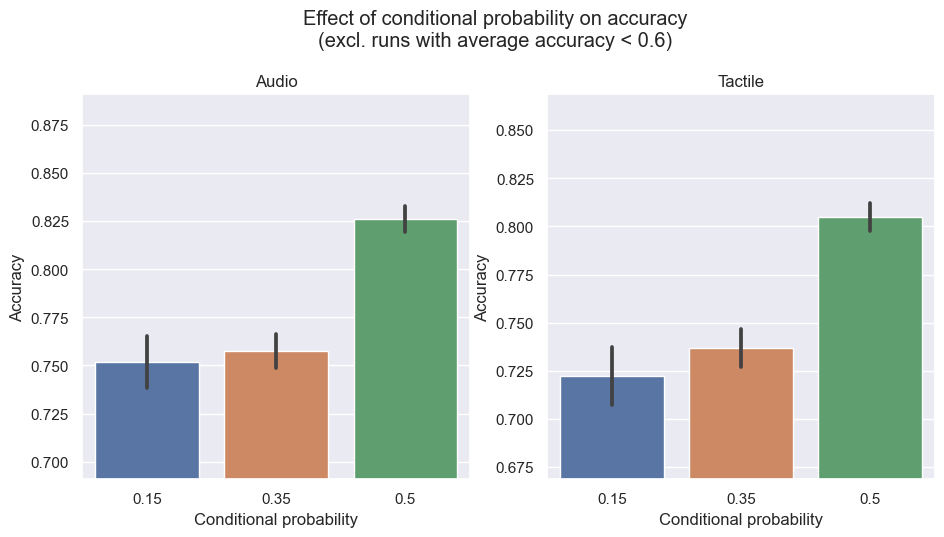

In [28]:
effectsOnRT(exclude=True)

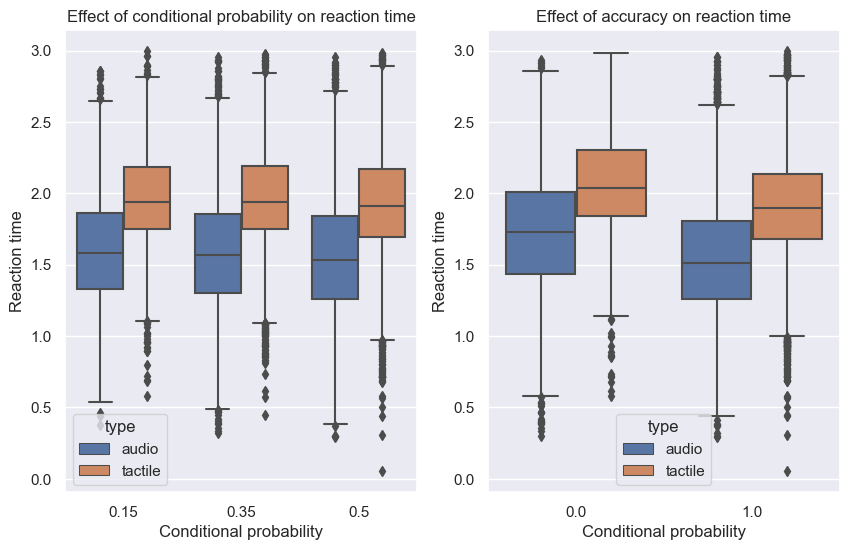

In [29]:
effectsOnRT(exclude=True, mode="box")

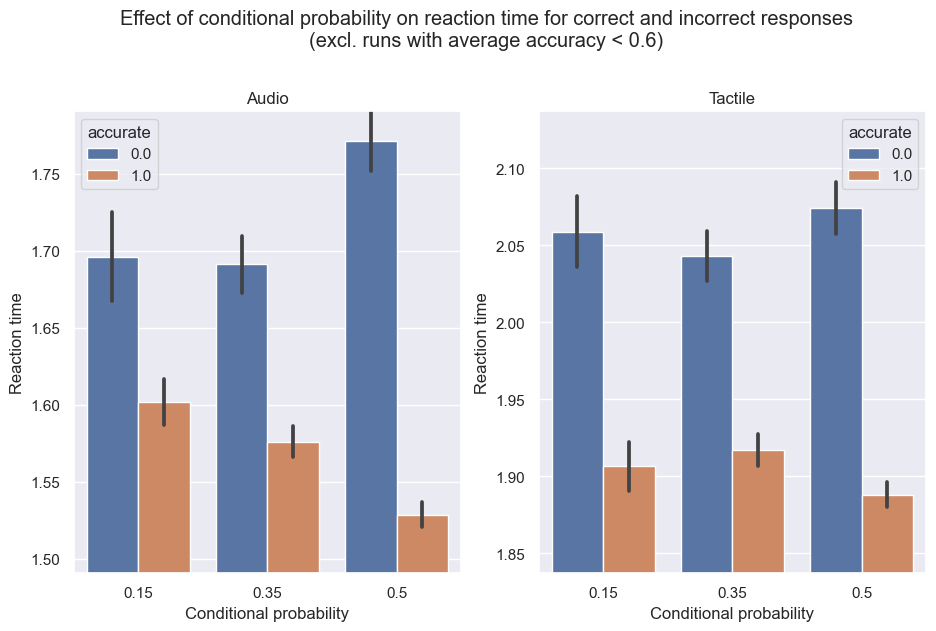

In [30]:
effectsOnRT(exclude=True, mode="barSplit")

In [136]:
def effectsOnAcc():

    if platform.system() == 'Windows':
        wanted_dir = 'T:/projects/2022/bedi_casimiro_ruff_multisensorylearningfmri/data/sourcedata/behavior/modified_files'
    else:
        wanted_dir = '/Volumes/g_econ_department$/projects/2022/bedi_casimiro_ruff_multisensorylearningfmri/data/sourcedata/behavior/modified_files'
    # Get all expInfo and savedVals files
    files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv')]

    # Loop through files and store RT vals, audio, tactile with probability per run and trial type
    dataList = list()

    for file in files:
        data = pd.read_csv(file)
        if max(data.runNumber) == 6:
            if ~np.isnan(data.audio[59]):
                audios = data[(data.runNumber == 3) | (data.runNumber == 5)][['responseTime', 'audio', 'tactile', 'combinationConditionalProbability', 'totalAccuracy', 'feedbackAccuracy']].reset_index()
                tactiles = data[(data.runNumber == 4) | (data.runNumber == 6)][['responseTime', 'audio', 'tactile', 'combinationConditionalProbability', 'totalAccuracy', 'feedbackAccuracy']].reset_index()
            else:
                tactiles = data[(data.runNumber == 3) | (data.runNumber == 5)][['responseTime', 'audio', 'tactile', 'combinationConditionalProbability', 'totalAccuracy', 'feedbackAccuracy']].reset_index()
                audios = data[(data.runNumber == 4) | (data.runNumber == 6)][['responseTime', 'audio', 'tactile', 'combinationConditionalProbability', 'totalAccuracy', 'feedbackAccuracy']].reset_index()


            audioDiff = sum(audios.feedbackAccuracy[:10])/10
            tactileDiff = sum(tactiles.feedbackAccuracy[:10])/10

            avgAudio1_RT = np.mean(audios.responseTime[:60])
            avgAudio2_RT = np.mean(audios.responseTime[60:])

            avgTac1_RT = np.mean(tactiles.responseTime[:60])
            avgTac2_RT = np.mean(tactiles.responseTime[60:])

            avgAccuracyAudio1 = audios.totalAccuracy[59]
            avgAccuracyAudio2 = audios.totalAccuracy[119]

            avgAccuracyTactile1 = tactiles.totalAccuracy[59]
            avgAccuracyTactile2 = tactiles.totalAccuracy[119]

            dataList.append([avgAudio1_RT, avgAccuracyAudio1, audioDiff, "audio"])
            dataList.append([avgAudio2_RT, avgAccuracyAudio2, audioDiff, "audio"])
            dataList.append([avgTac1_RT, avgAccuracyTactile1, tactileDiff, "tactile"])
            dataList.append([avgTac2_RT, avgAccuracyTactile2, tactileDiff, "tactile"])

        else:
            continue

    dataDf = pd.DataFrame(dataList, columns=["RT", "Acc", "difficulty", "type"])

    fig, ax = plt.subplots(figsize=(11,5))     
    b1 = sns.boxplot(dataDf, x="difficulty", y="Acc", hue="type")
    b1.set_xlabel("Difficulty")
    b1.set_ylabel("Accuracy")
    fig.suptitle("Effect of difficulty on average accuracy")

    pairs = [[(0.7, "audio"),(0.8, "audio")],  
         [(0.7, "audio"),(0.9, "audio")],
         [(0.8, "audio"),(0.9, "audio")],
         [(0.7, "tactile"),(0.8, "tactile")],  
         [(0.7, "tactile"),(0.9, "tactile")],
         [(0.8, "tactile"),(0.9, "tactile")]]
        
    annotator = Annotator(ax, pairs, data=dataDf, x="difficulty", y="Acc", hue="type")
    annotator.configure(test='t-test_welch', verbose=True).apply_and_annotate()
    
    
    fig2, ax = plt.subplots(figsize=(11,5))
    b2 = sns.boxplot(dataDf, x="difficulty", y="RT", hue="type")
    b2.set_xlabel("Difficulty")
    b2.set_ylabel("Response time")
    fig2.suptitle("Effect of difficulty on average response time")
    annotator = Annotator(ax, pairs, data=dataDf, x="difficulty", y="RT", hue="type")
    annotator.configure(test='t-test_welch', verbose=True).apply_and_annotate()

    


            

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.7_audio vs. 0.8_audio: Welch's t-test independent samples, P_val:7.902e-04 t=3.671e+00
0.8_audio vs. 0.9_audio: Welch's t-test independent samples, P_val:4.870e-01 t=-7.012e-01
0.7_tactile vs. 0.8_tactile: Welch's t-test independent samples, P_val:1.324e-01 t=1.536e+00
0.8_tactile vs. 0.9_tactile: Welch's t-test independent samples, P_val:2.307e-02 t=2.351e+00
0.7_audio vs. 0.9_audio: Welch's t-test independent samples, P_val:3.056e-04 t=3.757e+00
0.7_tactile vs. 0.9_tactile: Welch's t-test independent samples, P_val:2.407e-04 t=4.148e+00
p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.7_audio vs. 0.8_audio: Welch's t-test independent samples, P_val:3.431e-01 t=-9.631e-01
0

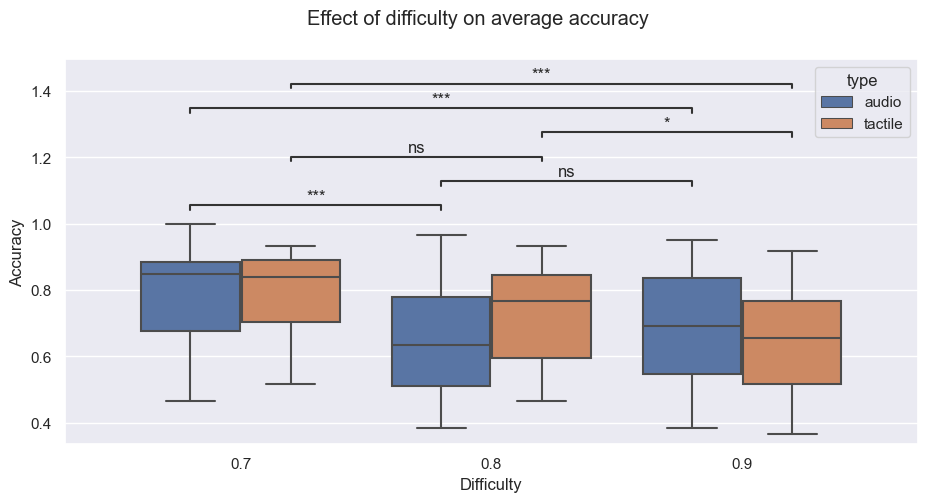

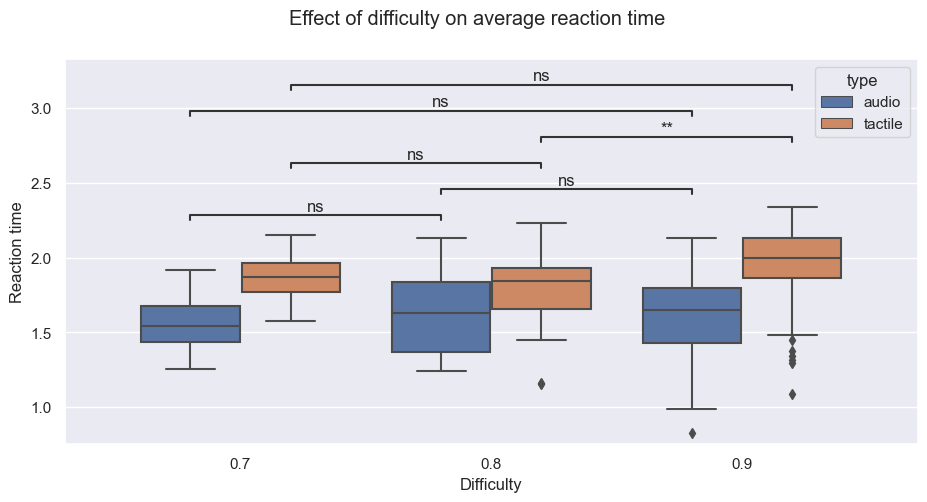

In [137]:
effectsOnAcc()

In [31]:
def reward(feedback=0, exclude=False):
    #feedback 0 (flipped) or 1 (correct)

    if platform.system() == 'Windows':
        wanted_dir = 'T:/projects/2022/bedi_casimiro_ruff_multisensorylearningfmri/data/sourcedata/behavior/modified_files'
    else:
        wanted_dir = '/Volumes/g_econ_department$/projects/2022/bedi_casimiro_ruff_multisensorylearningfmri/data/sourcedata/behavior/modified_files'
    # Get all expInfo and savedVals files
    files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv')]
    nextTrial = list()
    nextPair = list()
    nextStim = list()
    nextVisualStim = list()
    nextOtherStim = list()
    for file in files:
        data = pd.read_csv(file)
        
        if max(data.runNumber) == 6:
            if exclude:
                data = data.loc[120:,:].reset_index(drop=True)
                data["difficulty"] = 0
                data.loc[:60,"difficulty"] = sum(data.feedbackAccuracy[:10])/10
                data.loc[60:120,"difficulty"] = sum(data.feedbackAccuracy[60:70])/10
                data.loc[120:180,"difficulty"] = sum(data.feedbackAccuracy[120:130])/10
                data.loc[180:240,"difficulty"] = sum(data.feedbackAccuracy[180:190])/10
            
            else:
                data["difficulty"] = 0
                data.loc[:60,"difficulty"] = sum(data.feedbackAccuracy[:10])/10
                data.loc[60:120,"difficulty"] = sum(data.feedbackAccuracy[60:70])/10
                data.loc[120:180,"difficulty"] = sum(data.feedbackAccuracy[120:130])/10
                data.loc[180:240,"difficulty"] = sum(data.feedbackAccuracy[180:190])/10
                data.loc[240:300,"difficulty"] = sum(data.feedbackAccuracy[240:250])/10
                data.loc[300:,"difficulty"] = sum(data.feedbackAccuracy[300:310])/10
                data["type"] = np.where(~np.isnan(data['audio']), 'audio', 'tactile')
            
                RewardIdx = np.where(data.feedbackAccuracy == feedback)[0]
                RewardIdx = RewardIdx[(RewardIdx+1)%60 != 0]
                Reward = data.copy().iloc[RewardIdx]
                RewardNextIdx = RewardIdx + 1
                RewardNext = data.copy().iloc[RewardNextIdx]
                RewardNext.loc[:,"prevReward"] = Reward.loc[:,"reward"].values
                RewardNext.loc[:,"prevProb"] = Reward.loc[:,"combinationConditionalProbability"].values
                RewardNext.loc[:,"prevAcc"] = Reward.loc[:,"accurate"].values
                nextTrial.append(RewardNext[["accurate", "responseTime", "combinationConditionalProbability", "type", "difficulty", "prevReward", "prevProb", "prevAcc"]])
                
                RewardPairs = Reward.stimulusPair
                
                for pair, idx in zip(RewardPairs, RewardIdx):
                    RewardRow = data.copy().iloc[idx]
                    temp = data.copy().iloc[idx+1:]
                    RewardNextPairTemp = temp[temp.stimulusPair == pair]
                    if not RewardNextPairTemp.empty:
                        RewardNextPair = RewardNextPairTemp.iloc[0]
                        prevReward = RewardRow["reward"]
                        prevProb = RewardRow["combinationConditionalProbability"]
                        prevAcc = RewardRow["accurate"]
                        if not RewardNextPair.empty:
                            nextPair.append(RewardNextPair[["accurate", "responseTime", "combinationConditionalProbability", "type", "difficulty"]].tolist() + [prevReward, prevProb, prevAcc])
                    
                    RewardNextVisTemp = temp[temp.stimulusPair.str[1] == pair[1]]
                    if not RewardNextVisTemp.empty:
                        RewardNextVis = RewardNextVisTemp.iloc[0]
                        prevReward = RewardRow["reward"]
                        prevProb = RewardRow["combinationConditionalProbability"]
                        prevAcc = RewardRow["accurate"]
                        if not RewardNextVis.empty:
                            nextVisualStim.append(RewardNextVis[["accurate", "responseTime", "combinationConditionalProbability", "type", "difficulty"]].tolist() + [prevReward, prevProb, prevAcc])
                    
                    RewardNextOtherTemp = temp[temp.stimulusPair.str[-2] == pair[-2]]
                    if not RewardNextOtherTemp.empty:
                        RewardNextOther = RewardNextOtherTemp.iloc[0]
                        prevReward = RewardRow["reward"]
                        prevProb = RewardRow["combinationConditionalProbability"]
                        prevAcc = RewardRow["accurate"]
                        if not RewardNextOther.empty:
                            nextOtherStim.append(RewardNextOther[["accurate", "responseTime", "combinationConditionalProbability", "type", "difficulty"]].tolist() + [prevReward, prevProb, prevAcc])
                    
                    if not RewardNextOtherTemp.empty and not RewardNextVisTemp.empty:
                        RewardNextStimTrial = min(RewardNextVis.trialNumber, RewardNextOther.trialNumber)
                        RewardNextStim = temp[temp.trialNumber == RewardNextStimTrial].iloc[0]
                        prevReward = RewardRow["reward"]
                        prevProb = RewardRow["combinationConditionalProbability"]
                        prevAcc = RewardRow["accurate"]
                        stimulus = "visual" if RewardNextVis.trialNumber < RewardNextOther.trialNumber else "other"
                    elif not RewardNextOtherTemp.empty and RewardNextVisTemp.empty:
                        RewardNextStim = RewardNextOtherTemp.iloc[0]
                        prevReward = RewardRow["reward"]
                        prevProb = RewardRow["combinationConditionalProbability"]
                        prevAcc = RewardRow["accurate"]
                        stimulus = "other"
                    elif RewardNextOtherTemp.empty and not RewardNextVisTemp.empty:
                        RewardNextStim = RewardNextVisTemp.iloc[0]
                        prevReward = RewardRow["reward"]
                        prevProb = RewardRow["combinationConditionalProbability"]
                        prevAcc = RewardRow["accurate"]
                        stimulus = "visual"
                    if not RewardNextStim.empty:
                        nextStim.append(RewardNextStim[["accurate", "responseTime", "combinationConditionalProbability", "type", "difficulty"]].tolist() + [prevReward, prevProb, prevAcc, stimulus])
                
        else:
            continue
        
    nextTrialDf = pd.concat(nextTrial)
    nextPairDf = pd.DataFrame(nextPair, columns=["accurate", "responseTime", "combinationConditionalProbability", "type", "difficulty", "prevReward", "prevProb", "prevAcc"])
    nextVisualStimDf = pd.DataFrame(nextVisualStim, columns=["accurate", "responseTime", "combinationConditionalProbability", "type", "difficulty", "prevReward", "prevProb", "prevAcc"])
    nextOtherStimDf = pd.DataFrame(nextOtherStim, columns=["accurate", "responseTime", "combinationConditionalProbability", "type", "difficulty", "prevReward", "prevProb", "prevAcc"])
    nextStimDf = pd.DataFrame(nextStim, columns=["accurate", "responseTime", "combinationConditionalProbability", "type", "difficulty", "prevReward", "prevProb", "prevAcc", "stimulus"])
    
    return nextTrialDf, nextPairDf, nextVisualStimDf, nextOtherStimDf, nextStimDf
    

In [32]:
nextTrialOppDf, nextPairOppDf, nextVisualStimOppDf, nextOtherStimOppDf, nextStimOppDf = reward()

In [33]:
nextTrialDf, nextPairDf, nextVisualStimDf, nextOtherStimDf, nextStimDf = reward(feedback=1)

In [198]:
def reward_plots(mode="next", df=nextTrialDf, dfOpp=nextTrialOppDf):
    # Other modes: nextPair (nextPairDf), nextVisual (nextVisualStimDf), nextOther (nextOtherStimDf), nextStim (nextStimDf)
    df["Feedback"] = "True reward"
    dfOpp["Feedback"] = "Swapped reward"
    df_comb = pd.concat([df, dfOpp], ignore_index=True)
    
    fig, ax = plt.subplots(ncols=2, figsize=(10,4))
    b1 = sns.barplot(data=df_comb, x="prevReward", y="accurate", errorbar="se", ax=ax[0])
    b1.set_xlabel("Reward value")
    b2 = sns.barplot(data=df_comb, x="prevReward", y="accurate", hue="Feedback", errorbar="se", ax=ax[1])
    b2.set_xlabel("Reward value")

    pairs = [(0, 1)]

    pairs2 = [[(0, "True reward"), (1, "True reward")],  
         [(0, "Swapped reward"), (1, "Swapped reward")]] 
        
    annotator = Annotator(ax[0], pairs, data=df_comb, x="prevReward", y="accurate", errorbar="se")
    annotator.configure(test='t-test_welch', verbose=True).apply_and_annotate()
    annotator2 = Annotator(ax[1], pairs2, data=df_comb, x="prevReward", y="accurate", hue="Feedback", errorbar="se")
    annotator2.configure(test='t-test_welch', verbose=True).apply_and_annotate()

    condProb = sns.catplot(data=df_comb, row="prevReward", col="Feedback", x="prevProb", y="accurate", errorbar="se", kind="bar", height=4.5)
    condProb.set(ylim=(np.mean(df_comb.accurate)-0.3, np.mean(df_comb.accurate)+0.2))
    condProb.set(xlabel=("Conditional probability"))
    condProb.set_titles("Reward value: {row_name} | Feedback: {col_name}")
       
    if mode == "next":
        b1.set_ylabel("Accuracy next trial")
        b2.set_ylabel("Accuracy next trial")
        fig.suptitle("Influence of feedback on accuracy next trial")
        condProb.set(ylabel=("Accuracy next trial"))
        condProb.figure.suptitle("Influence of feedback and conditional probability on accuracy next trial", y=1.05)
    elif mode == "nextPair":
        b1.set_ylabel("Accuracy next occurrence pair")
        b2.set_ylabel("Accuracy next occurrence pair")
        fig.suptitle("Influence of feedback on accuracy next occurrence stimulus pair")
        condProb.set(ylabel=("Accuracy next occurrence pair"))
        condProb.figure.suptitle("Influence of feedback and conditional probability on accuracy next occurrence stimulus pair", y=1.05)
    elif mode == "nextVisual":
        b1.set_ylabel("Accuracy next occurrence visual")
        b2.set_ylabel("Accuracy next occurrence visual")
        fig.suptitle("Influence of feedback on accuracy next occurrence visual stimulus")
        condProb.set(ylabel=("Accuracy next occurrence visual"))
        condProb.figure.suptitle("Influence of feedback and conditional probability on accuracy next occurrence visual stimulus", y=1.05)
    elif mode == "nextOther":
        b1.set_ylabel("Accuracy next occurrence audio/tactile")
        b2.set_ylabel("Accuracy next occurrence audio/tactile")
        fig.suptitle("Influence of feedback on accuracy occurrence audio/tactile stimulus")
        condProb.set(ylabel=("Accuracy next occurrence audio/tactile"))
        condProb.figure.suptitle("Influence of feedback and conditional probability on accuracy next occurrence audio/tactile", y=1.05)
    else:
        b1.set_ylabel("Accuracy next occurrence visual/audio/tactile")
        b2.set_ylabel("Accuracy next occurrence visual/audio/tactile")
        fig.suptitle("Influence of feedback on accuracy next occurrence either stimuli")
        condProb.set(ylabel=("Accuracy next occurrence visual/audio/tactile"))
        condProb.figure.suptitle("Influence of feedback and conditional probability on accuracy next occurrence visual/audio/tactile", y=1.05)

    
    plt.show()
        

In [ ]:
#sf = df_comb.loc[:,["prevReward", "Feedback"]]
    condProb = sns.FacetGrid(df_comb, row="prevReward", col="Feedback")
    condProb.set(ylim=(np.mean(df_comb.accurate)-0.3, np.mean(df_comb.accurate)+0.2))
    condProb.set(xlabel=("Conditional probability"))
    condProb.set_titles("Reward value: {row_name} | Feedback: {col_name}")
    

    pairs3 = [(0.15, 0.35),
            (0.15, 0.5),
            (0.35, 0.5)] 
    
    annot = Annotator(None, pairs3)

    condProb.map_dataframe(sns.barplot, annot.plot_and_annotate_facets,x="prevProb", y="accurate", errorbar="se",
                    test="t-test_welch", annotation_func="apply_test")

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0 vs. 1.0: Welch's t-test independent samples, P_val:2.198e-28 t=-1.107e+01
p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0_True reward vs. 1.0_True reward: Welch's t-test independent samples, P_val:3.802e-60 t=-1.647e+01
0.0_Swapped reward vs. 1.0_Swapped reward: Welch's t-test independent samples, P_val:2.660e-16 t=8.258e+00


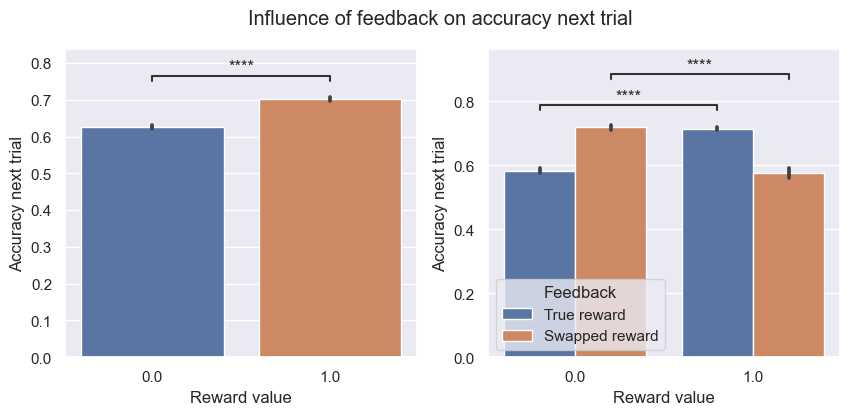

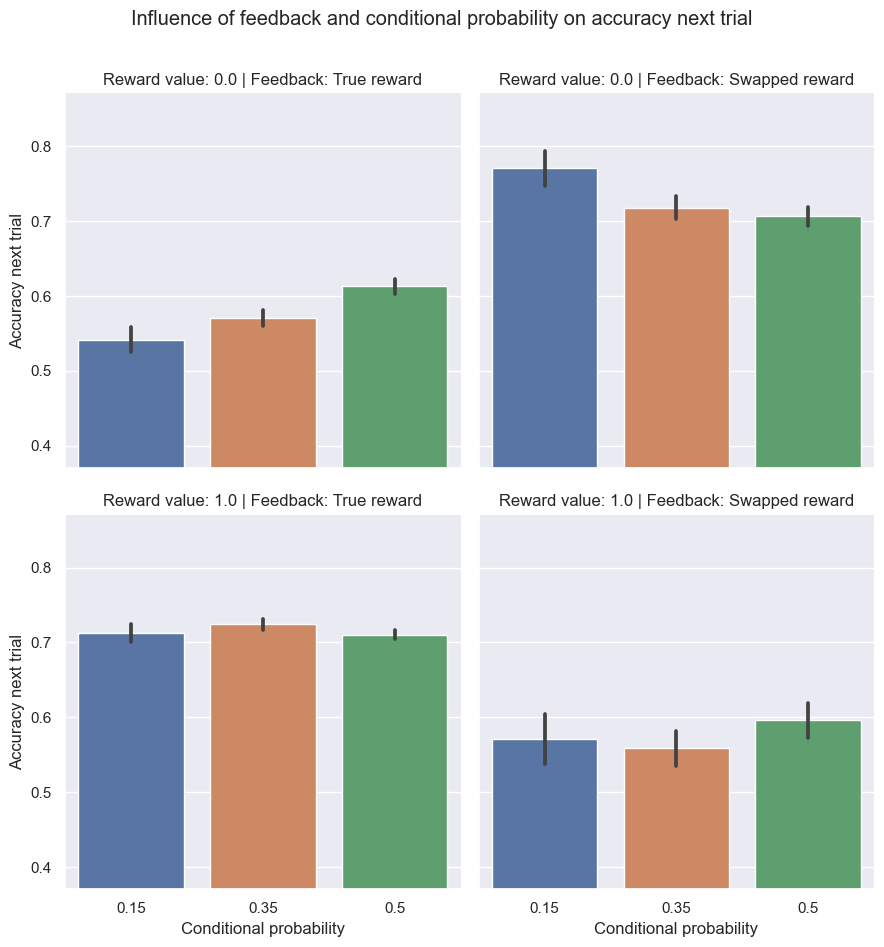

In [199]:
reward_plots()

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0 vs. 1.0: Welch's t-test independent samples, P_val:8.092e-99 t=-2.125e+01
p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0_True reward vs. 1.0_True reward: Welch's t-test independent samples, P_val:2.029e-197 t=-3.071e+01
0.0_Swapped reward vs. 1.0_Swapped reward: Welch's t-test independent samples, P_val:1.107e-53 t=1.592e+01


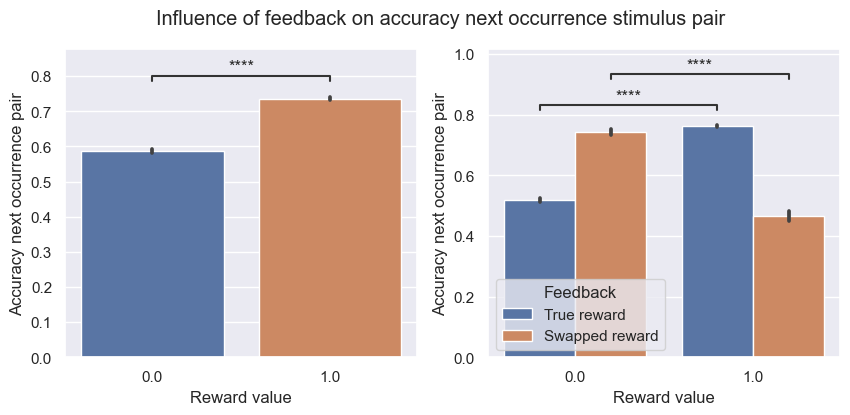

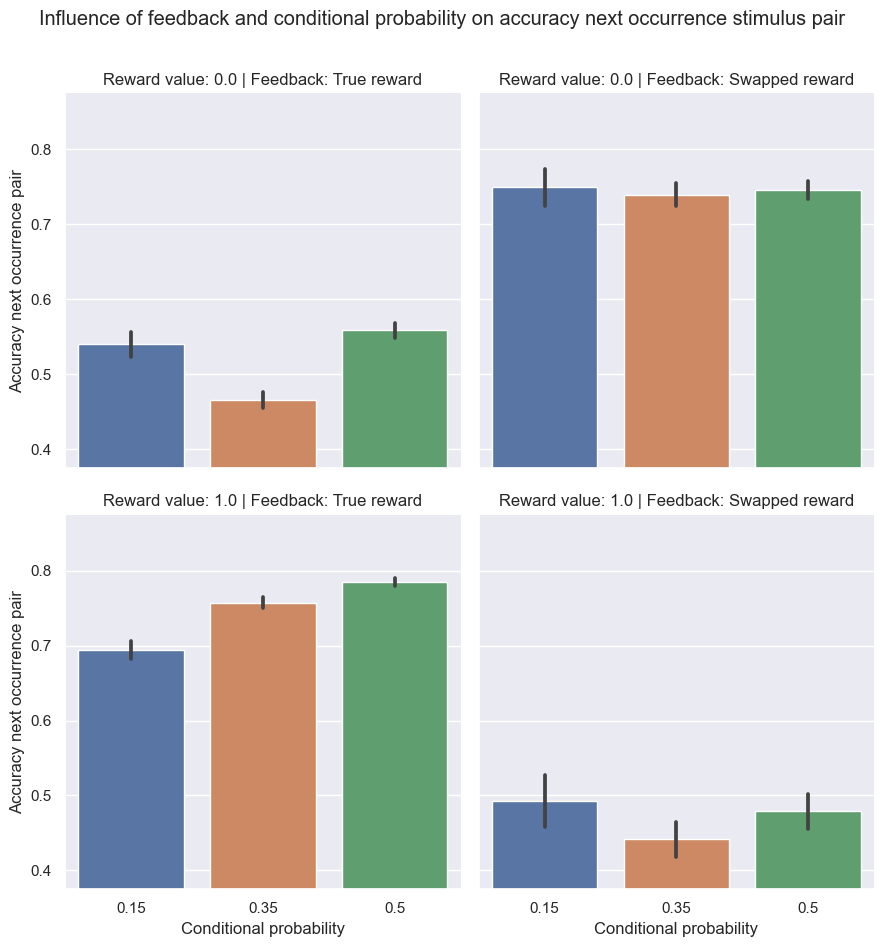

In [200]:
reward_plots(mode="nextPair", df=nextPairDf, dfOpp=nextPairOppDf)

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0 vs. 1.0: Welch's t-test independent samples, P_val:1.848e-66 t=-1.730e+01
p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0_True reward vs. 1.0_True reward: Welch's t-test independent samples, P_val:1.244e-130 t=-2.469e+01
0.0_Swapped reward vs. 1.0_Swapped reward: Welch's t-test independent samples, P_val:2.726e-32 t=1.205e+01


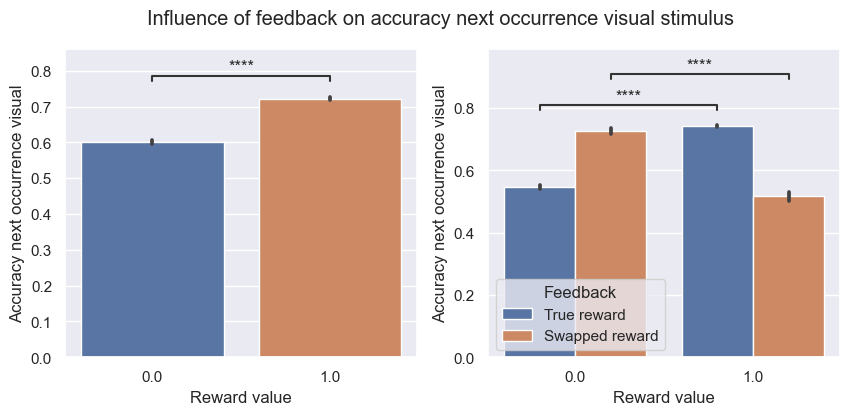

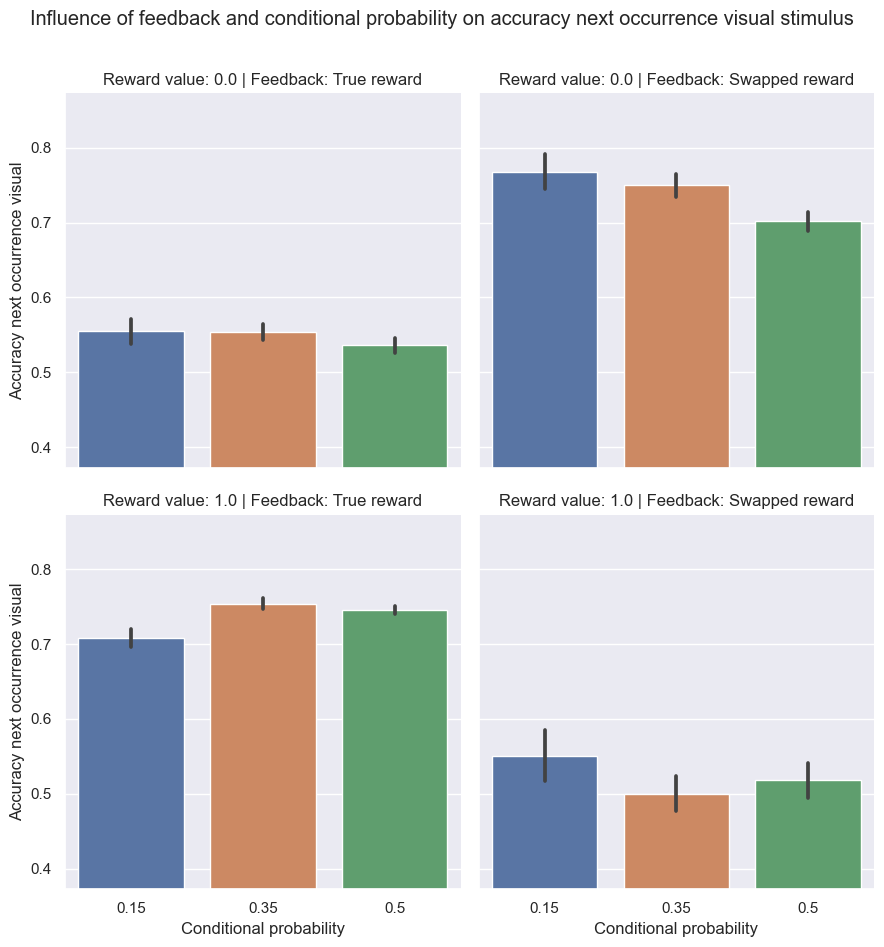

In [201]:
reward_plots(mode="nextVisual", df=nextVisualStimDf, dfOpp=nextVisualStimOppDf)

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0 vs. 1.0: Welch's t-test independent samples, P_val:1.164e-52 t=-1.533e+01
p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0_True reward vs. 1.0_True reward: Welch's t-test independent samples, P_val:2.116e-107 t=-2.229e+01
0.0_Swapped reward vs. 1.0_Swapped reward: Welch's t-test independent samples, P_val:9.379e-32 t=1.193e+01


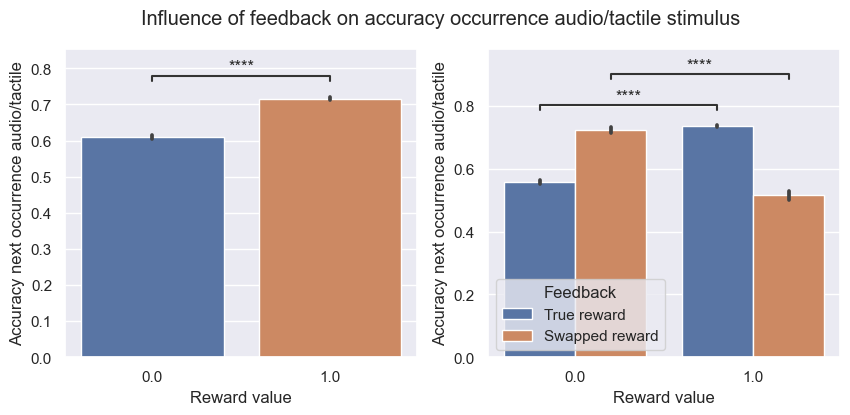

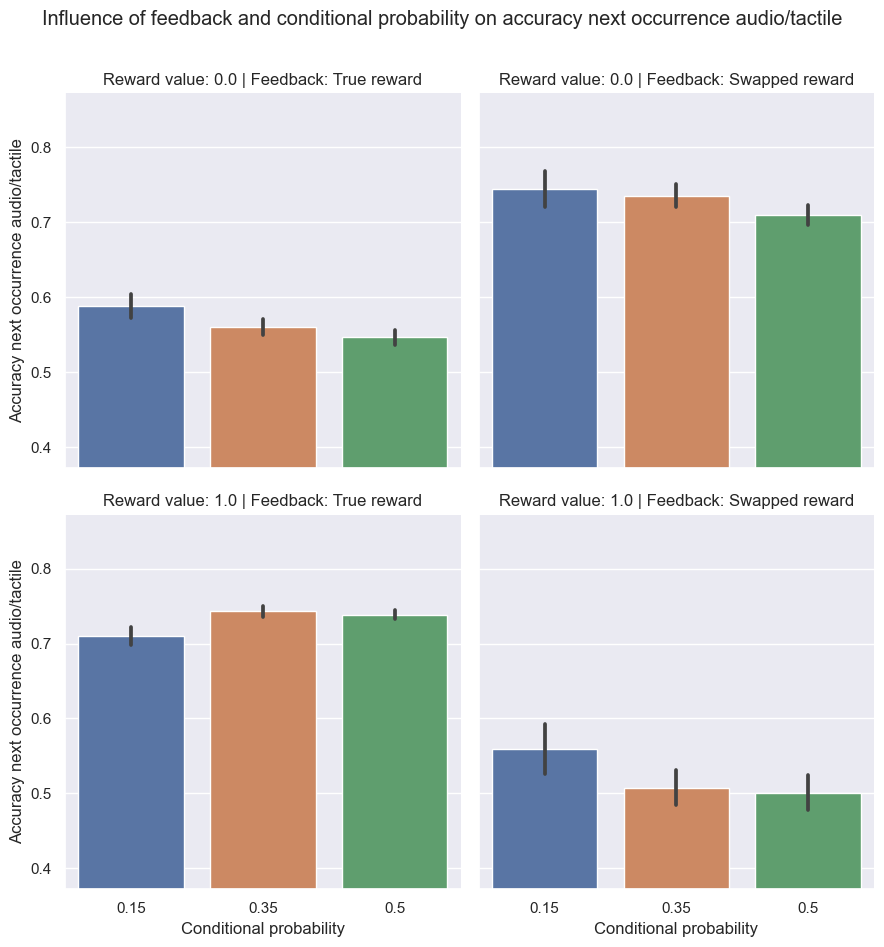

In [202]:
reward_plots(mode="nextOther", df=nextOtherStimDf, dfOpp=nextOtherStimOppDf)

p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0 vs. 1.0: Welch's t-test independent samples, P_val:5.260e-58 t=-1.612e+01
p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0.0_True reward vs. 1.0_True reward: Welch's t-test independent samples, P_val:2.823e-115 t=-2.313e+01
0.0_Swapped reward vs. 1.0_Swapped reward: Welch's t-test independent samples, P_val:5.694e-30 t=1.156e+01


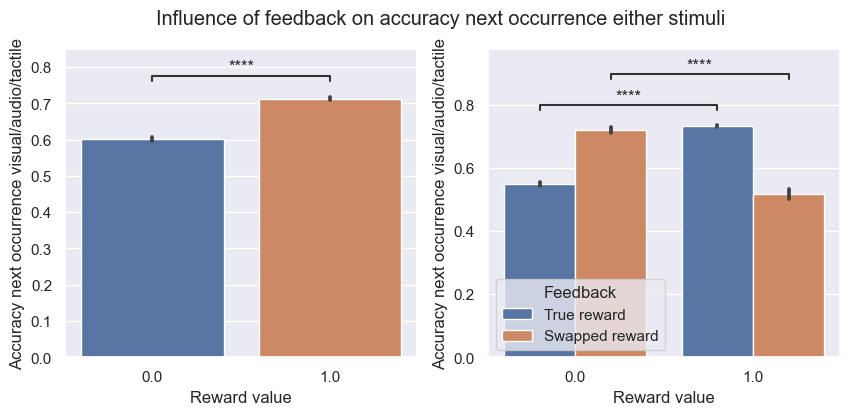

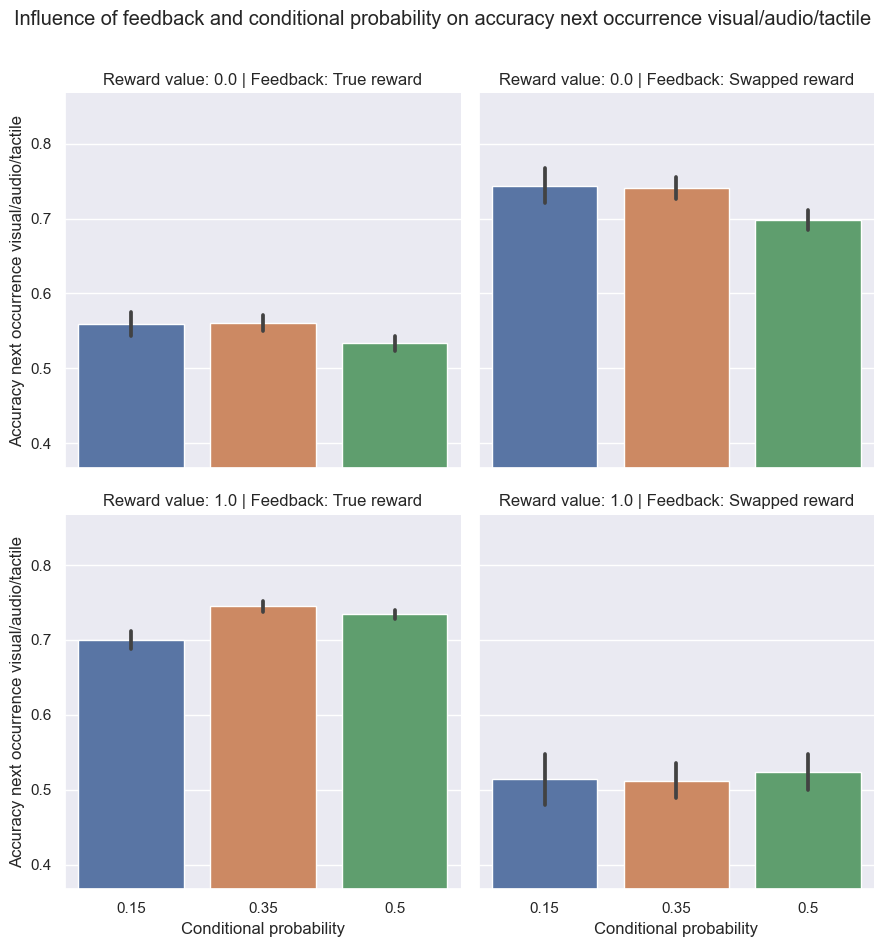

In [203]:
reward_plots(mode="nextStim", df=nextStimDf, dfOpp=nextStimOppDf)

### Below not used

In [46]:
# FOR LATER

def plotGroupAcc(folder='Data/Pilot/beepStimuli/modified_files', ww=10, method='valid'):

    dir_file = pathlib.Path().absolute().parent.parent.resolve()
    wanted_dir = os.path.join(dir_file, folder)

    # Get all expInfo and savedVals files
    files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv')]

    # Loop through files and store accuracy per trial type
    pure_au = list()
    pure_ta = list()

    for file in files:
        data = pd.read_csv(file)

        if max(data.runNumber) == 4:
            if ~np.isnan(data.audio[59]):
                data_audio = data[(data.runNumber == 1) | (data.runNumber == 3)].reset_index(drop=True)
                data_tactile = data[(data.runNumber == 2) | (data.runNumber == 4)].reset_index(drop=True)
            else:
                data_audio = data[(data.runNumber == 2) | (data.runNumber == 4)].reset_index(drop=True)
                data_tactile = data[(data.runNumber == 1) | (data.runNumber == 3)].reset_index(drop=True)
        else:
            if ~np.isnan(data.audio[59]):
                data_audio = data[data.runNumber == 1].reset_index(drop=True)
                data_tactile = data[data.runNumber == 2].reset_index(drop=True)
            else:
                data_audio = data[data.runNumber == 2].reset_index(drop=True)
                data_tactile = data[data.runNumber == 1].reset_index(drop=True)

        pure_au_ind = pd.DataFrame(ma(data_audio.accurate,ww, method)).fillna(method='ffill')
        pure_ta_ind = pd.DataFrame(ma(data_tactile.accurate,ww, method)).fillna(method='ffill')

        pure_au.append(pure_au_ind)
        pure_ta.append(pure_ta_ind)

    df_pure_au = pd.concat(pure_au, axis=1)
    df_pure_ta = pd.concat(pure_ta, axis=1)

    df_pure_au_avg = np.mean(df_pure_au, axis=1)
    df_pure_ta_avg = np.mean(df_pure_ta, axis=1)


    fig, ax = plt.subplots(2, 1,sharey='col', figsize=(14,8))
    plt.suptitle("Average learning curves")
    ax[0].plot(df_pure_au_avg)
    ax[0].set_title("Audio-Visual accuracy (moving avg: {})".format(ww))
    ax[0].set_ylabel('accuracy')
    ax[0].set_ylim(0, 1.1)

    ax[1].plot(df_pure_ta_avg)
    ax[1].set_title("Visual-Tactile accuracy (moving avg: {})".format(ww))
    ax[1].set_ylabel('accuracy')
    ax[1].set_ylim(0, 1.1)

    plt.show()

In [47]:
plotGroupAcc(ww=10,method='valid')

ValueError: No objects to concatenate

In [48]:
# For individual mean RTs

def plotRT(data, info):

    #data_block1 = data[data.runNumber == 1]
    #data_block2 = data[data.runNumber == 2]
    data_block1and2 = data[(data.runNumber == 1) | (data.runNumber == 2)]
    data_block3 = data[data.runNumber == 3]
    data_block4 = data[data.runNumber == 4]

    #df_block1 = pd.DataFrame(data_block1)
    #df_block2 = pd.DataFrame(data_block2)
    df_block1and2 = pd.DataFrame(data_block1and2)
    df_block3 = pd.DataFrame(data_block3)
    df_block4 = pd.DataFrame(data_block4)

    participantID = info.participantID[0]
    Freq0A = info.modality0AFrequency[0]
    Freq1A = info.modality1AFrequency[0]
    Freq2A = info.modality2AFrequency[0]
    Freq0B = info.modality0BFrequency[0]
    Freq1B = info.modality1BFrequency[0]
    Freq2B = info.modality2BFrequency[0]
    Freq0C = info.modality0CFrequency[0]
    Freq1C = info.modality1CFrequency[0]
    Freq2C = info.modality2CFrequency[0]


    fig, ax = plt.subplots(1, 2, sharex='col', sharey='row', figsize=(14,4))

    if info.beeps[0] == 1:
        plt.suptitle('ParticipantID: {}, Beeps'.format(participantID))
    else:
        plt.suptitle('ParticipantID: {}, No beeps'.format(participantID))

    # Tactile mixed (block 1 and 2)
    tm_mean_RTs = df_block1and2.groupby(['tactile', 'visual']).responseTime.mean()
    tm_meanRT_0A = tm_mean_RTs[0][0]
    tm_meanRT_1A = tm_mean_RTs[1][0]
    tm_meanRT_2A = tm_mean_RTs[2][0]

    tm_meanRT_0B = tm_mean_RTs[0][1]
    tm_meanRT_1B = tm_mean_RTs[1][1]
    tm_meanRT_2B = tm_mean_RTs[2][1]

    tm_meanRT_0C = tm_mean_RTs[0][2]
    tm_meanRT_1C = tm_mean_RTs[1][2]
    tm_meanRT_2C = tm_mean_RTs[2][2]

    # Audio mixed (block 1 and 2)
    am_mean_RTs = df_block1and2.groupby(['audio', 'visual']).responseTime.mean()
    am_meanRT_0A = am_mean_RTs[0][0]
    am_meanRT_1A = am_mean_RTs[1][0]
    am_meanRT_2A = am_mean_RTs[2][0]

    am_meanRT_0B = am_mean_RTs[0][1]
    am_meanRT_1B = am_mean_RTs[1][1]
    am_meanRT_2B = am_mean_RTs[2][1]

    am_meanRT_0C = am_mean_RTs[0][2]
    am_meanRT_1C = am_mean_RTs[1][2]
    am_meanRT_2C = am_mean_RTs[2][2]

    x = ['0A: {}'.format(str(Freq0A)[1:]), '1A: {}'.format(str(Freq1A)[1:]), '2A: {}'.format(str(Freq2A)[1:]), '0B: {}'.format(str(Freq0B)[1:]), '1B: {}'.format(str(Freq1B)[1:]), '2B: {}'.format(str(Freq2B)[1:]), '0C: {}'.format(str(Freq0C)[1:]), '1C: {}'.format(str(Freq1C)[1:]), '2C: {}'.format(str(Freq2C)[1:])]
    tm_meanRT_list = [tm_meanRT_0A, tm_meanRT_1A, tm_meanRT_2A, tm_meanRT_0B, tm_meanRT_1B, tm_meanRT_2B, tm_meanRT_0C, tm_meanRT_1C, tm_meanRT_2C]

    am_meanRT_list = [am_meanRT_0A, am_meanRT_1A, am_meanRT_2A, am_meanRT_0B, am_meanRT_1B, am_meanRT_2B, am_meanRT_0C, am_meanRT_1C, am_meanRT_2C]

    ax[0].bar(x, am_meanRT_list)
    ax[0].set_title("Audio-Visual block 1 and 2 mean RT per combination")
    ax[0].set_ylabel('mean RT')
    ax[0].set_ylim(0, 3)

    ax[1].bar(x, tm_meanRT_list)
    ax[1].set_title("Tactile-Visual block 1 and 2 mean RT per combination")
    ax[1].set_ylabel('mean RT')
    ax[1].set_ylim(0, 3)



    fig2, ax2 = plt.subplots(1, 2, sharex='col', sharey='row',figsize=(14,4))

    # Tactile unique (block 3 or 4)
    if ~np.isnan(data_block3.tactile[120]):
        tu_mean_RTs = df_block3.groupby(['tactile', 'visual']).responseTime.mean()
    else:
        tu_mean_RTs = df_block4.groupby(['tactile', 'visual']).responseTime.mean()
    tu_meanRT_0A = tu_mean_RTs[0][0]
    tu_meanRT_1A = tu_mean_RTs[1][0]
    tu_meanRT_2A = tu_mean_RTs[2][0]

    tu_meanRT_0B = tu_mean_RTs[0][1]
    tu_meanRT_1B = tu_mean_RTs[1][1]
    tu_meanRT_2B = tu_mean_RTs[2][1]

    tu_meanRT_0C = tu_mean_RTs[0][2]
    tu_meanRT_1C = tu_mean_RTs[1][2]
    tu_meanRT_2C = tu_mean_RTs[2][2]

    # Audio unique (block 3 or 4)
    if np.isnan(data_block3.tactile[120]):
        au_mean_RTs = df_block3.groupby(['audio', 'visual']).responseTime.mean()
    else:
        au_mean_RTs = df_block4.groupby(['audio', 'visual']).responseTime.mean()

    au_meanRT_0A = au_mean_RTs[0][0]
    au_meanRT_1A = au_mean_RTs[1][0]
    au_meanRT_2A = au_mean_RTs[2][0]

    au_meanRT_0B = au_mean_RTs[0][1]
    au_meanRT_1B = au_mean_RTs[1][1]
    au_meanRT_2B = au_mean_RTs[2][1]

    au_meanRT_0C = au_mean_RTs[0][2]
    au_meanRT_1C = au_mean_RTs[1][2]
    au_meanRT_2C = au_mean_RTs[2][2]

    tu_meanRT_list = [tu_meanRT_0A, tu_meanRT_1A, tu_meanRT_2A, tu_meanRT_0B, tu_meanRT_1B, tu_meanRT_2B, tu_meanRT_0C, tu_meanRT_1C, tu_meanRT_2C]

    au_meanRT_list = [au_meanRT_0A, au_meanRT_1A, au_meanRT_2A, au_meanRT_0B, au_meanRT_1B, au_meanRT_2B, au_meanRT_0C, au_meanRT_1C, au_meanRT_2C]

    ax2[0].bar(x, au_meanRT_list)
    ax2[0].set_title("Audio-Visual block 3/4 mean RT per combination")
    ax2[0].set_ylabel('mean RT')
    ax2[0].set_ylim(0, 3)

    ax2[1].bar(x, tu_meanRT_list)
    ax2[1].set_title("Tactile-Visual block 3/4 mean RT per combination")
    ax2[1].set_ylabel('mean RT')
    ax2[1].set_ylim(0, 3)

    fig3, ax3 = plt.subplots(1, 2, sharex='col', sharey='row',figsize=(14,4))

    audio_block1and2 = df_block1and2[~np.isnan(df_block1and2.audio)]
    tactile_block1and2 = df_block1and2[~np.isnan(df_block1and2.tactile)]

    # Tactile mixed (block 1 and 2) mean RT per probability
    tm_mean_RTs_freqs = tactile_block1and2.groupby(['combinationConditionalProbability']).responseTime.mean()

    tm_meanRT_15 = np.array(tm_mean_RTs_freqs)[0]
    tm_meanRT_35 = np.array(tm_mean_RTs_freqs)[1]
    tm_meanRT_50 = np.array(tm_mean_RTs_freqs)[2]

    # Audio mixed (block 1 and 2) mean RT per probability
    am_mean_RTs_freqs = audio_block1and2.groupby(['combinationConditionalProbability']).responseTime.mean()

    am_meanRT_15 = np.array(am_mean_RTs_freqs)[0]
    am_meanRT_35 = np.array(am_mean_RTs_freqs)[1]
    am_meanRT_50 = np.array(am_mean_RTs_freqs)[2]

    x = ['0.15', '0.35', '0.50']
    tm_meanRT_freqs_list = [tm_meanRT_15, tm_meanRT_35, tm_meanRT_50]

    am_meanRT_freqs_list = [am_meanRT_15, am_meanRT_35, am_meanRT_50]

    ax3[0].bar(x, tm_meanRT_freqs_list)
    ax3[0].set_title("Audio-Visual block 1 and 2 mean RT per probability")
    ax3[0].set_ylabel('mean RT')
    ax3[0].set_ylim(0, 3)

    ax3[1].bar(x, am_meanRT_freqs_list)
    ax3[1].set_title("Tactile-Visual block 1 and 2 mean RT per probability")
    ax3[1].set_ylabel('mean RT')
    ax3[1].set_ylim(0, 3)

    fig4, ax4 = plt.subplots(1, 2, sharex='col', sharey='row',figsize=(14,4))

    #Audio unique
    if ~np.isnan(data_block3.tactile[120]):
        tu_mean_RTs_freqs = df_block3.groupby(['combinationConditionalProbability']).responseTime.mean()
    else:
        tu_mean_RTs_freqs = df_block4.groupby(['combinationConditionalProbability']).responseTime.mean()

    #Tactile unique
    if np.isnan(data_block3.tactile[120]):
        au_mean_RTs_freqs = df_block3.groupby(['combinationConditionalProbability']).responseTime.mean()
    else:
        au_mean_RTs_freqs = df_block4.groupby(['combinationConditionalProbability']).responseTime.mean()

    tu_meanRT_15 = np.array(tu_mean_RTs_freqs)[0]
    tu_meanRT_35 = np.array(tu_mean_RTs_freqs)[1]
    tu_meanRT_50 = np.array(tu_mean_RTs_freqs)[2]

    au_meanRT_15 = np.array(au_mean_RTs_freqs)[0]
    au_meanRT_35 = np.array(au_mean_RTs_freqs)[1]
    au_meanRT_50 = np.array(au_mean_RTs_freqs)[2]

    tu_meanRT_freqs_list = [tu_meanRT_15, tu_meanRT_35, tu_meanRT_50]

    au_meanRT_freqs_list = [au_meanRT_15, au_meanRT_35, au_meanRT_50]

    ax4[0].bar(x, tu_meanRT_freqs_list)
    ax4[0].set_title("Audio-Visual block 3/4 mean RT per probability")
    ax4[0].set_ylabel('mean RT')
    ax4[0].set_ylim(0, 3)

    ax4[1].bar(x, au_meanRT_freqs_list)
    ax4[1].set_title("Tactile-Visual block 3/4 mean RT per probability")
    ax4[1].set_ylabel('mean RT')
    ax4[1].set_ylim(0, 3)


    plt.show()